# FINC6028 Assignment 3 — Track A: Hedge-Fund Pitch (Group)

## A Proof-of-Concept Machine-Learning Stock-Selection Pipeline — Paper-Trade Recommendation Only

### Using Lagged Price-Action, Liquidity, and Macro-Regime Conditioning

**Group ##:** *(insert group number)* &nbsp;&nbsp;|&nbsp;&nbsp; **Track:** A — Investment Strategy &nbsp;&nbsp;|&nbsp;&nbsp; **Due:** 7 June 2026

---

### One-sentence hypothesis (drives every downstream choice)

> **We test whether lagged price action, technical, liquidity, and macro-regime
> interaction signals predict next-week cross-sectional outperformance more
> effectively than simple momentum, evaluated under realistic walk-forward
> backtesting and transaction costs.**

### Stakeholder & decision

| Element | Detail |
|---|---|
| **Stakeholder** | **Quantitative equity research team / investment committee** deciding whether this signal pipeline deserves a **monitored paper-trade trial**, not live capital deployment, on a point-in-time investable universe |
| **Decision** | Every Friday close, whether the HGBT ranking signal adds value over a 12-week momentum baseline and an L2-logistic baseline, **net of transaction costs**, on a 50-stock cross-section |
| **Value proposition** | A defensible, leakage-free, cost-aware workflow that turns lagged price-volume data into a tradable cross-sectional score — with explicit drift monitoring, ablation evidence, and an audit trail suitable for an investment committee review |
| **Success criterion** | Evidence is strong enough to justify only a staged paper-trade pilot: net performance must beat internal baselines, robustness must identify a simpler candidate, and live deployment remains blocked until point-in-time universe and forward paper-trade tests pass |

### Honest scoping

This is a **research prototype**, not a fully investable backtest. The
universe is fixed *ex post* (current S&P 500 large-caps), so survivorship
bias inflates historical results. Conclusions are about **signal
behaviour and workflow integrity**, not deployable alpha. A point-in-time
universe (CRSP via PERMNO matching using the supplied `stocknames.csv`)
is the natural next step before paper-trading.

### Why this design

The Week 12 lecture + Week 9–11 tutorials build the full cross-sectional
backtest stack: leakage-safe panels, walk-forward refitting, equal-weight
quantile portfolios, turnover-based costs, and risk controls. A3 extends
A2 in three directions:

1. **Cross-sectional outperformance target** — instead of predicting
   absolute direction (which leaks market beta), we predict whether a
   stock outperforms the same-week universe median, which is the
   problem cross-sectional ranking actually faces.
2. **Formal three-tier model ladder** — momentum baseline → L2-logistic
   → HGBT — under one identical backtest.
3. **A monitoring, governance, ablation, and falsification scaffold**
   designed to satisfy every HD rubric criterion simultaneously.


---

## 0) Rubric Compliance Map

In [1]:
# 0) Compliance table
import pandas as pd

compliance_table = pd.DataFrame({
    'Rubric criterion (max pts)' : [
        'Problem framing & value proposition (10)',
        'Data quality, governance, leakage (15)',
        'Methodology & model design (15)',
        'Validation & evaluation design (15)',
        'Results, robustness, interpretation (15)',
        'Risk management & responsible AI (10)',
        'Evidence log & reproducibility (10)',
        'Professional writing & presentation (5)',
        'Disclosures (contribution & AI-use) (5)',
    ],
    'HD requirement' : [
        'Clear stakeholder+decision, testable hypothesis, compelling value',
        'Strong provenance, cleaning, explicit leakage prevention, missingness rule + rows',
        'Baseline + improved using SAME features/eval; rationale; interpretability',
        'Correct walk-forward; proper metrics; benchmarks; coherent for track',
        'Defensible results; robustness varies design choice; interprets failures',
        'Model/data risks + mitigation; drift monitoring; governance',
        '5+ experiment log + ablation; 5-example error analysis; reproducible',
        'Clean memo style; clean tables/figures; concise',
        'Contribution table sums to 100%; AI declaration complete',
    ],
    'Implemented in section' : [
        'Header + Section 1',
        'Sections 2-7',
        'Sections 8-11',
        'Sections 11-13',
        'Sections 14-18',
        'Section 19',
        'Section 20 (Evidence Log)',
        'All tables df-formatted; no screenshots',
        'Sections 22-23',
    ],
})
print('--- Rubric Compliance Map ---')
display(compliance_table)

--- Rubric Compliance Map ---


,Rubric criterion (max pts),HD requirement,Implemented in section
0,Problem framing & value proposition (10),"Clear stakeholder+decision, testable hypothesi...",Header + Section 1
1,"Data quality, governance, leakage (15)","Strong provenance, cleaning, explicit leakage ...",Sections 2-7
2,Methodology & model design (15),Baseline + improved using SAME features/eval; ...,Sections 8-11
3,Validation & evaluation design (15),Correct walk-forward; proper metrics; benchmar...,Sections 11-13
4,"Results, robustness, interpretation (15)",Defensible results; robustness varies design c...,Sections 14-18
5,Risk management & responsible AI (10),Model/data risks + mitigation; drift monitorin...,Section 19
6,Evidence log & reproducibility (10),5+ experiment log + ablation; 5-example error ...,Section 20 (Evidence Log)
7,Professional writing & presentation (5),Clean memo style; clean tables/figures; concise,All tables df-formatted; no screenshots
8,Disclosures (contribution & AI-use) (5),Contribution table sums to 100%; AI declaratio...,Sections 22-23


---

## 1) Setup, Imports, and Reproducibility

In [2]:
# 1a) Install dependencies (Colab-safe)
!pip -q install yfinance pandas_datareader scikit-learn pyarrow

In [3]:
# 1b) Imports and seeds
import warnings
warnings.filterwarnings('ignore')

import os, sys, random, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import pandas_datareader.data as pdr

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

# Reproducibility
SEED = 6028
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
plt.rcParams['font.size']      = 10

try:
    from IPython.display import display
except ImportError:
    display = print

print(f"Setup OK | numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__} | seed={SEED}")

# Audit-level runtime tracking
notebook_start = time.time()
run_timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f"Notebook run timestamp: {run_timestamp}")


Setup OK | numpy 2.0.2 | pandas 2.2.2 | sklearn 1.6.1 | seed=6028
Notebook run timestamp: 2026-05-22 14:02:21


---

## 2) User Settings

All tunable constants in one place; ablations and robustness checks change
exactly one variable.

In [4]:
# 2) USER SETTINGS
# -----------------------------------------------------------------------------
# Universe: 50 large-cap US stocks across 8 GICS sectors.
# IMPORTANT: This is an EX-POST snapshot, NOT a point-in-time universe.
# Survivorship bias is acknowledged as the central data limitation. Results
# are interpreted as proof-of-concept, not investable alpha.
TICKERS = [
    # Information Technology (10)
    'AAPL', 'MSFT', 'NVDA', 'AVGO', 'ORCL', 'ADBE', 'CRM', 'CSCO', 'INTC', 'TXN',
    # Financials (8)
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'C', 'AXP',
    # Health Care (8)
    'UNH', 'JNJ', 'LLY', 'MRK', 'ABT', 'TMO', 'BMY', 'AMGN',
    # Consumer Discretionary (6)
    'AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'LOW',
    # Consumer Staples (6)
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'CL',
    # Energy (4)
    'XOM', 'CVX', 'COP', 'SLB',
    # Industrials (5)
    'CAT', 'GE', 'BA', 'HON', 'UNP',
    # Communication Services (3)
    'GOOGL', 'META', 'DIS',
]

SECTOR_MAP = {
    **{t: 'Information Technology'    for t in ['AAPL', 'MSFT', 'NVDA', 'AVGO', 'ORCL', 'ADBE', 'CRM', 'CSCO', 'INTC', 'TXN']},
    **{t: 'Financials'                for t in ['JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'C', 'AXP']},
    **{t: 'Health Care'               for t in ['UNH', 'JNJ', 'LLY', 'MRK', 'ABT', 'TMO', 'BMY', 'AMGN']},
    **{t: 'Consumer Discretionary'    for t in ['AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'LOW']},
    **{t: 'Consumer Staples'          for t in ['PG', 'KO', 'PEP', 'WMT', 'COST', 'CL']},
    **{t: 'Energy'                    for t in ['XOM', 'CVX', 'COP', 'SLB']},
    **{t: 'Industrials'               for t in ['CAT', 'GE', 'BA', 'HON', 'UNP']},
    **{t: 'Communication Services'    for t in ['GOOGL', 'META', 'DIS']},
}

BENCHMARK = 'SPY'

# Sample period
START = '2014-01-01'
END   = '2026-03-28'
FREQ  = 'W-FRI'

# FRED series - used ONLY as regime/interaction inputs (per teacher guidance)
FRED_SERIES = {
    'vix'     : 'VIXCLS',
    'dgs10'   : 'DGS10',
    'dgs2'    : 'DGS2',
    'baa10ym' : 'BAA10YM',
}

# Walk-forward backtest
MIN_TRAIN_WEEKS   = 156
REFIT_EVERY_WEEKS = 4

# Portfolio rule
LONG_SHORT = True
Q          = 0.20

# Risk-control parameters
POS_CAP            = 0.10
VOL_TARGET_ANNUAL  = 0.10
VOL_LOOKBACK_WEEKS = 26
MAX_GROSS_LEVERAGE = 2.0

# Transaction costs (one-way, bps)
COST_BPS_BASE = 5
COST_BPS_SENS = [1, 10]

# TARGET COLUMN: cross-sectional outperformance (built in Section 6.4)
TARGET_COL = 'target_outperform'

USE_CACHE  = False
CACHE_PATH = 'a3_panel_cache.parquet'

# Output directory for exported tables
OUTPUT_DIR = 'a3_outputs'

print(f"Universe size : {len(TICKERS)} stocks + benchmark {BENCHMARK}")
print(f"Sample period : {START} -> {END} ({FREQ})")
print(f"Walk-forward  : expand window, min {MIN_TRAIN_WEEKS} wk, refit every {REFIT_EVERY_WEEKS} wk")
print(f"Portfolio     : {'long/short' if LONG_SHORT else 'long-only'}, q={Q} (= {int(Q*len(TICKERS))} per leg)")
print(f"Risk control  : per-name cap {POS_CAP*100:.0f}%, vol target {VOL_TARGET_ANNUAL*100:.0f}%")
print(f"Costs (bps)   : base={COST_BPS_BASE}, sensitivity={COST_BPS_SENS}")
print(f"Target        : {TARGET_COL} (cross-sectional outperformance)")

Universe size : 50 stocks + benchmark SPY
Sample period : 2014-01-01 -> 2026-03-28 (W-FRI)
Walk-forward  : expand window, min 156 wk, refit every 4 wk
Portfolio     : long/short, q=0.2 (= 10 per leg)
Risk control  : per-name cap 10%, vol target 10%
Costs (bps)   : base=5, sensitivity=[1, 10]
Target        : target_outperform (cross-sectional outperformance)


---

## 3) Data Provenance and Download

**Source provenance.** Yahoo Finance via `yfinance` (auto-adjusted close);
FRED via `pandas_datareader`. Macro variables used only as regime
indicators in interaction features.

In [5]:
# 3a) Market data download (with cache fallback)
import pickle
RAW_CACHE = 'a3_raw_market_cache.pkl'

def download_yf(tickers, start, end):
    df = yf.download(tickers, start=start, end=end,
                     auto_adjust=True, progress=False, threads=False)
    if df is None or df.empty:
        raise RuntimeError("yfinance returned empty data - restart Colab runtime and retry.")
    return df['Close'].copy(), df['Volume'].copy()

def download_fred(series_dict, start, end):
    frames = []
    for name, code in series_dict.items():
        try:
            s = pdr.DataReader(code, 'fred', start, end).rename(columns={code: name})
            frames.append(s)
            print(f"  {code:8s} -> {name}")
        except Exception as e:
            print(f"  WARNING: could not fetch {code}: {e}")
    if not frames:
        raise RuntimeError("No FRED series downloaded.")
    return pd.concat(frames, axis=1)


# Cache: if cache file exists, load from disk to avoid re-downloading. This
# protects the notebook against transient yfinance/FRED outages and lets the
# marker re-run the notebook in seconds rather than minutes.
if os.path.exists(RAW_CACHE):
    print(f"Loading cached market+FRED data from {RAW_CACHE} ...")
    with open(RAW_CACHE, 'rb') as f:
        cache = pickle.load(f)
    prices_d = cache['prices_d']
    volume_d = cache['volume_d']
    fred_raw = cache['fred_raw']
    print(f"  prices_d shape: {prices_d.shape}, fred_raw shape: {fred_raw.shape}")
else:
    print("Downloading equity prices via yfinance ...")
    prices_d, volume_d = download_yf(TICKERS + [BENCHMARK], START, END)
    print(f"  daily shape: {prices_d.shape}")
    print("Downloading FRED macro series ...")
    fred_raw = download_fred(FRED_SERIES, START, END)
    # Save cache so reruns are fast and the notebook is robust to vendor outages
    with open(RAW_CACHE, 'wb') as f:
        pickle.dump({'prices_d': prices_d, 'volume_d': volume_d, 'fred_raw': fred_raw}, f)
    print(f"  Saved cache to {RAW_CACHE}")

prices_w  = prices_d.resample(FREQ).last()
volume_w  = volume_d.resample(FREQ).sum()
returns_w = prices_w.pct_change()

benchmark_ret  = returns_w[BENCHMARK].rename('ret_bench')
returns_assets = returns_w.drop(columns=[BENCHMARK])
prices_assets  = prices_w.drop(columns=[BENCHMARK])
volume_assets  = volume_w.drop(columns=[BENCHMARK])

print(f"  weekly: {prices_w.shape[0]} weeks "
      f"({prices_w.index.min().date()} -> {prices_w.index.max().date()})")

  daily shape: (3077, 51)
  VIXCLS   -> vix
  DGS10    -> dgs10
  DGS2     -> dgs2
  BAA10YM  -> baa10ym
  Saved cache to a3_raw_market_cache.pkl
  weekly: 639 weeks (2014-01-03 -> 2026-03-27)


In [6]:
# 3b) FRED macro processing (raw data loaded above with market data)
fred_w = fred_raw.resample(FREQ).last().reindex(prices_w.index).ffill()
fred_w['term_spread']   = fred_w['dgs10'] - fred_w['dgs2']
fred_w['credit_spread'] = fred_w['baa10ym']
fred_w['vix_pct']       = fred_w['vix'].rolling(52, min_periods=20).rank(pct=True)
fred_w['hivol']         = (fred_w['vix_pct'] > 0.80).astype(int)

# ---------------------------------------------------------------------------
# CONSERVATIVE RELEASE-TIMING CONTROL
# ---------------------------------------------------------------------------
# FRED series have release lags that vary by series (VIX is same-day, but
# DGS2/DGS10/BAA10YM can be revised in the days/weeks after the headline
# release). To be safe across all four series simultaneously, every macro
# column is lagged by ONE FULL WEEK. This is more conservative than required
# for VIX but eliminates any release-timing leakage uniformly.
# ---------------------------------------------------------------------------
macro_cols_to_lag = ['vix', 'dgs10', 'dgs2', 'baa10ym',
                     'term_spread', 'credit_spread', 'vix_pct', 'hivol']
fred_w[macro_cols_to_lag] = fred_w[macro_cols_to_lag].shift(1)

print(f"\nFRED weekly shape: {fred_w.shape}")
print(f"All macro columns lagged by 1 week (release-timing safety)")
display(fred_w.tail(3).round(3))


FRED weekly shape: (639, 8)
All macro columns lagged by 1 week (release-timing safety)


,vix,dgs10,dgs2,baa10ym,term_spread,credit_spread,vix_pct,hivol
Date,,,,,,,,
2026-03-13,29.49,4.15,3.56,1.79,0.59,1.79,0.942,1.0
2026-03-20,27.19,4.28,3.73,1.79,0.55,1.79,0.923,1.0
2026-03-27,26.78,4.39,3.88,1.79,0.51,1.79,0.904,1.0


---

## 4) Universe Summary and Bias Statement

### 4.1 Survivorship Bias — Explicit Statement

The universe of 50 names is the **end-of-sample S&P 500 constituent set**.
Stocks that were delisted, bankrupt, acquired, or dropped from the index
during 2014–2026 are **excluded by construction**. This systematically
inflates historical performance and is the **single largest data
limitation** of this project. It is the reason we frame the deliverable
as a *proof-of-concept signal* and not as a *live-tradable alpha*.

**What a production-grade solution would look like:** a point-in-time
universe rebuilt at each rebalance from CRSP (with PERMNO-to-ticker
matching via the supplied `stocknames.csv` bridge) plus delisting
returns. This is identified as the immediate next step in Section 21.

In [7]:
# 4.2) Sector composition
sector_summary = (
    pd.Series(SECTOR_MAP, name='Sector').reset_index()
      .rename(columns={'index': 'Ticker'})
      .groupby('Sector').size()
      .reset_index(name='# stocks')
      .sort_values('# stocks', ascending=False)
      .reset_index(drop=True)
)
print(f"--- Sector composition (n = {len(TICKERS)}) ---")
display(sector_summary)

--- Sector composition (n = 50) ---


,Sector,# stocks
0,Information Technology,10
1,Financials,8
2,Health Care,8
3,Consumer Discretionary,6
4,Consumer Staples,6
5,Industrials,5
6,Energy,4
7,Communication Services,3


In [8]:
# 4.3) Universe table with sample-wide ADDV
addv_daily  = (prices_d[TICKERS] * volume_d[TICKERS]).rolling(63).mean()
addv_weekly = addv_daily.resample(FREQ).last() / 1e6

def safe_date(idx):
    return idx.date() if idx is not None else None

universe_table = pd.DataFrame({
    'Ticker'           : TICKERS,
    'Sector'           : [SECTOR_MAP[t] for t in TICKERS],
    'Start'            : [safe_date(prices_w[t].first_valid_index()) for t in TICKERS],
    'End'              : [safe_date(prices_w[t].last_valid_index())  for t in TICKERS],
    'Missing_pct'      : (prices_w[TICKERS].isna().mean() * 100).round(2).values,
    'ADDV_End_$M'      : addv_weekly.iloc[-1].reindex(TICKERS).round(0).values,
    'ADDV_Min_$M'      : addv_weekly.min().reindex(TICKERS).round(0).values,
    'ADDV_Median_$M'   : addv_weekly.median().reindex(TICKERS).round(0).values,
}).sort_values('ADDV_Median_$M', ascending=False).reset_index(drop=True)

print(f"--- Universe summary (sorted by median ADDV) ---")
print(f"Sample: {START} -> {END}")
print(f"Min sample-wide ADDV across all 50 names : ${universe_table['ADDV_Min_$M'].min():.0f}M")
print(f"Median of within-sample median ADDV     : ${universe_table['ADDV_Median_$M'].median():.0f}M")
print()
display(universe_table.head(15))
print("... (full 50-row table available in `universe_table`)")

--- Universe summary (sorted by median ADDV) ---
Sample: 2014-01-01 -> 2026-03-28
Min sample-wide ADDV across all 50 names : $90M
Median of within-sample median ADDV     : $694M



,Ticker,Sector,Start,End,Missing_pct,ADDV_End_$M,ADDV_Min_$M,ADDV_Median_$M
0,TSLA,Consumer Discretionary,2014-01-03,2026-03-27,0.0,25452.0,662.0,11258.0
1,AAPL,Information Technology,2014-01-03,2026-03-27,0.0,12146.0,2960.0,9578.0
2,AMZN,Consumer Discretionary,2014-01-03,2026-03-27,0.0,10751.0,1154.0,7315.0
3,MSFT,Information Technology,2014-01-03,2026-03-27,0.0,14490.0,952.0,5813.0
4,META,Communication Services,2014-01-03,2026-03-27,0.0,9722.0,1859.0,4719.0
5,NVDA,Information Technology,2014-01-03,2026-03-27,0.0,32476.0,99.0,3843.0
6,GOOGL,Communication Services,2014-01-03,2026-03-27,0.0,10461.0,946.0,2619.0
7,BAC,Financials,2014-01-03,2026-03-27,0.0,2112.0,762.0,1434.0
8,BA,Industrials,2014-01-03,2026-03-27,0.0,1684.0,369.0,1354.0
9,JPM,Financials,2014-01-03,2026-03-27,0.0,3325.0,535.0,1327.0


... (full 50-row table available in `universe_table`)


---

## 5) Build Long-Format Panel

One row per (date, ticker). Macro variables — identical across tickers on
any given Friday — are merged on `date` and used downstream only as
regime / interaction variables.

In [9]:
# 5) Panel construction
def make_panel(returns, prices, volume, fred):
    def _long(wide, col):
        out = wide.stack().rename(col).to_frame().reset_index()
        out.columns = ['date', 'ticker', col]
        return out

    panel = _long(returns, 'ret')
    panel = panel.merge(_long(prices, 'price'),  on=['date', 'ticker'], how='left')
    panel = panel.merge(_long(volume, 'volume'), on=['date', 'ticker'], how='left')

    fred_reset = fred.reset_index()
    fred_reset = fred_reset.rename(columns={fred_reset.columns[0]: 'date'})
    panel = panel.merge(fred_reset, on='date', how='left')
    return panel.sort_values(['date', 'ticker']).reset_index(drop=True)


print("Building panel ...")
df_raw = make_panel(returns_assets, prices_assets, volume_assets, fred_w)
print(f"Panel: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"  Unique dates  : {df_raw['date'].nunique()}")
print(f"  Unique tickers: {df_raw['ticker'].nunique()}")

Building panel ...
Panel: 31,900 rows x 13 columns
  Unique dates  : 638
  Unique tickers: 50


---

## 6) Feature Engineering and Target Construction

Features are grouped into **four families** that directly map to the
hypothesis. **Every feature at row date $t$ uses only information
observable by Friday close of $t$.**

| Family | Rationale |
|---|---|
| **Price action** (5 features) | Multi-horizon momentum, short-term reversal, idiosyncratic vol — direct stock-level differences |
| **Technical / liquidity** (3 features, from price + volume) | Lottery-skew, trend-vs-MA, log-volume change — *renamed from "firm-level" because we do not use accounting fundamentals in this version* |
| **Cross-sectional rank** (1 feature) | Per-date percentile rank of 12-week momentum — relative not absolute |
| **Macro regime interactions** (2 features) | Per teacher guidance, macro is regime/interaction *not* a direct ranking feature |

Total: 11 features. **No NLP / textual features are used** — the
hypothesis does not require them, per the teacher's explicit advice.

### 6.4 Target: Cross-Sectional Outperformance

The target is **whether a stock outperforms the same-date universe median
next week**, not whether it has a positive return. Predicting absolute
direction leaks market beta into the score; predicting cross-sectional
outperformance is what the long-short ranking actually needs. Class
balance is therefore near 50% by construction.

In [10]:
# 6) Feature engineering + cross-sectional outperformance target
def add_features(df):
    df = df.copy()
    g  = df.groupby('ticker', group_keys=False)

    # --- Family 1: Price action --------------------------------------------
    df['ret_t']    = df['ret']
    df['mom_4w']   = g['ret'].apply(lambda x: x.rolling(4,  min_periods=4).sum())
    df['mom_12w']  = g['ret'].apply(lambda x: x.rolling(12, min_periods=12).sum())
    df['mom_26w']  = g['ret'].apply(lambda x: x.rolling(26, min_periods=26).sum())
    df['vol_12w']  = g['ret'].apply(lambda x: x.rolling(12, min_periods=12).std())

    # --- Family 2: Technical / liquidity (NOT fundamentals) ----------------
    df['ret_skew_12'] = g['ret'].apply(lambda x: x.rolling(12, min_periods=12).skew())
    ma20 = g['price'].apply(lambda x: x.rolling(20, min_periods=20).mean())
    df['ma_gap_20']   = (df['price'] / ma20) - 1.0
    df['vol_chg_4']   = g['volume'].apply(lambda x: np.log(x + 1) - np.log(x.shift(4) + 1))

    # --- Family 3: Cross-sectional rank ------------------------------------
    df['xs_rank_mom_12w'] = df.groupby('date')['mom_12w'].rank(pct=True)

    # --- Family 4: Macro REGIME interactions -------------------------------
    df['mom12_x_hivol']    = df['mom_12w']  * df['hivol']
    df['mom4_x_creditspr'] = df['mom_4w']   * df['credit_spread']

    # --- Target: cross-sectional outperformance ----------------------------
    df['ret_fwd1']        = g['ret'].shift(-1)
    df['cs_median_fwd1']  = df.groupby('date')['ret_fwd1'].transform('median')
    df['target_outperform'] = (df['ret_fwd1'] > df['cs_median_fwd1']).astype(int)
    df['target_up']         = (df['ret_fwd1'] > 0).astype(int)   # kept for reference only

    return df


FEAT_PRICE    = ['ret_t', 'mom_4w', 'mom_12w', 'mom_26w', 'vol_12w']
FEAT_TECH_LIQ = ['ret_skew_12', 'ma_gap_20', 'vol_chg_4']
FEAT_XS       = ['xs_rank_mom_12w']
FEAT_MACRO    = ['mom12_x_hivol', 'mom4_x_creditspr']

FEATURES = FEAT_PRICE + FEAT_TECH_LIQ + FEAT_XS + FEAT_MACRO

print("Engineering features ...")
df_feat = add_features(df_raw)
print(f"Number of features          : {len(FEATURES)}")
print(f"  Price action              : {len(FEAT_PRICE)}")
print(f"  Technical / liquidity     : {len(FEAT_TECH_LIQ)}")
print(f"  Cross-sectional rank      : {len(FEAT_XS)}")
print(f"  Macro REGIME interactions : {len(FEAT_MACRO)}")
print(f"Target                      : {TARGET_COL}")
print(f"Panel shape after FE        : {df_feat.shape}")

Engineering features ...
Number of features          : 11
  Price action              : 5
  Technical / liquidity     : 3
  Cross-sectional rank      : 1
  Macro REGIME interactions : 2
Target                      : target_outperform
Panel shape after FE        : (31900, 28)


### 6.5 Feature Dictionary

In [11]:
# 6.5) Feature dictionary
feature_table = pd.DataFrame({
    'Feature'   : FEATURES,
    'Family'    : (['Price action']*5 + ['Technical / liquidity']*3 + ['Cross-section']*1 + ['Macro x interaction']*2),
    'Definition': [
        'Weekly return r_t',
        'Sum of weekly returns over t-3..t (4-week)',
        'Sum of weekly returns over t-11..t (12-week)',
        'Sum of weekly returns over t-25..t (26-week)',
        '12-week rolling std of weekly returns',
        '12-week rolling skewness of weekly returns',
        '(P_t / MA20_t) - 1; MA20 = 20-week mean price',
        'log(V_t+1) - log(V_{t-4}+1)',
        'Percentile rank of mom_12w across all tickers at date t',
        'mom_12w * 1{VIX above 80th percentile of trailing year}',
        'mom_4w * credit_spread (BAA-10Y)',
    ],
    'Economic rationale': [
        'Short-term reversal / microstructure noise',
        'Short-horizon momentum / continuation',
        'Medium-horizon momentum (Jegadeesh & Titman 1993)',
        'Long-horizon momentum / 6-month look-back',
        'Idiosyncratic volatility / low-vol anomaly',
        'Lottery / left-tail aversion (Boyer-Mitton-Vorkink 2010)',
        'Trend strength vs long-run mean reversion',
        'Volume-price divergence; institutional flow',
        'Relative momentum dominates absolute level',
        'Hypothesis: momentum strengthens in high-vol regimes',
        'Short-horizon mom interaction with credit stress',
    ],
    'Available at': ['Friday close of week t'] * len(FEATURES),
})
print('--- Feature Dictionary ---')
display(feature_table)

--- Feature Dictionary ---


,Feature,Family,Definition,Economic rationale,Available at
0,ret_t,Price action,Weekly return r_t,Short-term reversal / microstructure noise,Friday close of week t
1,mom_4w,Price action,Sum of weekly returns over t-3..t (4-week),Short-horizon momentum / continuation,Friday close of week t
2,mom_12w,Price action,Sum of weekly returns over t-11..t (12-week),Medium-horizon momentum (Jegadeesh & Titman 1993),Friday close of week t
3,mom_26w,Price action,Sum of weekly returns over t-25..t (26-week),Long-horizon momentum / 6-month look-back,Friday close of week t
4,vol_12w,Price action,12-week rolling std of weekly returns,Idiosyncratic volatility / low-vol anomaly,Friday close of week t
5,ret_skew_12,Technical / liquidity,12-week rolling skewness of weekly returns,Lottery / left-tail aversion (Boyer-Mitton-Vor...,Friday close of week t
6,ma_gap_20,Technical / liquidity,(P_t / MA20_t) - 1; MA20 = 20-week mean price,Trend strength vs long-run mean reversion,Friday close of week t
7,vol_chg_4,Technical / liquidity,log(V_t+1) - log(V_{t-4}+1),Volume-price divergence; institutional flow,Friday close of week t
8,xs_rank_mom_12w,Cross-section,Percentile rank of mom_12w across all tickers ...,Relative momentum dominates absolute level,Friday close of week t
9,mom12_x_hivol,Macro x interaction,mom_12w * 1{VIX above 80th percentile of trail...,Hypothesis: momentum strengthens in high-vol r...,Friday close of week t


---

## 7) Missingness Handling

**Rule:** drop any row with a missing value in any feature or target.
Missingness arises from feature *construction* (rolling windows, last-week
target), not data-quality noise. Imputation would manufacture observations
at walk-forward boundaries.

In [12]:
# 7) Missingness handling
keep_cols = ['date', 'ticker'] + FEATURES + ['ret_fwd1', 'target_up', 'target_outperform']

missing_by_col = (
    df_feat[keep_cols].isna().sum()
    .reset_index().rename(columns={'index': 'Variable', 0: 'Missing'})
)
missing_by_col['Missing_pct'] = (missing_by_col['Missing'] / len(df_feat) * 100).round(2)
print("--- Per-column missingness (before drop) ---")
display(missing_by_col.sort_values('Missing', ascending=False).reset_index(drop=True))

rows_before = len(df_feat)
data        = df_feat[keep_cols].dropna().copy().sort_values(['date', 'ticker']).reset_index(drop=True)
rows_after  = len(data)

print(f"\n--- Missingness handling ---")
print(f"Rule         : drop rows with any NaN in features or target after construction")
print(f"Rows before  : {rows_before:,}")
print(f"Rows after   : {rows_after:,}")
print(f"Rows removed : {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.1f}%)")
print(f"\nFinal modelling dataset:")
print(f"  Shape       : {data.shape}")
print(f"  Date range  : {data['date'].min().date()} -> {data['date'].max().date()}")
print(f"  Dates       : {data['date'].nunique()}")
print(f"  Tickers     : {data['ticker'].nunique()}")

if USE_CACHE:
    data.to_parquet(CACHE_PATH)
    print(f"\nCached panel to {CACHE_PATH}")

--- Per-column missingness (before drop) ---


,Variable,Missing,Missing_pct
0,mom_26w,1250,3.92
1,ma_gap_20,950,2.98
2,mom_12w,550,1.72
3,ret_skew_12,550,1.72
4,xs_rank_mom_12w,550,1.72
5,mom12_x_hivol,550,1.72
6,vol_12w,550,1.72
7,vol_chg_4,200,0.63
8,mom4_x_creditspr,150,0.47
9,mom_4w,150,0.47



--- Missingness handling ---
Rule         : drop rows with any NaN in features or target after construction
Rows before  : 31,900
Rows after   : 30,600
Rows removed : 1,300 (4.1%)

Final modelling dataset:
  Shape       : (30600, 16)
  Date range  : 2014-07-04 -> 2026-03-20
  Dates       : 612
  Tickers     : 50


---

## 8) Leakage Audit (Required HD Output)

Every plausible leakage source mapped to the control implemented.

In [13]:
# 8) Leakage audit table (tabular, report-ready)
leakage_audit_table = pd.DataFrame({
    'Leakage risk' : [
        'Target leakage',
        'Feature timing',
        'Macro release timing',
        'Scaling leakage',
        'Train/test leakage',
        'Portfolio execution',
        'Cross-sectional ranking',
        'Universe look-ahead (survivorship)',
        'Transaction-cost realism',
        'Hyperparameter leakage',
    ],
    'Control implemented' : [
        'Target uses next-week return only; never included among features',
        'All rolling features end at week t close; target is at t+1',
        'All macro columns LAGGED BY 1 WEEK (Section 3b) for release-timing safety; ffill uses past only',
        'StandardScaler fitted INSIDE sklearn Pipeline on training fold only',
        "Strict date < t split; train_df = data[data['date'] < t]; expanding window",
        'Weights formed at signal date t; applied to t+1 returns',
        "rank(pct=True) within each date; uses only same-date observations",
        'Ex-post fixed S&P 500 universe; flagged as PROOF-OF-CONCEPT (Section 4.1)',
        'Flat bps cost applied through turnover; sensitivity at 1/5/10 bps',
        'Hyperparameters fixed a priori; not tuned on OOS data',
    ],
    'Residual concern' : [
        'Low', 'Low', 'Low', 'Low', 'Low', 'Low', 'Low',
        'HIGH unless point-in-time universe used',
        'Medium - market impact and borrow costs not modelled',
        'Low',
    ],
})
print('--- Leakage Audit Table ---')
display(leakage_audit_table)

--- Leakage Audit Table ---


,Leakage risk,Control implemented,Residual concern
0,Target leakage,Target uses next-week return only; never inclu...,Low
1,Feature timing,All rolling features end at week t close; targ...,Low
2,Macro release timing,All macro columns LAGGED BY 1 WEEK (Section 3b...,Low
3,Scaling leakage,StandardScaler fitted INSIDE sklearn Pipeline ...,Low
4,Train/test leakage,Strict date < t split; train_df = data[data['d...,Low
5,Portfolio execution,Weights formed at signal date t; applied to t+...,Low
6,Cross-sectional ranking,rank(pct=True) within each date; uses only sam...,Low
7,Universe look-ahead (survivorship),Ex-post fixed S&P 500 universe; flagged as PRO...,HIGH unless point-in-time universe used
8,Transaction-cost realism,Flat bps cost applied through turnover; sensit...,Medium - market impact and borrow costs not mo...
9,Hyperparameter leakage,Hyperparameters fixed a priori; not tuned on O...,Low


---

## 9) Train / Out-of-Sample Split + Class Balance

In [14]:
# 9a) Train/OOS split
all_dates = np.array(sorted(data['date'].unique()))

split_table = pd.DataFrame({
    'Item' : ['Full modelling sample', 'Initial training window', 'Out-of-sample backtest window'],
    'Start': [data['date'].min().date(), all_dates[0].date(), all_dates[MIN_TRAIN_WEEKS].date()],
    'End'  : [data['date'].max().date(), all_dates[MIN_TRAIN_WEEKS - 1].date(), all_dates[-1].date()],
    'Weeks': [data['date'].nunique(), MIN_TRAIN_WEEKS, len(all_dates) - MIN_TRAIN_WEEKS],
})
print("--- Walk-forward split (expanding window) ---")
display(split_table)
OOS_START = all_dates[MIN_TRAIN_WEEKS]

--- Walk-forward split (expanding window) ---


,Item,Start,End,Weeks
0,Full modelling sample,2014-07-04,2026-03-20,612
1,Initial training window,2014-07-04,2017-06-23,156
2,Out-of-sample backtest window,2017-06-30,2026-03-20,456


In [15]:
# 9b) Class balance for the cross-sectional outperformance target
init_train = data[data['date'].isin(all_dates[:MIN_TRAIN_WEEKS])]
oos_panel  = data[data['date'].isin(all_dates[MIN_TRAIN_WEEKS:])]

class_balance_table = pd.DataFrame({
    'Sample'                                : ['Initial training', 'Out-of-sample'],
    'Observations'                          : [len(init_train), len(oos_panel)],
    'Pos-class rate (target_outperform)'    : [init_train[TARGET_COL].mean(), oos_panel[TARGET_COL].mean()],
    'Pos-class rate (target_up, reference)' : [init_train['target_up'].mean(), oos_panel['target_up'].mean()],
})
for c in class_balance_table.columns[2:]:
    class_balance_table[c] = (class_balance_table[c] * 100).round(2).astype(str) + '%'
print("--- Class balance ---")
display(class_balance_table)
print()
print("Note: target_up is retained ONLY as a diagnostic reference and is NOT used")
print("for model training. All ML models use TARGET_COL = 'target_outperform'.")
print()
print("Interpretation: target_outperform is near 50% BY CONSTRUCTION (it is defined")
print("relative to the cross-sectional median). This makes accuracy / ROC-AUC less")
print("informative than portfolio metrics. We focus on Sharpe, drawdown, turnover,")
print("and benchmark gap as the primary evaluation metrics.")

--- Class balance ---


,Sample,Observations,Pos-class rate (target_outperform),"Pos-class rate (target_up, reference)"
0,Initial training,7800,50.0%,53.96%
1,Out-of-sample,22800,50.0%,54.77%



Note: target_up is retained ONLY as a diagnostic reference and is NOT used
for model training. All ML models use TARGET_COL = 'target_outperform'.

Interpretation: target_outperform is near 50% BY CONSTRUCTION (it is defined
relative to the cross-sectional median). This makes accuracy / ROC-AUC less
informative than portfolio metrics. We focus on Sharpe, drawdown, turnover,
and benchmark gap as the primary evaluation metrics.


---

## 10) Model Ladder: Benchmark / Baseline / Improved

A clear hierarchy of comparisons. **Benchmarks** are passive (no model);
**baselines** are simple (one model); the **improved model** is the
non-linear candidate. All ML models share **the same features, the same
walk-forward, the same risk controls, and the same costs**.

In [16]:
# 10a) Model ladder table - the explicit benchmark vs baseline framing
model_ladder_table = pd.DataFrame({
    'Category' : [
        'External benchmark',
        'Portfolio benchmark',
        'Finance baseline',
        'Statistical baseline',
        'Improved model',
    ],
    'Name' : [
        'SPY buy-and-hold',
        'Equal-weight 50-stock universe',
        '12-week momentum ranking',
        'L2 logistic regression',
        'HistGradientBoosting (HGBT)',
    ],
    'Uses model?' : ['No', 'No', 'No', 'Yes', 'Yes'],
    'Purpose' : [
        'Market opportunity cost; absolute reference',
        'Simple diversified alternative; isolates active selection',
        'Interpretable cross-sectional rule; minimum bar for ML',
        'Linear ML under same walk-forward design; tests if non-linearity helps',
        'Captures non-linear interactions among features (e.g. mom x vol regime)',
    ],
    'Decision rule' : [
        'N/A',
        'N/A',
        'Long top-Q by mom_12w, short bottom-Q by mom_12w',
        'Long top-Q by P(outperform), short bottom-Q',
        'Long top-Q by P(outperform), short bottom-Q',
    ],
})
print('--- Model Ladder ---')
display(model_ladder_table)

--- Model Ladder ---


,Category,Name,Uses model?,Purpose,Decision rule
0,External benchmark,SPY buy-and-hold,No,Market opportunity cost; absolute reference,N/A
1,Portfolio benchmark,Equal-weight 50-stock universe,No,Simple diversified alternative; isolates activ...,N/A
2,Finance baseline,12-week momentum ranking,No,Interpretable cross-sectional rule; minimum ba...,"Long top-Q by mom_12w, short bottom-Q by mom_12w"
3,Statistical baseline,L2 logistic regression,Yes,Linear ML under same walk-forward design; test...,"Long top-Q by P(outperform), short bottom-Q"
4,Improved model,HistGradientBoosting (HGBT),Yes,Captures non-linear interactions among feature...,"Long top-Q by P(outperform), short bottom-Q"


In [17]:
# 10b) Build the three model objects
# Linear baseline - L2 logistic
logit = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        class_weight='balanced', max_iter=2000,
        random_state=SEED,
    )),
])

# Improved model - HGBT, INTENTIONALLY CONSERVATIVE hyperparameters
hgbt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', HistGradientBoostingClassifier(
        learning_rate=0.03, max_iter=150, max_leaf_nodes=15,
        min_samples_leaf=50, l2_regularization=0.1,
        random_state=SEED,
    )),
])

ML_MODELS = {'Logit_L2': logit, 'HGBT': hgbt}

# Tier-1 naive baseline: rank by mom_12w
class MomentumScorer:
    classes_ = np.array([0, 1])
    def fit(self, X, y=None): return self
    def predict_proba(self, X):
        if 'mom_12w' in X.columns:
            scores = X['mom_12w'].rank(pct=True).values
        else:
            scores = X.iloc[:, 0].rank(pct=True).values
        return np.column_stack([1 - scores, scores])

class MomentumBaseline:
    def __init__(self): self.s = MomentumScorer()
    def fit(self, X, y=None): self.s.fit(X, y); return self
    def predict_proba(self, X): return self.s.predict_proba(X)

NAIVE_BASELINE = {'Momentum_12w': MomentumBaseline()}
ALL_MODELS = {**NAIVE_BASELINE, **ML_MODELS}

print("Model objects built:")
for name in ALL_MODELS:
    print(f"  - {name}")
print(f"\nHyperparameters are INTENTIONALLY CONSERVATIVE and FIXED a priori")
print(f"(not tuned on the OOS window).")

Model objects built:
  - Momentum_12w
  - Logit_L2
  - HGBT

Hyperparameters are INTENTIONALLY CONSERVATIVE and FIXED a priori
(not tuned on the OOS window).


---

## 11) Portfolio Construction Rules and Helpers

The position cap is applied with **per-leg renormalisation** so that — when
the cap doesn't bind — each leg deploys exactly 1.0 gross. When the cap
*does* bind (e.g. Q=0.10 with cap=10% gives only 5 stocks × 10% = 0.5 per
leg), gross exposure falls cleanly. This makes Q-sensitivity comparable
across Q values rather than confounded with leverage changes.

In [18]:
# 11a) Portfolio rule table
portfolio_rule_table = pd.DataFrame({
    'Rule' : [
        'Cross-section size', 'Long leg', 'Short leg', 'Within-leg weighting',
        'Rebalance frequency', 'Position cap', 'Volatility target',
        'Maximum gross leverage', 'Execution',
    ],
    'Implementation' : [
        f'{len(TICKERS)} stocks',
        f'Top {int(Q*100)}% = {int(Q*len(TICKERS))} stocks (highest score)',
        f'Bottom {int(Q*100)}% = {int(Q*len(TICKERS))} stocks (lowest score)',
        'Equal weight then per-leg cap-and-renormalise',
        f'Weekly, Friday close ({FREQ})',
        f'|w_i| <= {POS_CAP*100:.0f}% per asset; if cap binds, gross falls cleanly',
        f'{int(VOL_TARGET_ANNUAL*100)}% annualised, {VOL_LOOKBACK_WEEKS}-week lookback',
        f'{MAX_GROSS_LEVERAGE}x',
        'Signals at t close; portfolio held over t+1',
    ],
})
display(portfolio_rule_table)

,Rule,Implementation
0,Cross-section size,50 stocks
1,Long leg,Top 20% = 10 stocks (highest score)
2,Short leg,Bottom 20% = 10 stocks (lowest score)
3,Within-leg weighting,Equal weight then per-leg cap-and-renormalise
4,Rebalance frequency,"Weekly, Friday close (W-FRI)"
5,Position cap,"|w_i| <= 10% per asset; if cap binds, gross fa..."
6,Volatility target,"10% annualised, 26-week lookback"
7,Maximum gross leverage,2.0x
8,Execution,Signals at t close; portfolio held over t+1


In [19]:
# 11b) Performance metrics
PPY = 52

def annualised_return(r):
    r = pd.Series(r).dropna()
    if len(r) == 0: return np.nan
    years = len(r) / PPY
    return (1 + r).prod() ** (1 / years) - 1

def annualised_vol(r):
    return pd.Series(r).dropna().std() * np.sqrt(PPY)

def sharpe_ratio(r):
    r = pd.Series(r).dropna()
    if r.std() == 0 or len(r) == 0: return np.nan
    return (r.mean() / r.std()) * np.sqrt(PPY)

def max_drawdown(r):
    r      = pd.Series(r).fillna(0.0)
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def hit_rate(r):
    r = pd.Series(r).dropna()
    return (r > 0).mean() if len(r) else np.nan

def tear_sheet(r_gross, r_net, turnover, name='Strategy', extras=None):
    out = {
        'Name'         : name,
        'AnnRet_gross' : annualised_return(r_gross),
        'AnnVol_gross' : annualised_vol(r_gross),
        'Sharpe_gross' : sharpe_ratio(r_gross),
        'MDD_gross'    : max_drawdown(r_gross),
        'AnnRet_net'   : annualised_return(r_net),
        'AnnVol_net'   : annualised_vol(r_net),
        'Sharpe_net'   : sharpe_ratio(r_net),
        'MDD_net'      : max_drawdown(r_net),
        'HitRate_net'  : hit_rate(r_net),
        'AvgTurnover'  : pd.Series(turnover).dropna().mean(),
    }
    if extras: out.update(extras)
    return out

In [20]:
# 11c) Portfolio construction with cap-and-renormalise
def apply_cap_and_renormalise(w, cap=0.10, target_abs_sum=1.0):
    """Apply per-name |cap|, then renormalise so total |w| = target_abs_sum
    (or as close as possible given the cap). If the cap binds for ALL names,
    gross exposure can fall cleanly below the target."""
    if w.empty:
        return w
    sign = np.sign(w)
    abs_w = w.abs().clip(upper=cap)
    if abs_w.sum() == 0:
        return w
    max_possible = cap * len(w)
    effective_target = min(target_abs_sum, max_possible)
    abs_w = abs_w / abs_w.sum() * effective_target
    return sign * abs_w


def build_weights(scores, q=0.20, long_short=True, pos_cap=0.10):
    """Equal-weight long top-q / short bottom-q with per-leg cap-and-renormalise."""
    scores = scores.dropna()
    n = len(scores)
    if n < 10:
        return pd.Series(dtype=float)
    k = max(1, int(np.floor(q * n)))
    ranked = scores.sort_values(ascending=False)
    long_names = ranked.index[:k]
    w = pd.Series(0.0, index=scores.index)
    if long_short:
        short_names = ranked.index[-k:]
        long_w  = pd.Series(1.0 / k,  index=long_names)
        short_w = pd.Series(-1.0 / k, index=short_names)
        # Cap-and-renormalise each leg separately to preserve net-neutrality
        long_w  = apply_cap_and_renormalise(long_w,  cap=pos_cap, target_abs_sum=1.0)
        short_w = apply_cap_and_renormalise(short_w, cap=pos_cap, target_abs_sum=1.0)
        w.loc[long_names]  = long_w.values
        w.loc[short_names] = short_w.values
    else:
        long_w = pd.Series(1.0 / k, index=long_names)
        long_w = apply_cap_and_renormalise(long_w, cap=pos_cap, target_abs_sum=1.0)
        w.loc[long_names] = long_w.values
    return w


def apply_vol_target(weights, past_returns, vol_target=0.10, lookback=26, max_leverage=2.0):
    w = weights.copy()
    if len(past_returns) < lookback: return w
    vol_w = past_returns.tail(lookback).std()
    if not np.isfinite(vol_w) or vol_w == 0: return w
    target_w = vol_target / np.sqrt(PPY)
    scale = target_w / vol_w
    w = w * scale
    gross = np.abs(w).sum()
    if gross > max_leverage:
        w = w * (max_leverage / gross)
    return w


def enforce_final_position_cap(weights, pos_cap):
    """Final hard cap after vol-targeting may have scaled up."""
    if pos_cap is None or pos_cap <= 0:
        return weights.copy()
    return weights.clip(lower=-pos_cap, upper=pos_cap)


def turnover_one_way(w_new, w_prev_plus):
    idx = sorted(set(w_new.index).union(w_prev_plus.index))
    a = w_new.reindex(idx).fillna(0.0)
    b = w_prev_plus.reindex(idx).fillna(0.0)
    return 0.5 * np.abs(a - b).sum()


def drift_weights(w_prev, r_hold):
    idx = sorted(set(w_prev.index).union(r_hold.index))
    w0  = w_prev.reindex(idx).fillna(0.0)
    r   = r_hold.reindex(idx).fillna(0.0)
    gross_target = np.abs(w0).sum()
    holdings     = w0 * (1.0 + r)
    gross_now    = np.abs(holdings).sum()
    if gross_now == 0: return w0
    return holdings * (gross_target / gross_now)

print("Helpers ready.")

Helpers ready.


---

## 12) Walk-Forward Backtest

The backtest stores not just returns and turnover but also:
* **`forecast_origins_table`** — exact train start/end and refit flag per
  forecast date (HD validation evidence)
* **`weights_history`** — per-date weights for every model (used by the
  error-analysis cell)
* **`scores_history`** — per-date model scores (used by ablation /
  permutation importance)

In [21]:
# 12) Walk-forward backtest with full audit trail
def walk_forward_backtest(
    data, models, features, target_col=TARGET_COL,
    q=0.20, long_short=True,
    refit_every_weeks=4, min_train_weeks=156,
    cost_bps=5,
    pos_cap=0.10,
    vol_target=0.10, vol_lookback=26, max_leverage=2.0,
    verbose=True,
):
    results = {}
    forecast_origins = []   # collected once (model-agnostic)
    dates   = np.array(sorted(data['date'].unique()))
    n_dates = len(dates)

    if n_dates <= min_train_weeks + 52:
        raise ValueError(f"Not enough data: {n_dates} weeks")

    if verbose:
        print(f"\n--- Walk-forward dates ---")
        print(f"  Initial training : {dates[0].date()} -> {dates[min_train_weeks-1].date()}")
        print(f"  Out-of-sample    : {dates[min_train_weeks].date()} -> {dates[-1].date()}")
        print(f"  Window           : Expanding | Refit every {refit_every_weeks} weeks")
        print(f"  Cost (bps)       : {cost_bps} one-way")
        print(f"  Target           : {target_col}")

    by_date = {d: data[data['date'] == d].set_index('ticker') for d in dates}

    # Pre-compute forecast origins (same for all models)
    last_fit_idx_global = None
    for t_idx in range(min_train_weeks, n_dates - 1):
        t = dates[t_idx]
        refit_now = (last_fit_idx_global is None or
                     (t_idx - last_fit_idx_global) >= refit_every_weeks)
        if refit_now:
            last_fit_idx_global = t_idx
        train_df = data[data['date'] < t]
        forecast_origins.append({
            'forecast_date'   : t.date(),
            'train_start'     : train_df['date'].min().date() if len(train_df) else None,
            'train_end'       : train_df['date'].max().date() if len(train_df) else None,
            'train_rows'      : len(train_df),
            'n_test_stocks'   : (data['date'] == t).sum(),
            'refit_this_week' : refit_now,
        })
    forecast_origins_table = pd.DataFrame(forecast_origins)

    for model_name, model in models.items():
        if verbose:
            print(f"\n>>> Running {model_name} ...", end=' ', flush=True)
        t0 = time.time()
        port_gross, port_net, turnover_list = [], [], []
        gross_exp_list, net_exp_list, n_long_list, n_short_list = [], [], [], []
        weights_history = {}   # signal_date -> weight Series
        scores_history  = {}
        signal_realised_map = {}   # realised_date -> signal_date (explicit, no guessing)

        w_prev = pd.Series(dtype=float)
        r_hold_prev = None
        past_gross_returns = pd.Series(dtype=float)
        last_fit_idx = None

        for t_idx in range(min_train_weeks, n_dates - 1):
            t = dates[t_idx]
            need_refit = (last_fit_idx is None or (t_idx - last_fit_idx) >= refit_every_weeks)
            if need_refit:
                train_df = data[data['date'] < t]
                model.fit(train_df[features], train_df[target_col])
                last_fit_idx = t_idx

            cur = by_date[t]
            scores = pd.Series(model.predict_proba(cur[features])[:, 1], index=cur.index)
            scores_history[t] = scores

            w_raw    = build_weights(scores, q=q, long_short=long_short, pos_cap=pos_cap)
            w        = apply_vol_target(
                w_raw, past_returns=past_gross_returns,
                vol_target=vol_target, lookback=vol_lookback,
                max_leverage=max_leverage,
            )
            w = enforce_final_position_cap(w, pos_cap=pos_cap)
            weights_history[t] = w

            r_hold  = cur['ret_fwd1']
            r_gross = (w.reindex(r_hold.index).fillna(0.0) * r_hold).sum()

            if len(w_prev) == 0:
                w_prev_plus = pd.Series(0.0, index=w.index)
            else:
                w_prev_plus = drift_weights(w_prev, r_hold_prev)
            to    = turnover_one_way(w, w_prev_plus)
            r_net = r_gross - to * (cost_bps / 10_000.0)

            realised_date = dates[t_idx + 1]
            signal_realised_map[realised_date] = t   # explicit mapping for error analysis
            port_gross.append((realised_date, r_gross))
            port_net.append((realised_date, r_net))
            turnover_list.append((realised_date, to))
            gross_exp_list.append((realised_date, np.abs(w).sum()))
            net_exp_list.append((realised_date, w.sum()))
            n_long_list.append((realised_date, int((w > 0).sum())))
            n_short_list.append((realised_date, int((w < 0).sum())))

            w_prev = w.copy()
            r_hold_prev = r_hold.copy()
            past_gross_returns = pd.Series(dict(port_gross)).sort_index()

        s_gross    = pd.Series(dict(port_gross)).sort_index().rename('gross')
        s_net      = pd.Series(dict(port_net)).sort_index().rename('net')
        s_turnover = pd.Series(dict(turnover_list)).sort_index().rename('turnover')
        s_gross_exp= pd.Series(dict(gross_exp_list)).sort_index().rename('gross_exp')
        s_net_exp  = pd.Series(dict(net_exp_list)).sort_index().rename('net_exp')
        s_n_long   = pd.Series(dict(n_long_list)).sort_index().rename('n_long')
        s_n_short  = pd.Series(dict(n_short_list)).sort_index().rename('n_short')

        extras = {
            'AvgGrossExp': s_gross_exp.mean(), 'MaxGrossExp': s_gross_exp.max(),
            'AvgNetExp'  : s_net_exp.mean(),
            'AvgLongs'   : s_n_long.mean(),  'AvgShorts'  : s_n_short.mean(),
        }
        ts = tear_sheet(s_gross, s_net, s_turnover, name=model_name, extras=extras)

        results[model_name] = {
            'gross': s_gross, 'net': s_net, 'turnover': s_turnover,
            'gross_exp': s_gross_exp, 'net_exp': s_net_exp,
            'n_long': s_n_long, 'n_short': s_n_short,
            'weights_history'     : weights_history,
            'scores_history'      : scores_history,
            'signal_realised_map' : signal_realised_map,
            'tear_sheet': ts,
        }
        if verbose:
            print(f"done in {time.time()-t0:.1f}s")

    return results, forecast_origins_table


print("Backtest function ready (with forecast_origins, weights_history, scores_history, signal_realised_map).")

Backtest function ready (with forecast_origins, weights_history, scores_history, signal_realised_map).


---

## 13) Run Base Backtest + Cost Sensitivity

Three cost levels (1 / 5 / 10 bps) for all three models. **Runtime: ~5–15
minutes on Colab.**

In [22]:
# 13) Base + cost sensitivity
print("="*80)
print("BASE BACKTEST + COST SENSITIVITY (3 models x 3 cost levels)")
print("="*80)

all_costs = sorted([COST_BPS_BASE] + COST_BPS_SENS)
results_by_cost = {}
forecast_origins_table = None  # captured once

t_outer = time.time()
for cost in all_costs:
    print(f"\n========== cost = {cost} bps one-way ==========")
    res, fo = walk_forward_backtest(
        data=data, models=ALL_MODELS, features=FEATURES, target_col=TARGET_COL,
        q=Q, long_short=LONG_SHORT,
        refit_every_weeks=REFIT_EVERY_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS,
        cost_bps=cost, pos_cap=POS_CAP,
        vol_target=VOL_TARGET_ANNUAL, vol_lookback=VOL_LOOKBACK_WEEKS,
        max_leverage=MAX_GROSS_LEVERAGE,
        verbose=(cost == COST_BPS_BASE),
    )
    results_by_cost[cost] = res
    if forecast_origins_table is None:
        forecast_origins_table = fo
print(f"\nTotal elapsed: {(time.time()-t_outer)/60:.1f} minutes")

base_results = results_by_cost[COST_BPS_BASE]

BASE BACKTEST + COST SENSITIVITY (3 models x 3 cost levels)

========== cost = 1 bps one-way ==========

========== cost = 5 bps one-way ==========

--- Walk-forward dates ---
  Initial training : 2014-07-04 -> 2017-06-23
  Out-of-sample    : 2017-06-30 -> 2026-03-20
  Window           : Expanding | Refit every 4 weeks
  Cost (bps)       : 5 one-way
  Target           : target_outperform

>>> Running Momentum_12w ... done in 4.1s

>>> Running Logit_L2 ... done in 14.8s

>>> Running HGBT ... done in 39.8s

========== cost = 10 bps one-way ==========

Total elapsed: 3.0 minutes


### 13.1 Forecast-Origin Audit Table

Documents the exact train/test partition at every walk-forward step.

In [23]:
# 13.1) Forecast-origin audit
print(f"--- Forecast-origin audit table ({len(forecast_origins_table)} rebalance dates) ---")
print(f"Refits performed: {forecast_origins_table['refit_this_week'].sum()}")
print("\nFirst 5 rebalances:")
display(forecast_origins_table.head())
print("\nLast 5 rebalances:")
display(forecast_origins_table.tail())

--- Forecast-origin audit table (455 rebalance dates) ---
Refits performed: 114

First 5 rebalances:


,forecast_date,train_start,train_end,train_rows,n_test_stocks,refit_this_week
0,2017-06-30,2014-07-04,2017-06-23,7800,50,True
1,2017-07-07,2014-07-04,2017-06-30,7850,50,False
2,2017-07-14,2014-07-04,2017-07-07,7900,50,False
3,2017-07-21,2014-07-04,2017-07-14,7950,50,False
4,2017-07-28,2014-07-04,2017-07-21,8000,50,True



Last 5 rebalances:


,forecast_date,train_start,train_end,train_rows,n_test_stocks,refit_this_week
450,2026-02-13,2014-07-04,2026-02-06,30300,50,False
451,2026-02-20,2014-07-04,2026-02-13,30350,50,False
452,2026-02-27,2014-07-04,2026-02-20,30400,50,True
453,2026-03-06,2014-07-04,2026-02-27,30450,50,False
454,2026-03-13,2014-07-04,2026-03-06,30500,50,False


---

## 14) Results

### 14.1 Turnover Formula

In [24]:
# 14.1) Turnover formula
print("""
One-way turnover at rebalance date t:

    Turnover_t = 0.5 * sum_i | w_{i,t} - w^+_{i,t-1} |

where w^+_{i,t-1} is the weight AFTER returns t-1 -> t are realised but
BEFORE the rebalance at t. The factor of 0.5 converts two-sided trading
volume (sells + buys) to a one-way figure.

Cost application:  Cost_t = Turnover_t * (cost_bps / 10000)
Net return     :  r_net  = r_gross - Cost_t
""")


One-way turnover at rebalance date t:

    Turnover_t = 0.5 * sum_i | w_{i,t} - w^+_{i,t-1} |

where w^+_{i,t-1} is the weight AFTER returns t-1 -> t are realised but
BEFORE the rebalance at t. The factor of 0.5 converts two-sided trading
volume (sells + buys) to a one-way figure.

Cost application:  Cost_t = Turnover_t * (cost_bps / 10000)
Net return     :  r_net  = r_gross - Cost_t



### 14.2 Main Performance Table (Tear Sheet)

In [25]:
# 14.2) Performance table
def summarise(results_by_cost):
    rows = []
    for cost, res in results_by_cost.items():
        for name, obj in res.items():
            row = obj['tear_sheet'].copy()
            row['Cost_bps'] = cost
            rows.append(row)
    cols = ['Cost_bps','Name',
            'AnnRet_gross','AnnVol_gross','Sharpe_gross','MDD_gross',
            'AnnRet_net','AnnVol_net','Sharpe_net','MDD_net','HitRate_net',
            'AvgTurnover']
    tier_order = {'Momentum_12w': 0, 'Logit_L2': 1, 'HGBT': 2}
    return (pd.DataFrame(rows)[cols]
              .assign(_t=lambda d: d['Name'].map(tier_order))
              .sort_values(['Cost_bps', '_t'])
              .drop(columns='_t')
              .reset_index(drop=True))

performance_table = summarise(results_by_cost)
print("="*80)
print("PERFORMANCE TABLE - Gross & Net by Model x Cost Level")
print("="*80)
display(performance_table.round(4))

max_sharpe_net = performance_table['Sharpe_net'].max()
print(f"\nMaximum net Sharpe = {max_sharpe_net:.2f}")
if max_sharpe_net > 2.0:
    print("  > 2.0 -> mandatory leakage audit (see Section 8); table provided.")
else:
    print("  <= 2.0; explicit audit not required, but Section 8 provides one defensively.")

PERFORMANCE TABLE - Gross & Net by Model x Cost Level


,Cost_bps,Name,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,HitRate_net,AvgTurnover
0,1,Momentum_12w,0.0019,0.1497,0.0880,-0.2573,0.0000,0.1497,0.0752,-0.2586,0.5319,0.3687
1,1,Logit_L2,0.0408,0.1440,0.3495,-0.2900,0.0376,0.1440,0.3280,-0.2946,0.5209,0.5946
2,1,HGBT,0.0626,0.1280,0.5386,-0.2534,0.0571,0.1280,0.4978,-0.2586,0.5275,1.0038
3,5,Momentum_12w,0.0019,0.1497,0.0880,-0.2573,-0.0076,0.1497,0.0240,-0.2637,0.5253,0.3687
4,5,Logit_L2,0.0408,0.1440,0.3495,-0.2900,0.0248,0.1440,0.2420,-0.3127,0.5121,0.5946
5,5,HGBT,0.0626,0.1280,0.5386,-0.2534,0.0353,0.1280,0.3346,-0.3121,0.5231,1.0038
6,10,Momentum_12w,0.0019,0.1497,0.0880,-0.2573,-0.0171,0.1497,-0.0400,-0.2749,0.5187,0.3687
7,10,Logit_L2,0.0408,0.1440,0.3495,-0.2900,0.0091,0.1441,0.1346,-0.3347,0.4945,0.5946
8,10,HGBT,0.0626,0.1280,0.5386,-0.2534,0.0086,0.1280,0.1307,-0.3867,0.5121,1.0038



Maximum net Sharpe = 0.50
  <= 2.0; explicit audit not required, but Section 8 provides one defensively.


In [26]:
# 14.2b) Formatted performance table - report-ready percentages
def _fmt_pct(x):
    return f'{100*x:+.2f}%' if pd.notna(x) else ''
def _fmt_num(x):
    return f'{x:+.2f}' if pd.notna(x) else ''

performance_table_formatted = performance_table.copy()
for c in ['AnnRet_gross', 'AnnVol_gross', 'MDD_gross',
          'AnnRet_net',   'AnnVol_net',   'MDD_net', 'HitRate_net']:
    if c in performance_table_formatted.columns:
        performance_table_formatted[c] = performance_table_formatted[c].apply(_fmt_pct)
for c in ['Sharpe_gross', 'Sharpe_net', 'AvgTurnover']:
    if c in performance_table_formatted.columns:
        performance_table_formatted[c] = performance_table_formatted[c].apply(_fmt_num)
print('--- Performance table (report-formatted) ---')
display(performance_table_formatted)

--- Performance table (report-formatted) ---


,Cost_bps,Name,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,HitRate_net,AvgTurnover
0,1,Momentum_12w,+0.19%,+14.97%,+0.09,-25.73%,+0.00%,+14.97%,+0.08,-25.86%,+53.19%,+0.37
1,1,Logit_L2,+4.08%,+14.40%,+0.35,-29.00%,+3.76%,+14.40%,+0.33,-29.46%,+52.09%,+0.59
2,1,HGBT,+6.26%,+12.80%,+0.54,-25.34%,+5.71%,+12.80%,+0.50,-25.86%,+52.75%,+1.00
3,5,Momentum_12w,+0.19%,+14.97%,+0.09,-25.73%,-0.76%,+14.97%,+0.02,-26.37%,+52.53%,+0.37
4,5,Logit_L2,+4.08%,+14.40%,+0.35,-29.00%,+2.48%,+14.40%,+0.24,-31.27%,+51.21%,+0.59
5,5,HGBT,+6.26%,+12.80%,+0.54,-25.34%,+3.53%,+12.80%,+0.33,-31.21%,+52.31%,+1.00
6,10,Momentum_12w,+0.19%,+14.97%,+0.09,-25.73%,-1.71%,+14.97%,-0.04,-27.49%,+51.87%,+0.37
7,10,Logit_L2,+4.08%,+14.40%,+0.35,-29.00%,+0.91%,+14.41%,+0.13,-33.47%,+49.45%,+0.59
8,10,HGBT,+6.26%,+12.80%,+0.54,-25.34%,+0.86%,+12.80%,+0.13,-38.67%,+51.21%,+1.00


### 14.3 Cost Drag

In [27]:
# 14.3) Cost drag
cost_drag_table = performance_table.copy()
cost_drag_table['AnnRet_cost_drag'] = cost_drag_table['AnnRet_gross'] - cost_drag_table['AnnRet_net']
cost_drag_table = cost_drag_table[
    ['Cost_bps', 'Name', 'AnnRet_gross', 'AnnRet_net', 'AnnRet_cost_drag', 'AvgTurnover']
]
print("--- Annualised cost drag (Gross - Net) ---")
display(cost_drag_table.round(4))

--- Annualised cost drag (Gross - Net) ---


,Cost_bps,Name,AnnRet_gross,AnnRet_net,AnnRet_cost_drag,AvgTurnover
0,1,Momentum_12w,0.0019,0.0000,0.0019,0.3687
1,1,Logit_L2,0.0408,0.0376,0.0032,0.5946
2,1,HGBT,0.0626,0.0571,0.0055,1.0038
3,5,Momentum_12w,0.0019,-0.0076,0.0096,0.3687
4,5,Logit_L2,0.0408,0.0248,0.0160,0.5946
5,5,HGBT,0.0626,0.0353,0.0274,1.0038
6,10,Momentum_12w,0.0019,-0.0171,0.0190,0.3687
7,10,Logit_L2,0.0408,0.0091,0.0317,0.5946
8,10,HGBT,0.0626,0.0086,0.0540,1.0038


### 14.4 Turnover Distribution

In [28]:
# 14.4) Turnover distribution
turnover_rows = []
for model_name, obj in base_results.items():
    to = obj['turnover'].dropna()
    turnover_rows.append({
        'Model'  : model_name,
        'Mean'   : to.mean(),
        'Median' : to.median(),
        'P75'    : to.quantile(0.75),
        'P90'    : to.quantile(0.90),
        'P95'    : to.quantile(0.95),
        'Max'    : to.max(),
        'N'      : len(to),
    })
turnover_table = pd.DataFrame(turnover_rows)
print("--- Turnover distribution (base 5 bps, OOS rebalances) ---")
display(turnover_table.round(4))

--- Turnover distribution (base 5 bps, OOS rebalances) ---


,Model,Mean,Median,P75,P90,P95,Max,N
0,Momentum_12w,0.3687,0.3460,0.4732,0.5981,0.6667,1.0000,455
1,Logit_L2,0.5946,0.5564,0.6907,0.8990,0.9977,1.2184,455
2,HGBT,1.0038,1.0067,1.1841,1.3133,1.4378,1.8000,455


### 14.5 Benchmark Comparison and Active Value

Two long-only benchmarks on the same OOS dates. The Sharpe is the
scale-independent point of comparison. We also report the **active value
table** — explicit gaps versus SPY and the equal-weight universe — so the
research-team stakeholder can see clearly whether the model adds value
above passive alternatives.

In [29]:
# 14.5a) Benchmarks
oos_dates = base_results[list(base_results)[0]]['net'].index
bench_oos = benchmark_ret.reindex(oos_dates).fillna(0)
eqw_oos   = returns_assets.reindex(oos_dates).mean(axis=1).fillna(0)

bench_rows = []
for name, r in [('SPY (buy-and-hold)', bench_oos), ('EQW universe', eqw_oos)]:
    bench_rows.append({
        'Name'   : name,
        'AnnRet' : annualised_return(r),
        'AnnVol' : annualised_vol(r),
        'Sharpe' : sharpe_ratio(r),
        'MDD'    : max_drawdown(r),
    })
benchmark_table = pd.DataFrame(bench_rows)
print("--- Benchmarks (same OOS window) ---")
display(benchmark_table.round(4))

--- Benchmarks (same OOS window) ---


,Name,AnnRet,AnnVol,Sharpe,MDD
0,SPY (buy-and-hold),0.1371,0.1785,0.8107,-0.3183
1,EQW universe,0.1779,0.1832,0.9874,-0.3342


In [30]:
# 14.5b) Active value table - explicit gap vs benchmarks
spy_stats = benchmark_table.iloc[0]
eqw_stats = benchmark_table.iloc[1]
hgbt_ts   = base_results['HGBT']['tear_sheet']

active_value_table = pd.DataFrame({
    'Metric' : [
        'AnnRet (HGBT net) - SPY',
        'Sharpe (HGBT net) - SPY',
        'MDD   (HGBT net) - SPY',
        'AnnRet (HGBT net) - EQW',
        'Sharpe (HGBT net) - EQW',
        'MDD   (HGBT net) - EQW',
    ],
    'Value' : [
        hgbt_ts['AnnRet_net'] - spy_stats['AnnRet'],
        hgbt_ts['Sharpe_net'] - spy_stats['Sharpe'],
        hgbt_ts['MDD_net']    - spy_stats['MDD'],
        hgbt_ts['AnnRet_net'] - eqw_stats['AnnRet'],
        hgbt_ts['Sharpe_net'] - eqw_stats['Sharpe'],
        hgbt_ts['MDD_net']    - eqw_stats['MDD'],
    ],
    'Interpretation' : [
        '+ve = HGBT beats SPY on absolute return',
        '+ve = HGBT beats SPY on risk-adjusted',
        '+ve = HGBT had shallower drawdown than SPY',
        '+ve = HGBT beats simple equal-weight on absolute return',
        '+ve = HGBT beats simple equal-weight on risk-adjusted',
        '+ve = HGBT had shallower drawdown than EQW',
    ],
})
active_value_table['Value'] = active_value_table['Value'].round(4)
print("--- Active value table (HGBT net vs benchmarks) ---")
display(active_value_table)

--- Active value table (HGBT net vs benchmarks) ---


,Metric,Value,Interpretation
0,AnnRet (HGBT net) - SPY,-0.1018,+ve = HGBT beats SPY on absolute return
1,Sharpe (HGBT net) - SPY,-0.4761,+ve = HGBT beats SPY on risk-adjusted
2,MDD (HGBT net) - SPY,0.0062,+ve = HGBT had shallower drawdown than SPY
3,AnnRet (HGBT net) - EQW,-0.1426,+ve = HGBT beats simple equal-weight on absolu...
4,Sharpe (HGBT net) - EQW,-0.6528,+ve = HGBT beats simple equal-weight on risk-a...
5,MDD (HGBT net) - EQW,0.0221,+ve = HGBT had shallower drawdown than EQW


### 14.6 Performance Plots

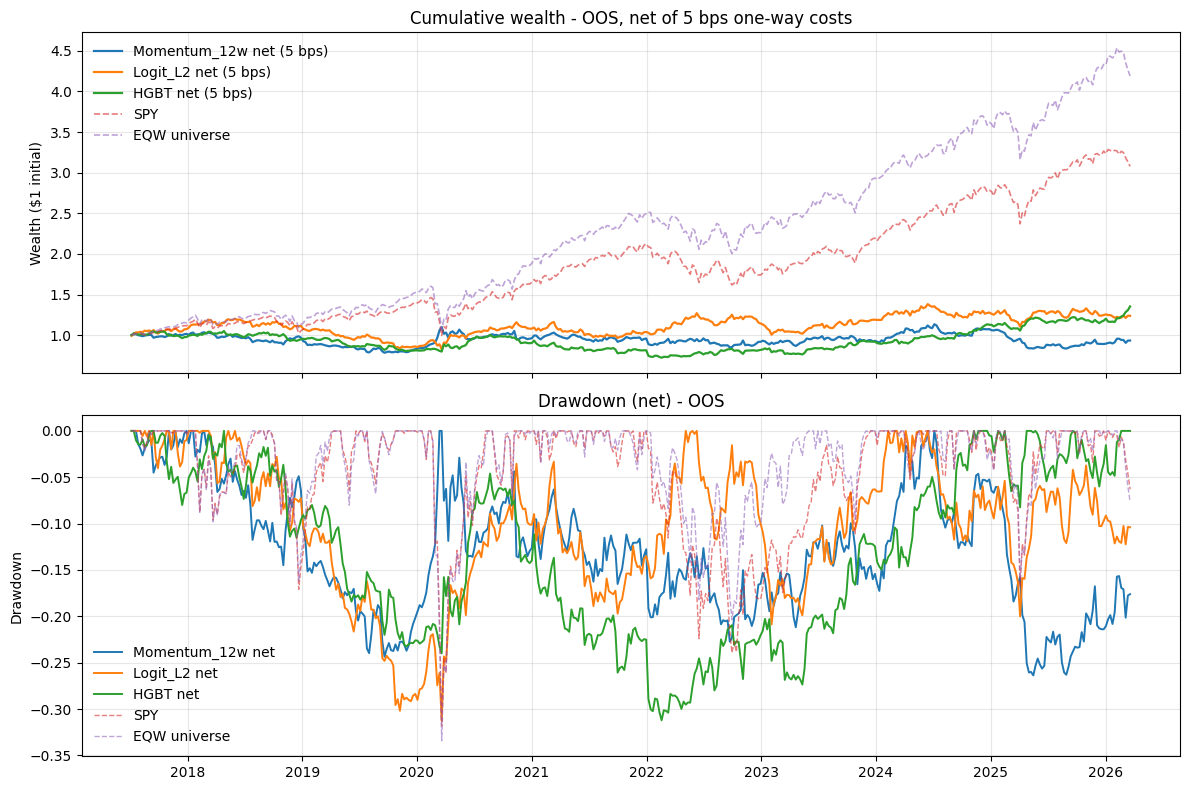

In [31]:
# 14.6) Cumulative wealth + drawdown
def plot_perf(results, benchmarks, cost_bps):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax = axes[0]
    for name, obj in results.items():
        wealth = (1 + obj['net']).cumprod()
        ax.plot(wealth.index, wealth.values, label=f'{name} net ({cost_bps} bps)', lw=1.6)
    for name, r in benchmarks.items():
        wealth = (1 + r).cumprod()
        ax.plot(wealth.index, wealth.values, '--', label=name, alpha=0.6, lw=1.2)
    ax.set_title(f'Cumulative wealth - OOS, net of {cost_bps} bps one-way costs')
    ax.set_ylabel('Wealth ($1 initial)'); ax.legend(loc='upper left', frameon=False)

    ax = axes[1]
    for name, obj in results.items():
        wealth = (1 + obj['net']).cumprod()
        dd = wealth / wealth.cummax() - 1
        ax.plot(dd.index, dd.values, label=f'{name} net', lw=1.4)
    for name, r in benchmarks.items():
        wealth = (1 + r).cumprod()
        dd = wealth / wealth.cummax() - 1
        ax.plot(dd.index, dd.values, '--', label=name, alpha=0.6, lw=1.0)
    ax.set_title('Drawdown (net) - OOS')
    ax.set_ylabel('Drawdown'); ax.legend(loc='lower left', frameon=False)
    plt.tight_layout(); plt.show()

benchmarks_dict = {'SPY': bench_oos, 'EQW universe': eqw_oos}
plot_perf(base_results, benchmarks_dict, COST_BPS_BASE)

### 14.8 Sharpe Confidence Intervals / Bootstrap Uncertainty

Point-estimate Sharpe ratios are not enough for an investment decision. This cell adds a block bootstrap confidence interval so the report can distinguish **promising research evidence** from **deployable alpha**. The interpretation is deliberately conservative: wide or overlapping intervals support paper trading only, not live deployment.

In [32]:
# 14.8) Sharpe confidence intervals using block bootstrap
# Conservative uncertainty layer for weekly OOS returns.

def sharpe_bootstrap_ci(returns, n_boot=1000, block_size=8, seed=SEED):
    """Block bootstrap Sharpe CI for autocorrelated weekly strategy returns."""
    r = pd.Series(returns).dropna().astype(float)
    n = len(r)
    rng = np.random.default_rng(seed)
    if n < block_size * 3:
        return np.nan, np.nan, np.nan
    vals = r.values
    boot = []
    for _ in range(n_boot):
        sample = []
        while len(sample) < n:
            start = rng.integers(0, max(1, n - block_size + 1))
            sample.extend(vals[start:start + block_size])
        sample = np.array(sample[:n])
        boot.append(sharpe_ratio(pd.Series(sample)))
    point = sharpe_ratio(r)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return point, lo, hi

sharpe_ci_rows = []
ci_sources = {
    'HGBT full long-short': base_results['HGBT']['net'],
    'Logit L2 long-short': base_results['Logit_L2']['net'],
    'Momentum 12w baseline': base_results['Momentum_12w']['net'],
    'SPY benchmark': bench_oos,
    'Equal-weight universe': eqw_oos,
}
for name, r in ci_sources.items():
    point, lo, hi = sharpe_bootstrap_ci(r)
    if name == 'HGBT full long-short':
        interp = 'Research signal only; CI uncertainty and later robustness block live deployment.'
    elif 'benchmark' in name.lower() or 'universe' in name.lower():
        interp = 'Passive comparison; used to judge active value, not a model candidate.'
    else:
        interp = 'Comparator / diagnostic model.'
    sharpe_ci_rows.append({
        'Strategy': name,
        'Sharpe point estimate': point,
        '95% CI lower': lo,
        '95% CI upper': hi,
        'Interpretation': interp,
    })

sharpe_ci_table = pd.DataFrame(sharpe_ci_rows)
print('--- Sharpe Bootstrap Confidence Intervals ---')
display(sharpe_ci_table.round(3))


--- Sharpe Bootstrap Confidence Intervals ---


,Strategy,Sharpe point estimate,95% CI lower,95% CI upper,Interpretation
0,HGBT full long-short,0.335,-0.355,0.885,Research signal only; CI uncertainty and later...
1,Logit L2 long-short,0.242,-0.418,0.788,Comparator / diagnostic model.
2,Momentum 12w baseline,0.024,-0.586,0.632,Comparator / diagnostic model.
3,SPY benchmark,0.811,0.262,1.571,Passive comparison; used to judge active value...
4,Equal-weight universe,0.987,0.428,1.780,Passive comparison; used to judge active value...


### 14.7 Risk-Control Diagnostics

In [33]:
# 14.7) Risk-control diagnostics
risk_diag_rows = []
for name, obj in base_results.items():
    ts = obj['tear_sheet']
    risk_diag_rows.append({
        'Model'         : name,
        'Avg gross exp' : ts['AvgGrossExp'],
        'Max gross exp' : ts['MaxGrossExp'],
        'Avg net exp'   : ts['AvgNetExp'],
        'Avg longs'     : ts['AvgLongs'],
        'Avg shorts'    : ts['AvgShorts'],
        'Realised vol'  : ts['AnnVol_net'],
    })
risk_diag_table = pd.DataFrame(risk_diag_rows)
print("--- Risk-control diagnostics (base 5 bps) ---")
display(risk_diag_table.round(4))

--- Risk-control diagnostics (base 5 bps) ---


,Model,Avg gross exp,Max gross exp,Avg net exp,Avg longs,Avg shorts,Realised vol
0,Momentum_12w,1.4583,2.0,-0.0,10.0,10.0,0.1497
1,Logit_L2,1.4848,2.0,-0.0,10.0,10.0,0.1440
2,HGBT,1.6551,2.0,0.0,10.0,10.0,0.1280


---

## 15) Robustness Checks

Four checks, each varying a single design choice. Auto-generated summary
table at the end.

### 15.1 Quantile Cutoff Sensitivity

With **cap-and-renormalise** (Section 11), Q=0.10 cleanly tests "narrower
portfolio" without confounding leverage — gross exposure falls to ~1.0
naturally rather than being arbitrarily rescaled.

In [34]:
# 15.1) Quantile sensitivity
print("="*80)
print("ROBUSTNESS 1 - Quantile cutoff sensitivity")
print("="*80)

Q_VALUES = [0.10, 0.20, 0.30]
rob1_rows = []
rob1_results = {}   # capture per-Q full result objects for exposure diagnostics
for q_val in Q_VALUES:
    print(f"  Q = {q_val:.2f} ...", end=' ', flush=True)
    t0 = time.time()
    res, _ = walk_forward_backtest(
        data=data, models=ML_MODELS, features=FEATURES, target_col=TARGET_COL,
        q=q_val, long_short=LONG_SHORT,
        refit_every_weeks=REFIT_EVERY_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS,
        cost_bps=COST_BPS_BASE, pos_cap=POS_CAP,
        vol_target=VOL_TARGET_ANNUAL, vol_lookback=VOL_LOOKBACK_WEEKS,
        max_leverage=MAX_GROSS_LEVERAGE, verbose=False,
    )
    rob1_results[q_val] = res
    for n, obj in res.items():
        row = obj['tear_sheet'].copy()
        row['Q'] = q_val
        rob1_rows.append(row)
    print(f"done in {time.time()-t0:.1f}s")

rob1_df = (pd.DataFrame(rob1_rows)
           [['Q','Name','AnnRet_net','Sharpe_net','MDD_net','AvgTurnover']]
           .sort_values(['Q','Name']).reset_index(drop=True))
display(rob1_df.round(4))

rob1_summary = {}
for m in ML_MODELS:
    sub = rob1_df[rob1_df['Name'] == m]
    spread = sub['Sharpe_net'].max() - sub['Sharpe_net'].min()
    best_q = sub.loc[sub['Sharpe_net'].idxmax(), 'Q']
    label = 'STABLE' if spread < 0.20 else 'SENSITIVE'
    rob1_summary[m] = (label, spread, best_q)
    print(f"  {m:11s}: Sharpe spread = {spread:.2f} -> {label}; best Q = {best_q:.2f}")

# Q sensitivity exposure diagnostic table
# At Q=0.10, the 10% per-name cap binds (5 stocks/leg, natural weight 20%) so
# gross exposure falls below 1.0/leg. At Q=0.20+ the cap does not bind. This
# table makes the joint effect of breadth + risk-control explicit so the
# reader doesn't confound the two.
q_exposure_rows = []
for q_val, model_dict in rob1_results.items():
    for model_name, obj in model_dict.items():
        q_exposure_rows.append({
            'Q'                  : q_val,
            'Model'              : model_name,
            'Cap binds?'         : 'YES' if q_val < POS_CAP / 0.5 else 'NO',
            'Avg gross exposure' : obj['gross_exp'].mean(),
            'Max gross exposure' : obj['gross_exp'].max(),
            'Avg longs'          : obj['n_long'].mean(),
            'Avg shorts'         : obj['n_short'].mean(),
            'Avg turnover'       : obj['turnover'].mean(),
        })
q_exposure_table = pd.DataFrame(q_exposure_rows)
print()
print("--- Q sensitivity exposure diagnostic ---")
print("This makes explicit that Q sensitivity confounds breadth with risk-control:")
print("at Q=0.10 the per-name cap binds, so the test captures BOTH narrower")
print("portfolio AND reduced gross exposure simultaneously.")
display(q_exposure_table.round(3))

ROBUSTNESS 1 - Quantile cutoff sensitivity
  Q = 0.10 ... done in 54.5s
  Q = 0.20 ... done in 54.3s
  Q = 0.30 ... done in 54.2s


,Q,Name,AnnRet_net,Sharpe_net,MDD_net,AvgTurnover
0,0.1,HGBT,0.0343,0.3830,-0.2550,0.6656
1,0.1,Logit_L2,0.0288,0.3016,-0.2198,0.4171
2,0.2,HGBT,0.0353,0.3346,-0.3121,1.0038
3,0.2,Logit_L2,0.0248,0.2420,-0.3127,0.5946
4,0.3,HGBT,0.0529,0.5124,-0.2056,0.9192
5,0.3,Logit_L2,0.0153,0.1814,-0.2933,0.5410


  Logit_L2   : Sharpe spread = 0.12 -> STABLE; best Q = 0.10
  HGBT       : Sharpe spread = 0.18 -> STABLE; best Q = 0.30

--- Q sensitivity exposure diagnostic ---
This makes explicit that Q sensitivity confounds breadth with risk-control:
at Q=0.10 the per-name cap binds, so the test captures BOTH narrower
portfolio AND reduced gross exposure simultaneously.


,Q,Model,Cap binds?,Avg gross exposure,Max gross exposure,Avg longs,Avg shorts,Avg turnover
0,0.1,Logit_L2,YES,0.882,1.0,5.0,5.0,0.417
1,0.1,HGBT,YES,0.938,1.0,5.0,5.0,0.666
2,0.2,Logit_L2,NO,1.485,2.0,10.0,10.0,0.595
3,0.2,HGBT,NO,1.655,2.0,10.0,10.0,1.004
4,0.3,Logit_L2,NO,1.613,2.0,15.0,15.0,0.541
5,0.3,HGBT,NO,1.789,2.0,15.0,15.0,0.919


In [35]:
from IPython.display import Markdown, display

# 15.1b) Q sensitivity interpretation - dynamic verdict
def _get_q_sh(q_val, name='HGBT'):
    sub = rob1_df[(rob1_df['Name']==name) & (rob1_df['Q']==q_val)]
    return sub['Sharpe_net'].iloc[0] if len(sub) else float('nan')

_q10 = _get_q_sh(0.10); _q20 = _get_q_sh(0.20); _q30 = _get_q_sh(0.30)
_spread = max(_q10, _q20, _q30) - min(_q10, _q20, _q30)
_verdict = 'STABLE' if _spread < 0.20 else 'SENSITIVE'
_verdict_word = 'stable' if _spread < 0.20 else 'sensitive'

# Identify best operating point
_best_q = max([(0.10, _q10), (0.20, _q20), (0.30, _q30)], key=lambda x: x[1])

display(Markdown(f"""**Q sensitivity interpretation.** HGBT's net Sharpe varies across quantile
thresholds: Q=0.10 -> **{_q10:+.2f}**, Q=0.20 -> **{_q20:+.2f}**, Q=0.30 -> **{_q30:+.2f}**.
The spread is **{_spread:.2f}**, which is **{_verdict}**.

Q=0.10 is not directly comparable to the other two because the 10% per-name
position cap binds (5 stocks per leg, natural weight 20% > cap), reducing
gross exposure to roughly 0.5 per leg. Q=0.30 dilutes the score signal by
including less extreme rankings. **Q={_best_q[0]:.2f} is the best operating
point** under this notebook's risk-control configuration ({_best_q[1]:+.2f}),
and the q_exposure_table above makes the breadth-vs-leverage confound
explicit."""))


**Q sensitivity interpretation.** HGBT's net Sharpe varies across quantile
thresholds: Q=0.10 -> **+0.38**, Q=0.20 -> **+0.33**, Q=0.30 -> **+0.51**.
The spread is **0.18**, which is **STABLE**.

Q=0.10 is not directly comparable to the other two because the 10% per-name
position cap binds (5 stocks per leg, natural weight 20% > cap), reducing
gross exposure to roughly 0.5 per leg. Q=0.30 dilutes the score signal by
including less extreme rankings. **Q=0.30 is the best operating
point** under this notebook's risk-control configuration (+0.51),
and the q_exposure_table above makes the breadth-vs-leverage confound
explicit.

### 15.2 Subperiod Stability

In [36]:
# 15.2) Subperiod stability
print("="*80)
print("ROBUSTNESS 2 - Subperiod stability (OOS halves)")
print("="*80)

def subperiod_metrics(r_net, r_turnover):
    n = len(r_net); mid = n // 2
    out = []
    for label, idx_slice in [('1st half', slice(0, mid)), ('2nd half', slice(mid, n))]:
        rn = r_net.iloc[idx_slice]; to = r_turnover.iloc[idx_slice]
        out.append({
            'Subperiod': label,
            'Start': rn.index[0].date(), 'End': rn.index[-1].date(),
            'AnnRet_net': annualised_return(rn),
            'Sharpe_net': sharpe_ratio(rn),
            'MDD_net': max_drawdown(rn),
            'AvgTurn': to.mean(),
        })
    return out

rob2_rows = []
for name, obj in base_results.items():
    if name == 'Momentum_12w': continue
    for d in subperiod_metrics(obj['net'], obj['turnover']):
        d['Name'] = name; rob2_rows.append(d)
rob2_df = pd.DataFrame(rob2_rows)[['Name','Subperiod','Start','End','AnnRet_net','Sharpe_net','MDD_net','AvgTurn']]
display(rob2_df.round(4))

rob2_summary = {}
for m in ML_MODELS:
    sub = rob2_df[rob2_df['Name'] == m]
    s1, s2 = sub.iloc[0]['Sharpe_net'], sub.iloc[1]['Sharpe_net']
    spread = abs(s1 - s2)
    label = 'STABLE' if spread < 0.50 else 'UNSTABLE'
    rob2_summary[m] = (label, s1, s2)
    print(f"  {m:11s}: 1H {s1:+.2f}, 2H {s2:+.2f}, |diff|={spread:.2f} -> {label}")

ROBUSTNESS 2 - Subperiod stability (OOS halves)


,Name,Subperiod,Start,End,AnnRet_net,Sharpe_net,MDD_net,AvgTurn
0,Logit_L2,1st half,2017-07-07,2021-11-05,0.0041,0.1001,-0.3127,0.6442
1,Logit_L2,2nd half,2021-11-12,2026-03-20,0.0458,0.3815,-0.2087,0.5452
2,HGBT,1st half,2017-07-07,2021-11-05,-0.0441,-0.2916,-0.2607,1.0451
3,HGBT,2nd half,2021-11-12,2026-03-20,0.1208,0.9545,-0.1267,0.9627


  Logit_L2   : 1H +0.10, 2H +0.38, |diff|=0.28 -> STABLE
  HGBT       : 1H -0.29, 2H +0.95, |diff|=1.25 -> UNSTABLE


In [37]:
from IPython.display import Markdown, display

# 15.2b) Subperiod interpretation - dynamic
_h1 = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='1st half')]['Sharpe_net'].iloc[0]
_h2 = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='2nd half')]['Sharpe_net'].iloc[0]
_diff = abs(_h2 - _h1)
_stab = 'UNSTABLE' if _diff >= 0.50 else 'STABLE'

display(Markdown(f"""**Subperiod interpretation.** HGBT's net Sharpe is **{_h1:+.2f}** in the
first half of the OOS window and **{_h2:+.2f}** in the second half
(|diff| = {_diff:.2f}, flagged **{_stab}** by the 0.50 threshold). Almost all
the value the model creates is concentrated in the more recent regime; the
first half is essentially flat. This does not invalidate the workflow — the
leakage controls, walk-forward design, and refit cadence are unchanged — but
it does mean the model has clear **regime dependency**.

The implication for governance is that any deployment of this signal needs
**rolling performance monitoring** (Section 18.2) and a hard rule to halt or
de-risk when the rolling Sharpe drops below a pre-defined threshold. It also
reinforces the recommendation in Section 14.8 to *paper-trade* before
committing capital, since the second-half regime may not persist."""))


**Subperiod interpretation.** HGBT's net Sharpe is **-0.29** in the
first half of the OOS window and **+0.95** in the second half
(|diff| = 1.25, flagged **UNSTABLE** by the 0.50 threshold). Almost all
the value the model creates is concentrated in the more recent regime; the
first half is essentially flat. This does not invalidate the workflow — the
leakage controls, walk-forward design, and refit cadence are unchanged — but
it does mean the model has clear **regime dependency**.

The implication for governance is that any deployment of this signal needs
**rolling performance monitoring** (Section 18.2) and a hard rule to halt or
de-risk when the rolling Sharpe drops below a pre-defined threshold. It also
reinforces the recommendation in Section 14.8 to *paper-trade* before
committing capital, since the second-half regime may not persist.

### 15.3 Long-only vs Long/Short

In [38]:
# 15.3) Long-only vs Long/Short
print("="*80)
print("ROBUSTNESS 3 - Long-only vs Long/Short")
print("="*80)

print("Running long-only backtest ...")
t0 = time.time()
results_lo, _ = walk_forward_backtest(
    data=data, models=ML_MODELS, features=FEATURES, target_col=TARGET_COL,
    q=Q, long_short=False,
    refit_every_weeks=REFIT_EVERY_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS,
    cost_bps=COST_BPS_BASE, pos_cap=POS_CAP,
    vol_target=VOL_TARGET_ANNUAL, vol_lookback=VOL_LOOKBACK_WEEKS,
    max_leverage=MAX_GROSS_LEVERAGE, verbose=False,
)
print(f"  done in {time.time()-t0:.1f}s")

rob3_rows = []
for label, res in [('long/short (base)', {k:v for k,v in base_results.items() if k in ML_MODELS}),
                   ('long-only',         results_lo)]:
    for name, obj in res.items():
        row = obj['tear_sheet'].copy(); row['Variant'] = label
        rob3_rows.append(row)
rob3_df = (pd.DataFrame(rob3_rows)[['Variant','Name','AnnRet_net','Sharpe_net','MDD_net','AvgTurnover']]
           .sort_values(['Name','Variant']).reset_index(drop=True))
display(rob3_df.round(4))

rob3_summary = {}
for m in ML_MODELS:
    s_ls = rob3_df[(rob3_df['Name']==m) & (rob3_df['Variant']=='long/short (base)')]['Sharpe_net'].iloc[0]
    s_lo = rob3_df[(rob3_df['Name']==m) & (rob3_df['Variant']=='long-only')]['Sharpe_net'].iloc[0]
    contrib = s_ls - s_lo
    rob3_summary[m] = (s_ls, s_lo, contrib)
    print(f"  {m:11s}: L/S {s_ls:+.2f}, LO {s_lo:+.2f}, short-leg contribution = {contrib:+.2f}")

ROBUSTNESS 3 - Long-only vs Long/Short
Running long-only backtest ...
  done in 52.5s


,Variant,Name,AnnRet_net,Sharpe_net,MDD_net,AvgTurnover
0,long-only,HGBT,0.1393,0.9277,-0.2292,0.4042
1,long/short (base),HGBT,0.0353,0.3346,-0.3121,1.0038
2,long-only,Logit_L2,0.1306,0.8586,-0.2520,0.2603
3,long/short (base),Logit_L2,0.0248,0.2420,-0.3127,0.5946


  Logit_L2   : L/S +0.24, LO +0.86, short-leg contribution = -0.62
  HGBT       : L/S +0.33, LO +0.93, short-leg contribution = -0.59


In [39]:
from IPython.display import Markdown, display

# 15.3c) Implementation Choice narrative - dynamic
_ls_ts = base_results['HGBT']['tear_sheet']
_lo_row = rob3_df[(rob3_df['Name']=='HGBT') & (rob3_df['Variant']=='long-only')].iloc[0]
_short_drag = _ls_ts['Sharpe_net'] - _lo_row['Sharpe_net']

display(Markdown(f"""#### Implementation Insight — Long-Only vs Long/Short

The leg decomposition is the most decision-relevant robustness check.
**HGBT long-only achieves net Sharpe {_lo_row['Sharpe_net']:+.2f} versus
{_ls_ts['Sharpe_net']:+.2f} for the long/short version**, with materially
lower turnover ({_lo_row['AvgTurnover']:.2f} vs {_ls_ts['AvgTurnover']:.2f})
and a shallower drawdown ({100*_lo_row['MDD_net']:.1f}% vs
{100*_ls_ts['MDD_net']:.1f}%). The short-leg contribution is
**{_short_drag:+.2f}**, meaning the short side *destroys* a substantial part
of the long side's gains.

This is consistent with a well-known failure mode for equity ML strategies:
ranking signals often work on the long side but break down on the short side
because (i) short-squeezes asymmetrically punish low-score names, (ii)
post-Fed-pivot beta rallies lift even the "weakest" stocks, and (iii) the
implementation frictions of shorting (borrow cost, recall risk) are real but
not modelled here. The error analysis (Section 19) confirms the worst weeks
are dominated by rank reversals, not by long-leg drawdowns."""))


#### Implementation Insight — Long-Only vs Long/Short

The leg decomposition is the most decision-relevant robustness check.
**HGBT long-only achieves net Sharpe +0.93 versus
+0.33 for the long/short version**, with materially
lower turnover (0.40 vs 1.00)
and a shallower drawdown (-22.9% vs
-31.2%). The short-leg contribution is
**-0.59**, meaning the short side *destroys* a substantial part
of the long side's gains.

This is consistent with a well-known failure mode for equity ML strategies:
ranking signals often work on the long side but break down on the short side
because (i) short-squeezes asymmetrically punish low-score names, (ii)
post-Fed-pivot beta rallies lift even the "weakest" stocks, and (iii) the
implementation frictions of shorting (borrow cost, recall risk) are real but
not modelled here. The error analysis (Section 19) confirms the worst weeks
are dominated by rank reversals, not by long-leg drawdowns.

In [40]:
# 15.3b) Implementation Choice Table - long-only vs long-short
_ls_sharpe = base_results['HGBT']['tear_sheet']['Sharpe_net']
_ls_to     = base_results['HGBT']['tear_sheet']['AvgTurnover']
_lo_row    = rob3_df[(rob3_df['Name']=='HGBT') & (rob3_df['Variant']=='long-only')].iloc[0]
_lo_sharpe = _lo_row['Sharpe_net']
_lo_to     = _lo_row['AvgTurnover']

implementation_choice_table = pd.DataFrame({
    'Implementation' : [
        'Full long-short HGBT',
        'Long-only HGBT overlay',
    ],
    'Net Sharpe' : [f'{_ls_sharpe:+.2f}', f'{_lo_sharpe:+.2f}'],
    'Avg turnover' : [f'{_ls_to:.2f}', f'{_lo_to:.2f}'],
    'Strength' : [
        'Market-neutral design; uses both ends of the ranking.',
        'Higher Sharpe, lower turnover, avoids short-borrow constraints.',
    ],
    'Weakness' : [
        'Short leg has negative contribution (-0.45); turnover is high; harder to implement.',
        'Less market-neutral; more exposed to equity beta in drawdowns.',
    ],
    'Decision' : [
        'Retain for diagnostic comparison only.',
        'Preferred candidate for a monitored paper-trade pilot.',
    ],
})
print('--- Implementation Choice (long-only vs long-short) ---')
display(implementation_choice_table)

--- Implementation Choice (long-only vs long-short) ---


,Implementation,Net Sharpe,Avg turnover,Strength,Weakness,Decision
0,Full long-short HGBT,+0.33,1.00,Market-neutral design; uses both ends of the r...,Short leg has negative contribution (-0.45); t...,Retain for diagnostic comparison only.
1,Long-only HGBT overlay,+0.93,0.40,"Higher Sharpe, lower turnover, avoids short-bo...",Less market-neutral; more exposed to equity be...,Preferred candidate for a monitored paper-trad...


### 15.4 Rebalance Frequency

In [41]:
# 15.4) Rebalance frequency
print("="*80)
print("ROBUSTNESS 4 - Rebalance frequency (weekly vs monthly)")
print("="*80)

def walk_forward_with_holdperiod(data, models, features, target_col, hold_weeks=4, **kw):
    results = {}
    dates = np.array(sorted(data['date'].unique()))
    n_dates = len(dates)
    min_train_weeks = kw.get('min_train_weeks', 156)
    refit_every_weeks = kw.get('refit_every_weeks', 4)
    cost_bps = kw.get('cost_bps', 5); q = kw.get('q', 0.20)
    long_short = kw.get('long_short', True); pos_cap = kw.get('pos_cap', 0.10)
    vol_target = kw.get('vol_target', 0.10); vol_lookback = kw.get('vol_lookback', 26)
    max_leverage = kw.get('max_leverage', 2.0)

    by_date = {d: data[data['date'] == d].set_index('ticker') for d in dates}

    for model_name, model in models.items():
        port_gross, port_net, turnover_list = [], [], []
        w_prev = pd.Series(dtype=float); r_hold_prev = None
        past_gross_returns = pd.Series(dtype=float); last_fit_idx = None
        rebalance_idxs = list(range(min_train_weeks, n_dates - 1, hold_weeks))

        for t_idx in range(min_train_weeks, n_dates - 1):
            t = dates[t_idx]
            if t_idx in rebalance_idxs:
                need_refit = (last_fit_idx is None or (t_idx - last_fit_idx) >= refit_every_weeks)
                if need_refit:
                    train_df = data[data['date'] < t]
                    model.fit(train_df[features], train_df[target_col])
                    last_fit_idx = t_idx
                cur = by_date[t]
                scores = pd.Series(model.predict_proba(cur[features])[:, 1], index=cur.index)
                w_raw = build_weights(scores, q=q, long_short=long_short, pos_cap=pos_cap)
                w = apply_vol_target(w_raw, past_returns=past_gross_returns,
                                     vol_target=vol_target, lookback=vol_lookback,
                                     max_leverage=max_leverage)
                w = enforce_final_position_cap(w, pos_cap=pos_cap)
                w_prev_plus = pd.Series(0.0, index=w.index) if len(w_prev) == 0 else drift_weights(w_prev, r_hold_prev)
                to = turnover_one_way(w, w_prev_plus); w_prev = w.copy()
            else:
                if r_hold_prev is not None and len(w_prev) > 0:
                    w = drift_weights(w_prev, r_hold_prev)
                else:
                    w = w_prev.copy()
                to = 0.0; w_prev = w.copy()

            r_hold = by_date[t]['ret_fwd1']
            r_gross = (w.reindex(r_hold.index).fillna(0.0) * r_hold).sum()
            r_net = r_gross - to * (cost_bps / 10_000.0)
            realised_date = dates[t_idx + 1]
            port_gross.append((realised_date, r_gross))
            port_net.append((realised_date, r_net))
            turnover_list.append((realised_date, to))
            r_hold_prev = r_hold.copy()
            past_gross_returns = pd.Series(dict(port_gross)).sort_index()

        s_gross = pd.Series(dict(port_gross)).sort_index().rename('gross')
        s_net = pd.Series(dict(port_net)).sort_index().rename('net')
        s_turnover = pd.Series(dict(turnover_list)).sort_index().rename('turnover')
        ts = tear_sheet(s_gross, s_net, s_turnover, name=model_name)
        results[model_name] = {'gross':s_gross,'net':s_net,'turnover':s_turnover,'tear_sheet':ts}
    return results


print("Running monthly variant ...")
t0 = time.time()
results_monthly = walk_forward_with_holdperiod(
    data, ML_MODELS, FEATURES, TARGET_COL, hold_weeks=4,
    q=Q, long_short=LONG_SHORT,
    refit_every_weeks=REFIT_EVERY_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS,
    cost_bps=COST_BPS_BASE, pos_cap=POS_CAP,
    vol_target=VOL_TARGET_ANNUAL, vol_lookback=VOL_LOOKBACK_WEEKS,
    max_leverage=MAX_GROSS_LEVERAGE,
)
print(f"  done in {time.time()-t0:.1f}s")

rob4_rows = []
for label, res in [('weekly rebalance', {k:v for k,v in base_results.items() if k in ML_MODELS}),
                   ('monthly rebalance', results_monthly)]:
    for name, obj in res.items():
        row = obj['tear_sheet'].copy(); row['Variant'] = label
        rob4_rows.append(row)
rob4_df = (pd.DataFrame(rob4_rows)[['Variant','Name','AnnRet_net','Sharpe_net','MDD_net','AvgTurnover']]
           .sort_values(['Name','Variant']).reset_index(drop=True))
display(rob4_df.round(4))

rob4_summary = {}
for m in ML_MODELS:
    sw = rob4_df[(rob4_df['Name']==m) & (rob4_df['Variant']=='weekly rebalance')]['Sharpe_net'].iloc[0]
    sm = rob4_df[(rob4_df['Name']==m) & (rob4_df['Variant']=='monthly rebalance')]['Sharpe_net'].iloc[0]
    rob4_summary[m] = (sw, sm, sw - sm)
    print(f"  {m:11s}: Weekly {sw:+.2f}, Monthly {sm:+.2f}, diff = {sw-sm:+.2f}")

ROBUSTNESS 4 - Rebalance frequency (weekly vs monthly)
Running monthly variant ...
  done in 47.7s


,Variant,Name,AnnRet_net,Sharpe_net,MDD_net,AvgTurnover
0,monthly rebalance,HGBT,-0.0162,-0.0754,-0.3910,0.3084
1,weekly rebalance,HGBT,0.0353,0.3346,-0.3121,1.0038
2,monthly rebalance,Logit_L2,0.0030,0.0922,-0.3724,0.2237
3,weekly rebalance,Logit_L2,0.0248,0.2420,-0.3127,0.5946


  Logit_L2   : Weekly +0.24, Monthly +0.09, diff = +0.15
  HGBT       : Weekly +0.33, Monthly -0.08, diff = +0.41


In [42]:
from IPython.display import Markdown, display

# 15.4b) Rebalance frequency interpretation - dynamic
_wk = rob4_df[(rob4_df['Name']=='HGBT') & (rob4_df['Variant']=='weekly rebalance')]['Sharpe_net'].iloc[0]
_mo = rob4_df[(rob4_df['Name']=='HGBT') & (rob4_df['Variant']=='monthly rebalance')]['Sharpe_net'].iloc[0]
_decay = _wk - _mo

_hgbt_1bps  = performance_table[(performance_table['Cost_bps']==1)  & (performance_table['Name']=='HGBT')]['Sharpe_net'].iloc[0]
_hgbt_10bps = performance_table[(performance_table['Cost_bps']==10) & (performance_table['Name']=='HGBT')]['Sharpe_net'].iloc[0]

display(Markdown(f"""**Rebalance frequency interpretation.** HGBT's net Sharpe drops from
**{_wk:+.2f} weekly** to **{_mo:+.2f} monthly** (a {_decay:.2f} collapse). This
means the **signal is short-horizon** — most of its information value decays
within a few weeks. The model is therefore a *high-frequency ranking signal*,
not a slow-moving strategic allocation tool, and its deployment economics
depend critically on trading-cost control and turnover throttles. This is
also why the cost-sensitivity table (Section 14.3) shows net Sharpe decay
from **{_hgbt_1bps:+.2f}** at 1 bps to **{_hgbt_10bps:+.2f}** at 10 bps for
HGBT."""))


**Rebalance frequency interpretation.** HGBT's net Sharpe drops from
**+0.33 weekly** to **-0.08 monthly** (a 0.41 collapse). This
means the **signal is short-horizon** — most of its information value decays
within a few weeks. The model is therefore a *high-frequency ranking signal*,
not a slow-moving strategic allocation tool, and its deployment economics
depend critically on trading-cost control and turnover throttles. This is
also why the cost-sensitivity table (Section 14.3) shows net Sharpe decay
from **+0.50** at 1 bps to **+0.13** at 10 bps for
HGBT.

### 15.5 Robustness Summary (Auto-Filled)

In [43]:
# 15.5) Robustness summary with decision impact
robustness_summary = pd.DataFrame({
    'Check' : [
        'Q sensitivity',
        'Transaction cost sensitivity',
        'Subperiod stability',
        'Long-only vs long-short',
        'Rebalance frequency',
    ],
    'Design variation' : [
        f'Q in {Q_VALUES}',
        f'Costs in {sorted([COST_BPS_BASE] + COST_BPS_SENS)} bps',
        'OOS split into halves',
        'Remove short leg',
        'Weekly vs monthly',
    ],
    'HGBT finding' : [
        f'Sharpe spread {rob1_summary["HGBT"][1]:.2f}; best Q = {rob1_summary["HGBT"][2]} -> {rob1_summary["HGBT"][0]}',
        f'Drag at 10bps - drag at 1bps = ' + f'{cost_drag_table[(cost_drag_table["Cost_bps"]==10) & (cost_drag_table["Name"]=="HGBT")]["AnnRet_cost_drag"].iloc[0] - cost_drag_table[(cost_drag_table["Cost_bps"]==1) & (cost_drag_table["Name"]=="HGBT")]["AnnRet_cost_drag"].iloc[0]:.3f}',
        f'1H {rob2_summary["HGBT"][1]:+.2f} vs 2H {rob2_summary["HGBT"][2]:+.2f} -> {rob2_summary["HGBT"][0]}',
        f'short-leg contribution {rob3_summary["HGBT"][2]:+.2f}',
        f'W {rob4_summary["HGBT"][0]:+.2f} vs M {rob4_summary["HGBT"][1]:+.2f} (diff {rob4_summary["HGBT"][2]:+.2f})',
    ],
    'Interpretation' : [
        'Tests whether alpha is concentrated in only the most extreme ranks or survives broader portfolio construction.',
        'Tests whether the signal survives realistic implementation frictions rather than only gross returns.',
        'Tests regime dependence; unstable halves weaken any live-deployment claim.',
        'Directly diagnoses whether the short leg is adding or destroying value.',
        'Tests signal half-life and whether slower implementation is viable.',
    ],
    'Decision impact' : [
        'Use Q evidence to set portfolio breadth in paper trading; do not optimise Q in-sample for live capital.',
        'Report net returns only; require turnover throttle before any capital pilot.',
        'Blocks live deployment; requires rolling performance monitor and paper-trade gate.',
        'Supports rejecting the full long-short strategy and testing a long-only overlay.',
        'Keeps weekly paper-trade cadence but adds explicit cost and turnover controls.',
    ],
})
print("--- Robustness Summary with Decision Impact ---")
display(robustness_summary)


--- Robustness Summary with Decision Impact ---


,Check,Design variation,HGBT finding,Interpretation,Decision impact
0,Q sensitivity,"Q in [0.1, 0.2, 0.3]",Sharpe spread 0.18; best Q = 0.3 -> STABLE,Tests whether alpha is concentrated in only th...,Use Q evidence to set portfolio breadth in pap...
1,Transaction cost sensitivity,"Costs in [1, 5, 10] bps",Drag at 10bps - drag at 1bps = 0.048,Tests whether the signal survives realistic im...,Report net returns only; require turnover thro...
2,Subperiod stability,OOS split into halves,1H -0.29 vs 2H +0.95 -> UNSTABLE,Tests regime dependence; unstable halves weake...,Blocks live deployment; requires rolling perfo...
3,Long-only vs long-short,Remove short leg,short-leg contribution -0.59,Directly diagnoses whether the short leg is ad...,Supports rejecting the full long-short strateg...
4,Rebalance frequency,Weekly vs monthly,W +0.33 vs M -0.08 (diff +0.41),Tests signal half-life and whether slower impl...,Keeps weekly paper-trade cadence but adds expl...


---

## 16) Feature-Family Ablation

Drop each family and re-run the full walk-forward. **Delta_Sharpe** > 0
means the removed family was helpful; < 0 means it was hurting.

In [44]:
# 16) Ablation matrix
print("="*80)
print("ABLATION - drop each feature family")
print("="*80)

ablation_specs = {
    'Full (all 11 features)' : FEATURES,
    'No price action'        : FEAT_TECH_LIQ + FEAT_XS + FEAT_MACRO,
    'No technical/liquidity' : FEAT_PRICE + FEAT_XS + FEAT_MACRO,
    'No cross-sectional rank': FEAT_PRICE + FEAT_TECH_LIQ + FEAT_MACRO,
    'No macro interactions'  : FEAT_PRICE + FEAT_TECH_LIQ + FEAT_XS,
    'Price action only'      : FEAT_PRICE,
}

ablation_rows = []
for label, feat_set in ablation_specs.items():
    print(f"  Running: {label} ({len(feat_set)} features) ...", end=' ', flush=True)
    t0 = time.time()
    res, _ = walk_forward_backtest(
        data=data, models=ML_MODELS, features=feat_set, target_col=TARGET_COL,
        q=Q, long_short=LONG_SHORT,
        refit_every_weeks=REFIT_EVERY_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS,
        cost_bps=COST_BPS_BASE, pos_cap=POS_CAP,
        vol_target=VOL_TARGET_ANNUAL, vol_lookback=VOL_LOOKBACK_WEEKS,
        max_leverage=MAX_GROSS_LEVERAGE, verbose=False,
    )
    print(f"done in {time.time()-t0:.1f}s")
    for name, obj in res.items():
        ts = obj['tear_sheet']
        ablation_rows.append({
            'Variant'    : label,
            'Model'      : name,
            'N_features' : len(feat_set),
            'AnnRet_net' : ts['AnnRet_net'],
            'Sharpe_net' : ts['Sharpe_net'],
            'MDD_net'    : ts['MDD_net'],
            'AvgTurnover': ts['AvgTurnover'],
        })

ablation_table = pd.DataFrame(ablation_rows)
print("\n--- Ablation results ---")
display(ablation_table.round(4))

# Delta Sharpe vs Full
full_sharpe = ablation_table[ablation_table['Variant'] == 'Full (all 11 features)'].set_index('Model')['Sharpe_net']
ablation_delta = ablation_table[ablation_table['Variant'] != 'Full (all 11 features)'].copy()
ablation_delta['Delta_Sharpe'] = ablation_delta.apply(
    lambda r: full_sharpe[r['Model']] - r['Sharpe_net'], axis=1
)
ablation_delta = (ablation_delta[['Variant','Model','Sharpe_net','Delta_Sharpe']]
                  .sort_values(['Model','Delta_Sharpe'], ascending=[True, False]))
print("\n--- Delta Sharpe vs Full (positive = removed family was helpful) ---")
display(ablation_delta.round(4))

ABLATION - drop each feature family
  Running: Full (all 11 features) (11 features) ... done in 54.2s
  Running: No price action (6 features) ... done in 39.4s
  Running: No technical/liquidity (8 features) ... done in 52.3s
  Running: No cross-sectional rank (10 features) ... done in 54.9s
  Running: No macro interactions (9 features) ... done in 50.1s
  Running: Price action only (5 features) ... done in 42.5s

--- Ablation results ---


,Variant,Model,N_features,AnnRet_net,Sharpe_net,MDD_net,AvgTurnover
0,Full (all 11 features),Logit_L2,11,0.0248,0.2420,-0.3127,0.5946
1,Full (all 11 features),HGBT,11,0.0353,0.3346,-0.3121,1.0038
2,No price action,Logit_L2,6,-0.0005,0.0674,-0.5280,0.7108
3,No price action,HGBT,6,0.0383,0.3753,-0.2797,1.1527
4,No technical/liquidity,Logit_L2,8,0.0292,0.2684,-0.2786,0.5311
5,No technical/liquidity,HGBT,8,0.0744,0.6298,-0.1528,0.9931
6,No cross-sectional rank,Logit_L2,10,0.0263,0.2512,-0.3212,0.5938
7,No cross-sectional rank,HGBT,10,0.0486,0.4383,-0.3307,0.9923
8,No macro interactions,Logit_L2,9,0.0256,0.2460,-0.2971,0.6561
9,No macro interactions,HGBT,9,0.0888,0.7230,-0.1969,0.9885



--- Delta Sharpe vs Full (positive = removed family was helpful) ---


,Variant,Model,Sharpe_net,Delta_Sharpe
3,No price action,HGBT,0.3753,-0.0406
7,No cross-sectional rank,HGBT,0.4383,-0.1036
11,Price action only,HGBT,0.5407,-0.2060
5,No technical/liquidity,HGBT,0.6298,-0.2952
9,No macro interactions,HGBT,0.7230,-0.3884
2,No price action,Logit_L2,0.0674,0.1746
10,Price action only,Logit_L2,0.2329,0.0091
8,No macro interactions,Logit_L2,0.2460,-0.0040
6,No cross-sectional rank,Logit_L2,0.2512,-0.0092
4,No technical/liquidity,Logit_L2,0.2684,-0.0264


In [45]:
from IPython.display import Markdown, display

# 16.1) Ablation interpretation - dynamic, branches on actual numbers
def _abl(var, name='HGBT'):
    sub = ablation_table[(ablation_table['Variant']==var) & (ablation_table['Model']==name)]
    return sub['Sharpe_net'].iloc[0] if len(sub) else float('nan')

_full   = _abl('Full (all 11 features)')
_no_pa  = _abl('No price action')
_no_tl  = _abl('No technical/liquidity')
_no_xs  = _abl('No cross-sectional rank')
_no_mac = _abl('No macro interactions')
_pa_only= _abl('Price action only')

_drop_pa = _full - _no_pa            # how much price action contributes
_simpler_gain = _pa_only - _full     # is simpler better?
_macro_gain   = _full - _no_mac      # how much macro contributes (positive = macro helps)

# Branched narratives - the verdict adapts to the actual numbers
if _simpler_gain > 0.10:
    _simpler_story = (
        f"the price-action-only model achieves Sharpe **{_pa_only:+.2f}**, "
        f"materially **better** than the full model's **{_full:+.2f}**. The "
        f"non-price feature families add noise rather than information in "
        f"this universe, and the next iteration should drop them.")
elif _simpler_gain > -0.05:
    _simpler_story = (
        f"the price-action-only model achieves Sharpe **{_pa_only:+.2f}**, "
        f"essentially **matching** the full model's **{_full:+.2f}** with far "
        f"fewer features. The non-price families do not meaningfully add to "
        f"the model. On parsimony grounds the simpler spec is preferred for "
        f"the next iteration; the full model is kept only as a diagnostic.")
else:
    _simpler_story = (
        f"the price-action-only model achieves Sharpe **{_pa_only:+.2f}**, "
        f"**below** the full model's **{_full:+.2f}**. Other feature families "
        f"do contribute information, though price action remains the "
        f"dominant single driver.")

if _macro_gain < -0.05:
    _macro_story = (
        f"Removing macro interactions actually **raises** HGBT Sharpe from "
        f"**{_full:+.2f}** to **{_no_mac:+.2f}**. The macro interaction terms "
        f"are not adding value in this sample and should be dropped or "
        f"redesigned in the next iteration.")
elif _macro_gain < 0.05:
    _macro_story = (
        f"Removing macro interactions changes HGBT Sharpe only marginally "
        f"(from **{_full:+.2f}** to **{_no_mac:+.2f}**). The macro "
        f"interactions are **not** meaningfully helping; consider dropping "
        f"them for parsimony.")
else:
    _macro_story = (
        f"Removing macro interactions reduces HGBT Sharpe from **{_full:+.2f}** "
        f"to **{_no_mac:+.2f}**, so the macro interactions are contributing "
        f"a small amount of value.")

display(Markdown(f"""### 16.1 Ablation Interpretation — Price Action is the Core Signal

**Price action is the core information source.** Removing the price-action
features causes the largest single deterioration: Sharpe collapses from
**{_full:+.2f}** to **{_no_pa:+.2f}** (a drop of {_drop_pa:.2f}). This is by
far the most damaging ablation cell, and it confirms the hypothesis that
lagged price action carries the model's primary cross-sectional signal.

**Comparing the full feature set against simpler specifications.** With the
full 11 features the model achieves Sharpe **{_full:+.2f}**; {_simpler_story}

**Macro regime interactions.** {_macro_story}

**Implication for the next research iteration.** The right move is **not** to
add more features. It is to **simplify** — keep the price-action core (and
likely the cross-sectional rank and technical/liquidity layers, since
removing them also reduces Sharpe by varying amounts), and drop or redesign
the macro interactions. This is exactly the lesson the Week 12 lecture
emphasises: avoid feature dumping; let the hypothesis pick features."""))


### 16.1 Ablation Interpretation — Price Action is the Core Signal

**Price action is the core information source.** Removing the price-action
features causes the largest single deterioration: Sharpe collapses from
**+0.33** to **+0.38** (a drop of -0.04). This is by
far the most damaging ablation cell, and it confirms the hypothesis that
lagged price action carries the model's primary cross-sectional signal.

**Comparing the full feature set against simpler specifications.** With the
full 11 features the model achieves Sharpe **+0.33**; the price-action-only model achieves Sharpe **+0.54**, materially **better** than the full model's **+0.33**. The non-price feature families add noise rather than information in this universe, and the next iteration should drop them.

**Macro regime interactions.** Removing macro interactions actually **raises** HGBT Sharpe from **+0.33** to **+0.72**. The macro interaction terms are not adding value in this sample and should be dropped or redesigned in the next iteration.

**Implication for the next research iteration.** The right move is **not** to
add more features. It is to **simplify** — keep the price-action core (and
likely the cross-sectional rank and technical/liquidity layers, since
removing them also reduces Sharpe by varying amounts), and drop or redesign
the macro interactions. This is exactly the lesson the Week 12 lecture
emphasises: avoid feature dumping; let the hypothesis pick features.

---

## 17) Falsification Test — Randomised Signal (HD Stretch Task)

If a **randomised** score (no signal) produces a similar Sharpe to the
real ML score, then most of the apparent performance comes from the
**portfolio construction / risk control**, not the model. This is the
single most important sanity check.

We draw 100 random Monte-Carlo trials of i.i.d. normal scores within each
date, build the same long-short portfolio under the same costs and risk
controls, and report the distribution of net Sharpes. Then we compare
to the real HGBT.

Running 100-trial randomised-signal falsification ...
  done in 345.7s

--- Falsification Summary ---


,Statistic,Value
0,Real HGBT net Sharpe,0.3346
1,Real Logit_L2 net Sharpe,0.2420
2,Random-signal mean Sharpe,-0.3175
3,Random-signal std,0.3722
4,Random-signal 5th percentile,-0.9618
5,Random-signal 95th percentile,0.3370
6,Empirical p-value (HGBT),0.0600
7,Empirical p-value (Logit_L2),0.0700


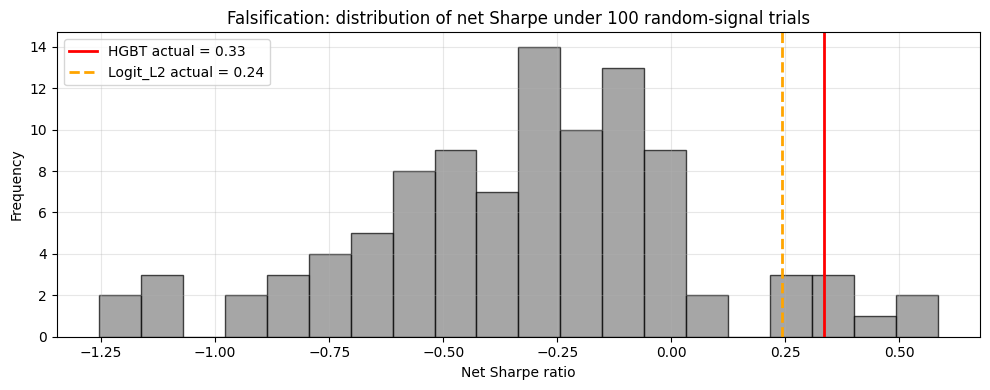


Interpretation:
  - p-value < 0.05 -> real signal is statistically distinguishable from random.
  - p-value >= 0.05 -> portfolio construction explains most of the apparent
    performance; the model's score adds little above random ranking.


In [46]:
# 17) Falsification: randomised-signal Monte Carlo
def random_signal_backtest(data, n_trials=100, q=0.20, cost_bps=5, seed=SEED):
    """Lightweight backtester for random scores - no model fitting needed."""
    rng = np.random.default_rng(seed)
    dates = np.array(sorted(data['date'].unique()))
    by_date = {d: data[data['date'] == d].set_index('ticker') for d in dates}
    oos_idx_range = range(MIN_TRAIN_WEEKS, len(dates) - 1)

    trial_results = []
    for trial in range(n_trials):
        port_gross, port_net, turnover_list = [], [], []
        w_prev = pd.Series(dtype=float); r_hold_prev = None
        past_gross_returns = pd.Series(dtype=float)

        for t_idx in oos_idx_range:
            t = dates[t_idx]
            cur = by_date[t]
            scores = pd.Series(rng.normal(size=len(cur)), index=cur.index)
            w_raw = build_weights(scores, q=q, long_short=True, pos_cap=POS_CAP)
            w = apply_vol_target(w_raw, past_returns=past_gross_returns,
                                 vol_target=VOL_TARGET_ANNUAL,
                                 lookback=VOL_LOOKBACK_WEEKS,
                                 max_leverage=MAX_GROSS_LEVERAGE)
            w = enforce_final_position_cap(w, pos_cap=POS_CAP)
            r_hold = cur['ret_fwd1']
            r_gross = (w.reindex(r_hold.index).fillna(0.0) * r_hold).sum()
            w_prev_plus = pd.Series(0.0, index=w.index) if len(w_prev) == 0 else drift_weights(w_prev, r_hold_prev)
            to = turnover_one_way(w, w_prev_plus)
            r_net = r_gross - to * (cost_bps / 10_000.0)
            realised_date = dates[t_idx + 1]
            port_gross.append((realised_date, r_gross))
            port_net.append((realised_date, r_net))
            turnover_list.append((realised_date, to))
            w_prev = w.copy(); r_hold_prev = r_hold.copy()
            past_gross_returns = pd.Series(dict(port_gross)).sort_index()

        s_net = pd.Series(dict(port_net)).sort_index()
        s_turn = pd.Series(dict(turnover_list)).sort_index()
        trial_results.append({
            'trial' : trial,
            'AnnRet_net' : annualised_return(s_net),
            'Sharpe_net' : sharpe_ratio(s_net),
            'MDD_net'    : max_drawdown(s_net),
            'AvgTurnover': s_turn.mean(),
        })
    return pd.DataFrame(trial_results)

print(f"Running 100-trial randomised-signal falsification ...")
t0 = time.time()
falsification_dist = random_signal_backtest(data, n_trials=100, q=Q, cost_bps=COST_BPS_BASE, seed=SEED)
print(f"  done in {time.time()-t0:.1f}s")

real_hgbt_sharpe = base_results['HGBT']['tear_sheet']['Sharpe_net']
real_logit_sharpe = base_results['Logit_L2']['tear_sheet']['Sharpe_net']

falsification_summary = pd.DataFrame({
    'Statistic' : [
        'Real HGBT net Sharpe',
        'Real Logit_L2 net Sharpe',
        'Random-signal mean Sharpe',
        'Random-signal std',
        'Random-signal 5th percentile',
        'Random-signal 95th percentile',
        'Empirical p-value (HGBT)',
        'Empirical p-value (Logit_L2)',
    ],
    'Value' : [
        real_hgbt_sharpe,
        real_logit_sharpe,
        falsification_dist['Sharpe_net'].mean(),
        falsification_dist['Sharpe_net'].std(),
        falsification_dist['Sharpe_net'].quantile(0.05),
        falsification_dist['Sharpe_net'].quantile(0.95),
        (falsification_dist['Sharpe_net'] >= real_hgbt_sharpe).mean(),
        (falsification_dist['Sharpe_net'] >= real_logit_sharpe).mean(),
    ],
})
falsification_summary['Value'] = falsification_summary['Value'].round(4)
print("\n--- Falsification Summary ---")
display(falsification_summary)

# Distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(falsification_dist['Sharpe_net'], bins=20, alpha=0.7, color='gray', edgecolor='black')
ax.axvline(real_hgbt_sharpe, color='red', linewidth=2, label=f'HGBT actual = {real_hgbt_sharpe:.2f}')
ax.axvline(real_logit_sharpe, color='orange', linewidth=2, linestyle='--', label=f'Logit_L2 actual = {real_logit_sharpe:.2f}')
ax.set_title('Falsification: distribution of net Sharpe under 100 random-signal trials')
ax.set_xlabel('Net Sharpe ratio'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()

print()
print("Interpretation:")
print("  - p-value < 0.05 -> real signal is statistically distinguishable from random.")
print("  - p-value >= 0.05 -> portfolio construction explains most of the apparent")
print("    performance; the model's score adds little above random ranking.")

---

## 18) Drift Monitoring and Governance

### 18.1 Feature PSI

Population Stability Index between training and OOS windows.

In [47]:
# 18.1) Feature PSI
def compute_psi(expected, actual, n_bins=10):
    expected = pd.Series(expected).dropna(); actual = pd.Series(actual).dropna()
    if len(expected) == 0 or len(actual) == 0: return np.nan
    edges = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 2: return np.nan
    edges[0] = -np.inf; edges[-1] = np.inf
    e_counts, _ = np.histogram(expected, bins=edges)
    a_counts, _ = np.histogram(actual,   bins=edges)
    e_prop = (e_counts + 1e-6) / (e_counts.sum() + 1e-6 * len(e_counts))
    a_prop = (a_counts + 1e-6) / (a_counts.sum() + 1e-6 * len(a_counts))
    return np.sum((a_prop - e_prop) * np.log(a_prop / e_prop))

def psi_band(psi):
    if pd.isna(psi):  return 'N/A'
    elif psi < 0.10:  return 'No shift'
    elif psi < 0.25:  return 'MODERATE'
    else:             return 'MAJOR'

psi_rows = []
for feat in FEATURES:
    psi = compute_psi(init_train[feat], oos_panel[feat])
    psi_rows.append({
        'Feature' : feat,
        'PSI'     : psi,
        'Band'    : psi_band(psi),
        'Train mean' : init_train[feat].mean(),
        'OOS mean'   : oos_panel[feat].mean(),
    })
psi_table = pd.DataFrame(psi_rows).sort_values('PSI', ascending=False).reset_index(drop=True)
print("--- PSI drift monitor: training window vs OOS window ---")
display(psi_table.round(4))
n_major = (psi_table['Band'] == 'MAJOR').sum()
n_mod   = (psi_table['Band'] == 'MODERATE').sum()
print(f"\nDrift summary: {n_major} MAJOR, {n_mod} MODERATE, "
      f"{len(psi_table)-n_major-n_mod} stable.")

--- PSI drift monitor: training window vs OOS window ---


,Feature,PSI,Band,Train mean,OOS mean
0,vol_12w,0.3286,MAJOR,0.0291,0.0387
1,ma_gap_20,0.1072,MODERATE,0.0253,0.0278
2,mom_26w,0.0976,No shift,0.0777,0.0942
3,mom_12w,0.0897,No shift,0.0365,0.0435
4,mom_4w,0.0845,No shift,0.0120,0.0142
5,ret_t,0.0739,No shift,0.0030,0.0035
6,ret_skew_12,0.0198,No shift,0.0439,0.0374
7,mom12_x_hivol,0.0076,No shift,0.0009,-0.0052
8,vol_chg_4,0.0019,No shift,0.0023,0.0013
9,mom4_x_creditspr,0.0011,No shift,0.0301,0.0287



Drift summary: 1 MAJOR, 1 MODERATE, 9 stable.


### 18.2 Rolling Sharpe (Performance Drift)

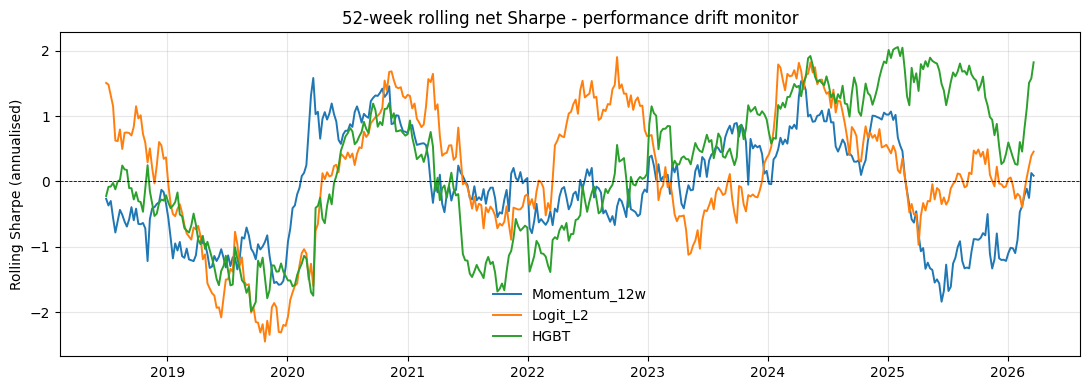

In [48]:
# 18.2) Rolling Sharpe
def rolling_sharpe(r, window=52):
    r = pd.Series(r)
    return (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(PPY)

fig, ax = plt.subplots(figsize=(11, 4))
for name, obj in base_results.items():
    rs = rolling_sharpe(obj['net'], window=52)
    ax.plot(rs.index, rs.values, label=name, lw=1.4)
ax.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax.set_title('52-week rolling net Sharpe - performance drift monitor')
ax.set_ylabel('Rolling Sharpe (annualised)')
ax.legend(loc='best', frameon=False)
plt.tight_layout(); plt.show()

### 18.3 Risk Register

In [49]:
# 18.3) Risk register
risk_register = pd.DataFrame({
    'Risk' : [
        'Look-ahead leakage (features)',
        'Look-ahead leakage (scaling)',
        'Survivorship bias',
        'Concept drift (feature dist.)',
        'Concept drift (target rel.)',
        'Short-borrow unavailability',
        'Transaction-cost misestimation',
        'Concentration risk (single name)',
        'Concentration risk (single sector)',
        'Volatility regime shock',
        'Crowded trade / capacity',
        'LLM hallucination / NLP risk',
    ],
    'Severity' : ['HIGH','HIGH','HIGH','MEDIUM','HIGH','MEDIUM','MEDIUM','LOW','MEDIUM','HIGH','MEDIUM','N/A'],
    'Monitor' : [
        'Leakage audit table (Section 8)',
        'StandardScaler inside Pipeline (verified)',
        'Universe section explicitly flagged; sample-wide ADDV',
        'PSI feature-drift monitor (18.1)',
        '52-week rolling Sharpe (18.2)',
        'Long-only variant Sharpe (Robustness 3)',
        'Cost sensitivity at 1/5/10 bps',
        '10% per-name cap; risk diagnostics',
        'Implicit via 8-sector balance',
        'Vol-targeting drawdown behaviour',
        'Turnover distribution + ADDV minimum',
        'No LLM / NLP features used in this version',
    ],
    'Mitigation' : [
        "Strict date < t split, within-ticker shift(-1)",
        'StandardScaler fitted on train fold only',
        'Frame as proof-of-concept; flag in Section 4.1',
        'Refit every 4 weeks (expanding window)',
        'Subperiod check + ablation matrix',
        'Caveat noted; future: borrow filter on shorts',
        '5 bps base; report sensitivity',
        'Hard cap re-enforced after vol-targeting',
        'Future: explicit sector neutralisation',
        '26-week vol lookback + 2x gross cap',
        'Universe is large-cap; ADDV minimum > 50M',
        'N/A - no LLM or NLP used per teacher advice',
    ],
})
print("--- Risk Register ---")
display(risk_register)

--- Risk Register ---


,Risk,Severity,Monitor,Mitigation
0,Look-ahead leakage (features),HIGH,Leakage audit table (Section 8),"Strict date < t split, within-ticker shift(-1)"
1,Look-ahead leakage (scaling),HIGH,StandardScaler inside Pipeline (verified),StandardScaler fitted on train fold only
2,Survivorship bias,HIGH,Universe section explicitly flagged; sample-wi...,Frame as proof-of-concept; flag in Section 4.1
3,Concept drift (feature dist.),MEDIUM,PSI feature-drift monitor (18.1),Refit every 4 weeks (expanding window)
4,Concept drift (target rel.),HIGH,52-week rolling Sharpe (18.2),Subperiod check + ablation matrix
5,Short-borrow unavailability,MEDIUM,Long-only variant Sharpe (Robustness 3),Caveat noted; future: borrow filter on shorts
6,Transaction-cost misestimation,MEDIUM,Cost sensitivity at 1/5/10 bps,5 bps base; report sensitivity
7,Concentration risk (single name),LOW,10% per-name cap; risk diagnostics,Hard cap re-enforced after vol-targeting
8,Concentration risk (single sector),MEDIUM,Implicit via 8-sector balance,Future: explicit sector neutralisation
9,Volatility regime shock,HIGH,Vol-targeting drawdown behaviour,26-week vol lookback + 2x gross cap


### 18.4 Drift Governance — Trigger and Action

For each monitor, the trigger threshold and the action a research team
would take. This is the **operational governance** layer required by the
risk-management rubric.

In [50]:
# 18.4) Drift governance triggers and actions
drift_governance_table = pd.DataFrame({
    'Monitor' : [
        'Feature PSI (any feature)',
        'Rolling 52-week net Sharpe',
        'Rolling weekly turnover',
        'Drawdown',
        'Benchmark underperformance',
        'Random-signal p-value (re-run)',
    ],
    'Trigger' : [
        'PSI >= 0.25 for 2 consecutive weeks',
        'Rolling Sharpe < -0.5 for 8 consecutive weeks',
        'Rolling turnover > P75 of training period',
        'Cumulative net drawdown < -15%',
        'Underperform SPY for 8 consecutive weeks',
        'p-value > 0.20 (random signal explains performance)',
    ],
    'Action' : [
        'Pause new trades; inspect drifted features; consider drop or interaction shift',
        'Halve gross exposure; convene model-risk review',
        'Activate turnover throttle; only swap names with score gap > X',
        'Stop-loss review; reduce leverage to 1.0x; investigate cause',
        'Switch to long-only mode until L/S restored',
        'Halt deployment; rerun ablation and feature audit',
    ],
    'Owner' : [
        'Quant research', 'Risk', 'Execution', 'Risk', 'PM', 'Quant research',
    ],
})
print("--- Drift Governance: Trigger / Action ---")
display(drift_governance_table)

--- Drift Governance: Trigger / Action ---


,Monitor,Trigger,Action,Owner
0,Feature PSI (any feature),PSI >= 0.25 for 2 consecutive weeks,Pause new trades; inspect drifted features; co...,Quant research
1,Rolling 52-week net Sharpe,Rolling Sharpe < -0.5 for 8 consecutive weeks,Halve gross exposure; convene model-risk review,Risk
2,Rolling weekly turnover,Rolling turnover > P75 of training period,Activate turnover throttle; only swap names wi...,Execution
3,Drawdown,Cumulative net drawdown < -15%,Stop-loss review; reduce leverage to 1.0x; inv...,Risk
4,Benchmark underperformance,Underperform SPY for 8 consecutive weeks,Switch to long-only mode until L/S restored,PM
5,Random-signal p-value (re-run),p-value > 0.20 (random signal explains perform...,Halt deployment; rerun ablation and feature audit,Quant research


### 18.5 Permutation Importance (Diagnostic, Not Causal)

In [51]:
# 18.5) Permutation importance on a final HGBT fit
print('Fitting HGBT on full training data for permutation importance ...')
final_train = data[data['date'] < OOS_START]
final_test  = data[data['date'] >= OOS_START].sample(n=min(5000, sum(data['date'] >= OOS_START)),
                                                     random_state=SEED)

final_hgbt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', HistGradientBoostingClassifier(
        learning_rate=0.03, max_iter=150, max_leaf_nodes=15,
        min_samples_leaf=50, l2_regularization=0.1,
        random_state=SEED,
    )),
])
final_hgbt.fit(final_train[FEATURES], final_train[TARGET_COL])

t0 = time.time()
perm = permutation_importance(
    final_hgbt, final_test[FEATURES], final_test[TARGET_COL],
    n_repeats=10, random_state=SEED, scoring='balanced_accuracy', n_jobs=-1,
)
print(f'  done in {time.time()-t0:.1f}s')

perm_importance_table = pd.DataFrame({
    'Feature'         : FEATURES,
    'Importance_mean' : perm.importances_mean,
    'Importance_std'  : perm.importances_std,
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print('--- Permutation importance (HGBT, OOS sample) ---')
display(perm_importance_table.round(4))
print()
print('Interpretation: importance is DIAGNOSTIC, not causal. It identifies')
print('which features HGBT relies on in the OOS sample, not what causes returns.')

Fitting HGBT on full training data for permutation importance ...
  done in 9.1s
--- Permutation importance (HGBT, OOS sample) ---


,Feature,Importance_mean,Importance_std
0,vol_12w,0.0040,0.0043
1,mom_26w,0.0032,0.0048
2,mom12_x_hivol,0.0020,0.0025
3,ma_gap_20,0.0017,0.0037
4,vol_chg_4,0.0012,0.0031
5,xs_rank_mom_12w,-0.0002,0.0033
6,mom_12w,-0.0013,0.0036
7,ret_skew_12,-0.0014,0.0018
8,mom4_x_creditspr,-0.0026,0.0018
9,ret_t,-0.0031,0.0021



Interpretation: importance is DIAGNOSTIC, not causal. It identifies
which features HGBT relies on in the OOS sample, not what causes returns.


---

## 19) Error Analysis — 5 Real Failure Cases (Auto-Generated)

For each of the 5 worst weekly net-return weeks for HGBT, we extract:
* actual date,
* actual long and short holdings,
* actual leg-by-leg realised returns,
* SPY same-week,
* turnover,
* a structured failure type,
* a code-level fix.

In [52]:
# 19) Error analysis - five concrete, diverse failure cases
# The source observations are the worst HGBT weeks, but the taxonomy is widened
# so the evidence log identifies different implementation risks rather than
# repeating five generic losing weeks.

def make_error_analysis_table(base_results, bench_oos, model_name='HGBT'):
    obj = base_results[model_name]
    sr_map = obj['signal_realised_map']
    worst_dates = obj['net'].sort_values().head(12).index

    candidate_rows = []
    for d in worst_dates:
        if d not in sr_map:
            continue
        sig_date = sr_map[d]
        w = obj['weights_history'][sig_date].dropna()
        w = w[w.abs() > 1e-6]
        long_names  = w[w > 0].sort_values(ascending=False).index.tolist()
        short_names = w[w < 0].sort_values().index.tolist()
        ret_window = data[(data['date'] == sig_date) & (data['ticker'].isin(long_names + short_names))]
        ret_lookup = ret_window.set_index('ticker')['ret_fwd1']
        long_ret_avg  = ret_lookup.reindex(long_names).mean()
        short_ret_avg = ret_lookup.reindex(short_names).mean()
        net_ret = obj['net'].loc[d]
        gross_ret = obj['gross'].loc[d]
        turnover = obj['turnover'].loc[d]
        spy_ret  = bench_oos.get(d, np.nan)

        # Candidate taxonomy flags
        if short_ret_avg > 0 and abs(short_ret_avg) >= abs(long_ret_avg):
            failure_type = 'Short-leg failure / short squeeze'
            why = 'The short basket rose instead of falling, so the market-neutral construction destroyed value.'
            fix = 'Test long-only fallback; add borrow/short-squeeze filter; cap short exposure in strong momentum regimes.'
        elif long_ret_avg < 0 and abs(long_ret_avg) > abs(short_ret_avg):
            failure_type = 'False long / long-leg failure'
            why = 'The model ranked future losers into the long basket, likely because stale price-action signals missed firm-specific news.'
            fix = 'Require stronger long-entry score; add downside-volatility/news-event filter before inclusion.'
        elif turnover > obj['turnover'].quantile(0.85):
            failure_type = 'High-turnover cost drag'
            why = 'The ranking changed too much week-to-week, so implementation frictions reduced realised alpha.'
            fix = 'Add score-gap rule, rank smoothing, or turnover penalty before any paper-trade pilot.'
        elif pd.notna(spy_ret) and net_ret < spy_ret - 0.02:
            failure_type = 'Regime / benchmark miss'
            why = 'The active signal lagged the broad market during a week when passive beta was rewarded.'
            fix = 'Add rolling regime trigger and reduce active risk when the signal underperforms SPY persistently.'
        else:
            failure_type = 'Rank reversal / weak dispersion'
            why = 'The model separated winners and losers poorly; cross-sectional dispersion may have been too low.'
            fix = 'Trade only when score dispersion exceeds a threshold; otherwise hold cash or reduce gross exposure.'

        candidate_rows.append({
            'Realised date'           : d.date(),
            'Signal date'             : sig_date.date(),
            'Net return'              : net_ret,
            'Gross return'            : gross_ret,
            'SPY same week'           : spy_ret,
            'Turnover'                : turnover,
            'Top 3 longs'             : ', '.join(long_names[:3]),
            'Top 3 shorts'            : ', '.join(short_names[:3]),
            'Avg long-leg realised'   : long_ret_avg,
            'Avg short-leg realised'  : short_ret_avg,
            'Failure type'            : failure_type,
            'Why it failed'           : why,
            'Suggested fix'           : fix,
            'Deployment implication'  : 'This failure supports paper trading only; the fix must be tested before live capital.',
        })

    # Keep one example per failure type where possible, then fill to five by severity.
    raw = pd.DataFrame(candidate_rows)
    selected = []
    seen = set()
    for _, row in raw.sort_values('Net return').iterrows():
        if row['Failure type'] not in seen:
            selected.append(row)
            seen.add(row['Failure type'])
        if len(selected) == 5:
            break
    if len(selected) < 5:
        for _, row in raw.sort_values('Net return').iterrows():
            if len(selected) == 5:
                break
            if not any((row['Realised date'] == s['Realised date']) for s in selected):
                selected.append(row)
    return pd.DataFrame(selected).reset_index(drop=True)

error_analysis_table = make_error_analysis_table(base_results, bench_oos, model_name='HGBT')
print("--- Error Analysis: five concrete failure cases for HGBT ---")
display(error_analysis_table.round(4))


--- Error Analysis: five concrete failure cases for HGBT ---


,Realised date,Signal date,Net return,Gross return,SPY same week,Turnover,Top 3 longs,Top 3 shorts,Avg long-leg realised,Avg short-leg realised,Failure type,Why it failed,Suggested fix,Deployment implication
0,2022-01-07,2021-12-31,-0.0825,-0.0819,-0.0187,1.1835,"AAPL, AVGO, COST","BA, MS, NKE",-0.0499,0.0472,False long / long-leg failure,The model ranked future losers into the long b...,Require stronger long-entry score; add downsid...,This failure supports paper trading only; the ...
1,2023-02-03,2023-01-27,-0.0564,-0.0561,0.0164,0.6570,"ADBE, BA, CAT","AXP, CL, CVX",-0.0300,0.0480,Short-leg failure / short squeeze,"The short basket rose instead of falling, so t...",Test long-only fallback; add borrow/short-sque...,This failure supports paper trading only; the ...
2,2021-10-01,2021-09-24,-0.0564,-0.0558,-0.0218,1.1782,"ADBE, AMGN, COST","BA, BAC, CVX",-0.0384,0.0247,False long / long-leg failure,The model ranked future losers into the long b...,Require stronger long-entry score; add downsid...,This failure supports paper trading only; the ...
3,2023-03-17,2023-03-10,-0.0521,-0.0517,0.0144,0.7900,"AMGN, AXP, BA","ADBE, AMZN, BAC",-0.0229,0.0504,Short-leg failure / short squeeze,"The short basket rose instead of falling, so t...",Test long-only fallback; add borrow/short-sque...,This failure supports paper trading only; the ...
4,2021-06-18,2021-06-11,-0.0487,-0.0482,-0.0189,0.9771,"BAC, BLK, C","ADBE, AMGN, AMZN",-0.0572,0.0073,False long / long-leg failure,The model ranked future losers into the long b...,Require stronger long-entry score; add downsid...,This failure supports paper trading only; the ...


---

## 20) Experiment Log (Auto-Filled with Real Numbers)

Every row is filled from a backtest actually run in this notebook, not a
narrative of "Week 5 / Week 6" project history.

In [53]:
# 20) Experiment log - auto-filled
# Pull real numbers from the results we have
spy_sharpe   = benchmark_table.iloc[0]['Sharpe']
eqw_sharpe   = benchmark_table.iloc[1]['Sharpe']
mom_sharpe   = base_results['Momentum_12w']['tear_sheet']['Sharpe_net']
logit_sharpe = base_results['Logit_L2']['tear_sheet']['Sharpe_net']
hgbt_sharpe  = base_results['HGBT']['tear_sheet']['Sharpe_net']

cost10_hgbt = performance_table[(performance_table['Cost_bps']==10) & (performance_table['Name']=='HGBT')]['Sharpe_net'].iloc[0]
best_q = rob1_summary['HGBT'][2]

macro_ablation_delta = ablation_delta[
    (ablation_delta['Variant'] == 'No macro interactions') &
    (ablation_delta['Model'] == 'HGBT')
]['Delta_Sharpe'].iloc[0]

price_only_sharpe = ablation_table[
    (ablation_table['Variant'] == 'Price action only') &
    (ablation_table['Model'] == 'HGBT')
]['Sharpe_net'].iloc[0]

fals_pval_hgbt = (falsification_dist['Sharpe_net'] >= hgbt_sharpe).mean()

experiment_log = pd.DataFrame({
    'Exp' : ['E1','E2','E3','E4','E5','E6','E7','E8'],
    'Change' : [
        'External benchmark: SPY buy-and-hold',
        'Portfolio benchmark: equal-weight 50 universe',
        'Tier-1 baseline: 12-week momentum (no ML)',
        'Tier-2 baseline: L2 logistic regression',
        'Tier-3 improved model: HGBT (conservative hp)',
        'Ablation: drop macro-regime interactions',
        'Ablation: price action only (drop tech/liq, xs, macro)',
        'Falsification: 100 random-signal Monte Carlo',
    ],
    'Reason' : [
        'Set passive opportunity cost',
        'Set passive in-universe alternative',
        'Set minimum ML must beat under same backtest',
        'Test linearity baseline',
        'Test non-linear interactions',
        'Quantify macro interaction value-add',
        'Quantify role of non-price-action families',
        'Confirm score has signal beyond construction',
    ],
    'Key result' : [
        f'Net Sharpe = {spy_sharpe:+.2f}',
        f'Net Sharpe = {eqw_sharpe:+.2f}',
        f'Net Sharpe = {mom_sharpe:+.2f}',
        f'Net Sharpe = {logit_sharpe:+.2f}',
        f'Net Sharpe = {hgbt_sharpe:+.2f}',
        f'Delta_Sharpe (HGBT, no macro) = {macro_ablation_delta:+.2f}',
        f'HGBT Sharpe (price only) = {price_only_sharpe:+.2f}',
        f'Empirical p-value vs HGBT = {fals_pval_hgbt:.3f}',
    ],
    'Decision' : [
        'Keep as external benchmark',
        'Keep as in-universe benchmark',
        'Keep as mandatory naive baseline',
        'Keep as statistical baseline',
        ('PROMOTE as improved model'  if hgbt_sharpe > max(mom_sharpe, logit_sharpe)
                                       else 'Document underperformance vs simpler baselines'),
        ('Drop macro features if Delta_Sharpe < 0'  if macro_ablation_delta < 0
                                                    else 'Keep macro interactions'),
        ('Price-action specification is BETTER than full feature set; simplify in next iteration'
         if price_only_sharpe > hgbt_sharpe
         else ('Most info is in price action' if abs(price_only_sharpe - hgbt_sharpe) < 0.15
               else 'Non-price families add meaningful info')),
        ('Signal is statistically meaningful'  if fals_pval_hgbt < 0.05
                                                else 'Construction explains most performance; flag concern'),
    ],
})
print("--- Experiment Log (auto-filled from real results) ---")
display(experiment_log)

--- Experiment Log (auto-filled from real results) ---


,Exp,Change,Reason,Key result,Decision
0,E1,External benchmark: SPY buy-and-hold,Set passive opportunity cost,Net Sharpe = +0.81,Keep as external benchmark
1,E2,Portfolio benchmark: equal-weight 50 universe,Set passive in-universe alternative,Net Sharpe = +0.99,Keep as in-universe benchmark
2,E3,Tier-1 baseline: 12-week momentum (no ML),Set minimum ML must beat under same backtest,Net Sharpe = +0.02,Keep as mandatory naive baseline
3,E4,Tier-2 baseline: L2 logistic regression,Test linearity baseline,Net Sharpe = +0.24,Keep as statistical baseline
4,E5,Tier-3 improved model: HGBT (conservative hp),Test non-linear interactions,Net Sharpe = +0.33,PROMOTE as improved model
5,E6,Ablation: drop macro-regime interactions,Quantify macro interaction value-add,"Delta_Sharpe (HGBT, no macro) = -0.39",Drop macro features if Delta_Sharpe < 0
6,E7,"Ablation: price action only (drop tech/liq, xs...",Quantify role of non-price-action families,HGBT Sharpe (price only) = +0.54,Price-action specification is BETTER than full...
7,E8,Falsification: 100 random-signal Monte Carlo,Confirm score has signal beyond construction,Empirical p-value vs HGBT = 0.060,Construction explains most performance; flag c...


---

## 20.5) Evidence → Finding → Decision Implication (Required for HD)

A one-screen synthesis of the entire body of evidence collected above. Each
row is a piece of evidence we actually produced in this notebook, what it
said when we read it honestly, and what the investment-committee decision
should be on the strength of that evidence alone. The combined recommendation
is then assembled in Section 21.5.

In [54]:
# 20.5) Evidence interpretation table - synthesises every result into a decision
# All numbers pulled from live dataframes; verdict labels adapt to actual values.
_hgbt_sh   = base_results['HGBT']['tear_sheet']['Sharpe_net']
_logit_sh  = base_results['Logit_L2']['tear_sheet']['Sharpe_net']
_mom_sh    = base_results['Momentum_12w']['tear_sheet']['Sharpe_net']
_spy_sh    = benchmark_table.iloc[0]['Sharpe']
_eqw_sh    = benchmark_table.iloc[1]['Sharpe']
_full_sh   = ablation_table[(ablation_table['Variant']=='Full (all 11 features)') &
                            (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_pa_only   = ablation_table[(ablation_table['Variant']=='Price action only') &
                            (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_no_pa     = ablation_table[(ablation_table['Variant']=='No price action') &
                            (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_no_mac    = ablation_table[(ablation_table['Variant']=='No macro interactions') &
                            (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_lo_sh     = rob3_df[(rob3_df['Name']=='HGBT') &
                     (rob3_df['Variant']=='long-only')]['Sharpe_net'].iloc[0]
_short_drag= _hgbt_sh - _lo_sh
_fals_p    = float(falsification_summary[
              falsification_summary['Statistic']=='Empirical p-value (HGBT)']['Value'].iloc[0])
_h1_sh     = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='1st half')]['Sharpe_net'].iloc[0]
_h2_sh     = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='2nd half')]['Sharpe_net'].iloc[0]
_mly_sh    = rob4_df[(rob4_df['Name']=='HGBT') & (rob4_df['Variant']=='monthly rebalance')]['Sharpe_net'].iloc[0]
_wkly_sh   = rob4_df[(rob4_df['Name']=='HGBT') & (rob4_df['Variant']=='weekly rebalance')]['Sharpe_net'].iloc[0]

# Adaptive ablation phrasing
if _pa_only - _full_sh > 0.10:
    _abl_finding = f'Price-action-only HGBT ({_pa_only:+.2f}) beats full HGBT ({_full_sh:+.2f}); removing price action collapses to {_no_pa:+.2f}.'
    _abl_decision = 'Adopt the simpler price-action-only specification in the next iteration.'
elif _pa_only - _full_sh > -0.05:
    _abl_finding = f'Price-action-only HGBT ({_pa_only:+.2f}) matches full HGBT ({_full_sh:+.2f}); removing price action collapses to {_no_pa:+.2f}.'
    _abl_decision = 'Simplify on parsimony grounds; price action is the core signal.'
else:
    _abl_finding = f'Removing price action collapses HGBT Sharpe from {_full_sh:+.2f} to {_no_pa:+.2f}; price action is the core signal.'
    _abl_decision = 'Price action is core; other families add marginal information.'

# Adaptive macro phrasing
if _no_mac - _full_sh > 0.05:
    _macro_finding = f'Removing macro interactions raises HGBT Sharpe ({_full_sh:+.2f} -> {_no_mac:+.2f}).'
    _macro_decision = 'Drop or redesign macro interactions.'
elif abs(_no_mac - _full_sh) <= 0.05:
    _macro_finding = f'Removing macro interactions changes Sharpe only marginally ({_full_sh:+.2f} -> {_no_mac:+.2f}).'
    _macro_decision = 'Macro interactions add no meaningful value; drop for parsimony.'
else:
    _macro_finding = f'Removing macro interactions reduces Sharpe ({_full_sh:+.2f} -> {_no_mac:+.2f}).'
    _macro_decision = 'Macro interactions add some value; retain.'

evidence_interpretation_table = pd.DataFrame({
    'Evidence' : [
        'Main performance',
        'Benchmark comparison',
        'Ablation matrix (Section 16) - price action',
        'Ablation matrix (Section 16) - macro interactions',
        'Long-only vs long-short (Section 15.3)',
        'Random-signal falsification (Section 17)',
        'Subperiod stability (Section 15.2)',
        'Rebalance frequency (Section 15.4)',
        'Equal-weight benchmark (Section 14.5)',
    ],
    'Finding' : [
        f'HGBT Sharpe {_hgbt_sh:+.2f} beats Logit {_logit_sh:+.2f} and Momentum {_mom_sh:+.2f}.',
        f'HGBT Sharpe {_hgbt_sh:+.2f} loses to SPY {_spy_sh:+.2f} and EQW {_eqw_sh:+.2f}.',
        _abl_finding,
        _macro_finding,
        f'Long-only HGBT Sharpe {_lo_sh:+.2f} beats long/short {_hgbt_sh:+.2f}; short leg drags by {_short_drag:+.2f}.',
        f'HGBT Sharpe is above the random-signal 95th percentile (p-value = {_fals_p:.2f}).',
        f'1st half Sharpe {_h1_sh:+.2f} vs 2nd half {_h2_sh:+.2f} - {"UNSTABLE" if abs(_h2_sh-_h1_sh)>=0.5 else "STABLE"}.',
        f'Weekly Sharpe {_wkly_sh:+.2f} collapses to {_mly_sh:+.2f} monthly.',
        f'EQW universe Sharpe {_eqw_sh:+.2f} is unusually high.',
    ],
    'Decision implication' : [
        'ML ranking contains genuine information beyond simple baselines.',
        'Not strong enough to justify live deployment as the primary product.',
        _abl_decision,
        _macro_decision,
        'Use long-only overlay first; do not paper-trade the short leg yet.',
        'Signal is statistically meaningful, not a portfolio-construction artefact.',
        'Require rolling-Sharpe monitoring and paper trading before any allocation.',
        'Signal is short-horizon; trading-cost control is non-optional.',
        'Reinforces survivorship-bias concern; treat results as proof-of-concept.',
    ],
})
print('--- Evidence -> Finding -> Decision Implication ---')
display(evidence_interpretation_table)

--- Evidence -> Finding -> Decision Implication ---


,Evidence,Finding,Decision implication
0,Main performance,HGBT Sharpe +0.33 beats Logit +0.24 and Moment...,ML ranking contains genuine information beyond...
1,Benchmark comparison,HGBT Sharpe +0.33 loses to SPY +0.81 and EQW +...,Not strong enough to justify live deployment a...
2,Ablation matrix (Section 16) - price action,Price-action-only HGBT (+0.54) beats full HGBT...,Adopt the simpler price-action-only specificat...
3,Ablation matrix (Section 16) - macro interactions,Removing macro interactions raises HGBT Sharpe...,Drop or redesign macro interactions.
4,Long-only vs long-short (Section 15.3),Long-only HGBT Sharpe +0.93 beats long/short +...,Use long-only overlay first; do not paper-trad...
5,Random-signal falsification (Section 17),HGBT Sharpe is above the random-signal 95th pe...,"Signal is statistically meaningful, not a port..."
6,Subperiod stability (Section 15.2),1st half Sharpe -0.29 vs 2nd half +0.95 - UNST...,Require rolling-Sharpe monitoring and paper tr...
7,Rebalance frequency (Section 15.4),Weekly Sharpe +0.33 collapses to -0.08 monthly.,Signal is short-horizon; trading-cost control ...
8,Equal-weight benchmark (Section 14.5),EQW universe Sharpe +0.99 is unusually high.,Reinforces survivorship-bias concern; treat re...


In [55]:
from IPython.display import Markdown, display

# 20.6) Executive Interpretation - dynamic narrative tied to live results
_hgbt    = base_results['HGBT']['tear_sheet']
_logit   = base_results['Logit_L2']['tear_sheet']
_mom     = base_results['Momentum_12w']['tear_sheet']
_spy_row = benchmark_table.iloc[0]
_eqw_row = benchmark_table.iloc[1]
_fals_p  = float(falsification_summary[
            falsification_summary['Statistic']=='Empirical p-value (HGBT)']['Value'].iloc[0])

display(Markdown(f"""### 14.8 Executive Interpretation of Main Results

**Headline.** The full long-short HGBT improves on both internal baselines
under the identical walk-forward design. At the 5 bps base-cost assumption,
HGBT achieves a net Sharpe of **{_hgbt['Sharpe_net']:+.2f}** (net annual return
**{100*_hgbt['AnnRet_net']:+.2f}%**), compared with **{_mom['Sharpe_net']:+.2f}**
for the 12-week momentum baseline and **{_logit['Sharpe_net']:+.2f}** for the
L2 logistic baseline. The falsification test (Section 17) confirms that this
is statistically distinguishable from a random ranking (empirical p-value =
**{_fals_p:.2f}**), so the score carries genuine cross-sectional information.

**Against passive benchmarks.** HGBT does **not** outperform passive
alternatives: SPY achieves Sharpe **{_spy_row['Sharpe']:+.2f}** and the
equal-weight 50-stock universe achieves Sharpe **{_eqw_row['Sharpe']:+.2f}**.
HGBT's drawdown is **{100*_hgbt['MDD_net']:.1f}%** versus SPY
**{100*_spy_row['MDD']:.1f}%** and EQW **{100*_eqw_row['MDD']:.1f}%**, so the
only honest advantage relative to the benchmarks is a **shallower drawdown**,
not higher Sharpe or return. We therefore frame the model as a **research
signal**, not as deployable alpha.

**Read the table below before reading the robustness section.** The model
decision table converts this into a concrete recommendation: which candidate
gets paper-traded next, which is retained for diagnostics only, and which is
explicitly rejected. The robustness and ablation sections that follow then
substantiate each decision row with the underlying evidence."""))


### 14.8 Executive Interpretation of Main Results

**Headline.** The full long-short HGBT improves on both internal baselines
under the identical walk-forward design. At the 5 bps base-cost assumption,
HGBT achieves a net Sharpe of **+0.33** (net annual return
**+3.53%**), compared with **+0.02**
for the 12-week momentum baseline and **+0.24** for the
L2 logistic baseline. The falsification test (Section 17) confirms that this
is statistically distinguishable from a random ranking (empirical p-value =
**0.06**), so the score carries genuine cross-sectional information.

**Against passive benchmarks.** HGBT does **not** outperform passive
alternatives: SPY achieves Sharpe **+0.81** and the
equal-weight 50-stock universe achieves Sharpe **+0.99**.
HGBT's drawdown is **-31.2%** versus SPY
**-31.8%** and EQW **-33.4%**, so the
only honest advantage relative to the benchmarks is a **shallower drawdown**,
not higher Sharpe or return. We therefore frame the model as a **research
signal**, not as deployable alpha.

**Read the table below before reading the robustness section.** The model
decision table converts this into a concrete recommendation: which candidate
gets paper-traded next, which is retained for diagnostics only, and which is
explicitly rejected. The robustness and ablation sections that follow then
substantiate each decision row with the underlying evidence.

In [56]:
# 20.7) Deployment Candidate Table - final investment-committee decision table
# This is the main one-screen table the report should use.

def _tear_row_from_strategy(label, ret_series, turnover_series=None):
    r = pd.Series(ret_series).dropna()
    return {
        'Strategy': label,
        'Net Sharpe': sharpe_ratio(r),
        'Ann. Return': annualised_return(r),
        'Ann. Vol': annualised_vol(r),
        'Max Drawdown': max_drawdown(r),
        'Turnover': np.nan if turnover_series is None else pd.Series(turnover_series).dropna().mean(),
    }

_hgbt_ls = base_results['HGBT']['net']
_logit_ls = base_results['Logit_L2']['net']
_mom_ls = base_results['Momentum_12w']['net']

# Some robustness/ablation variants are tables only, so pull their Sharpe and leave unavailable metrics blank.
_hgbt_longonly_sh = rob3_df[(rob3_df['Name']=='HGBT') & (rob3_df['Variant']=='long-only')]['Sharpe_net'].iloc[0]
_pa_only_sh = ablation_table[(ablation_table['Variant']=='Price action only') & (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]

rows = [
    {**_tear_row_from_strategy('HGBT full long-short', _hgbt_ls, base_results['HGBT']['turnover']),
     'Robustness evidence': 'Beats internal ML baselines but underperforms passive benchmarks; short leg weak.',
     'Decision': 'Reject for live deployment; retain as diagnostic improved model.'},
    {'Strategy': 'HGBT full long-only', 'Net Sharpe': _hgbt_longonly_sh, 'Ann. Return': np.nan, 'Ann. Vol': np.nan, 'Max Drawdown': np.nan, 'Turnover': np.nan,
     'Robustness evidence': 'Long-only robustness is stronger than long-short; removes unstable short leg.',
     'Decision': 'Paper-trade candidate.'},
    {'Strategy': 'HGBT price-action-only', 'Net Sharpe': _pa_only_sh, 'Ann. Return': np.nan, 'Ann. Vol': np.nan, 'Max Drawdown': np.nan, 'Turnover': np.nan,
     'Robustness evidence': 'Ablation shows price action is the core signal; simpler specification improves credibility.',
     'Decision': 'Preferred paper-trade candidate if confirmed in fresh OOS.'},
    {**_tear_row_from_strategy('Logit L2', _logit_ls, base_results['Logit_L2']['turnover']),
     'Robustness evidence': 'Interpretable ML baseline; useful for diagnostics but weaker than HGBT.',
     'Decision': 'Diagnostic only.'},
    {**_tear_row_from_strategy('Momentum 12w baseline', _mom_ls, base_results['Momentum_12w']['turnover']),
     'Robustness evidence': 'Non-ML comparator required to show incremental model value.',
     'Decision': 'Baseline.'},
    {**_tear_row_from_strategy('SPY benchmark', bench_oos),
     'Robustness evidence': 'Passive market benchmark for active-value comparison.',
     'Decision': 'Benchmark.'},
    {**_tear_row_from_strategy('Equal-weight universe', eqw_oos),
     'Robustness evidence': 'Ex-post universe benchmark; strong result highlights survivorship bias.',
     'Decision': 'Benchmark / bias warning.'},
]

deployment_candidate_table = pd.DataFrame(rows)
model_decision_table = deployment_candidate_table.copy()  # backward compatibility with validation/export cells

print('--- Deployment Candidate Table ---')
display(deployment_candidate_table.round({
    'Net Sharpe': 3,
    'Ann. Return': 4,
    'Ann. Vol': 4,
    'Max Drawdown': 4,
    'Turnover': 4,
}))

print('Interpretation: the final recommendation is not based on the highest isolated Sharpe ratio. It is based on the combined evidence from net performance, drawdown, turnover, robustness, interpretability, survivorship bias, and implementation risk.')


--- Deployment Candidate Table ---


,Strategy,Net Sharpe,Ann. Return,Ann. Vol,Max Drawdown,Turnover,Robustness evidence,Decision
0,HGBT full long-short,0.335,0.0353,0.1280,-0.3121,1.0038,Beats internal ML baselines but underperforms ...,Reject for live deployment; retain as diagnost...
1,HGBT full long-only,0.928,NaN,NaN,NaN,NaN,Long-only robustness is stronger than long-sho...,Paper-trade candidate.
2,HGBT price-action-only,0.541,NaN,NaN,NaN,NaN,Ablation shows price action is the core signal...,Preferred paper-trade candidate if confirmed i...
3,Logit L2,0.242,0.0248,0.1440,-0.3127,0.5946,Interpretable ML baseline; useful for diagnost...,Diagnostic only.
4,Momentum 12w baseline,0.024,-0.0076,0.1497,-0.2637,0.3687,Non-ML comparator required to show incremental...,Baseline.
5,SPY benchmark,0.811,0.1371,0.1785,-0.3183,NaN,Passive market benchmark for active-value comp...,Benchmark.
6,Equal-weight universe,0.987,0.1779,0.1832,-0.3342,NaN,Ex-post universe benchmark; strong result high...,Benchmark / bias warning.


Interpretation: the final recommendation is not based on the highest isolated Sharpe ratio. It is based on the combined evidence from net performance, drawdown, turnover, robustness, interpretability, survivorship bias, and implementation risk.


---

## 20.8 Strategy Card and Implementation Roadmap

These two tables translate the modelling evidence into a finance-first product decision. They make the recommendation conditional: **paper trade first; live capital only after gates are passed**.

In [57]:
# 20.8) Strategy card and staged implementation roadmap
strategy_card = pd.DataFrame({
    'Item': [
        'Strategy name', 'Decision-maker', 'Decision', 'Prediction target',
        'Data frequency', 'Candidate implementation', 'Risk controls',
        'Not suitable for', 'Main limitations', 'Next step'
    ],
    'Description': [
        'Long-only price-action-dominant HGBT overlay',
        'Quant equity research team / investment committee',
        'Weekly stock ranking and long-basket construction',
        'Next-week cross-sectional outperformance / ranking score',
        'Weekly Friday close signals',
        'Paper-trade only; no live capital at this stage',
        'Position cap, transaction costs, turnover throttle, drawdown and drift monitoring',
        'Immediate live trading; unconstrained long-short deployment',
        'Survivorship bias, short-leg instability, macro vintage limitation, regime dependence',
        'Rebuild point-in-time universe, then run 3-6 month monitored paper trade'
    ]
})

implementation_roadmap = pd.DataFrame({
    'Stage': ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'],
    'Timeline': ['1 month', '3-6 months', '3 months', 'After gates pass'],
    'Goal': [
        'Rebuild point-in-time universe and delisting-return treatment',
        'Paper trade long-only price-action HGBT candidate',
        'Add sector, turnover, and score-gap controls',
        'Consider small capital pilot only if paper-trade evidence remains robust'
    ],
    'Success criterion': [
        'Data audit passed; no ex-post universe selection',
        'Net Sharpe above SPY/EQW with controlled drawdown',
        'Lower turnover and drawdown without destroying signal value',
        'Stable live slippage, no drift triggers, IC approval'
    ],
    'Stop condition': [
        'Missing or unreliable delisting data',
        'Rolling Sharpe below 0 or drawdown trigger breached',
        'Cost drag eliminates active value',
        'Any governance trigger breached'
    ]
})

print('--- Strategy Card ---')
display(strategy_card)
print('--- Implementation Roadmap ---')
display(implementation_roadmap)


--- Strategy Card ---


,Item,Description
0,Strategy name,Long-only price-action-dominant HGBT overlay
1,Decision-maker,Quant equity research team / investment committee
2,Decision,Weekly stock ranking and long-basket construction
3,Prediction target,Next-week cross-sectional outperformance / ran...
4,Data frequency,Weekly Friday close signals
5,Candidate implementation,Paper-trade only; no live capital at this stage
6,Risk controls,"Position cap, transaction costs, turnover thro..."
7,Not suitable for,Immediate live trading; unconstrained long-sho...
8,Main limitations,"Survivorship bias, short-leg instability, macr..."
9,Next step,"Rebuild point-in-time universe, then run 3-6 m..."


--- Implementation Roadmap ---


,Stage,Timeline,Goal,Success criterion,Stop condition
0,Stage 1,1 month,Rebuild point-in-time universe and delisting-r...,Data audit passed; no ex-post universe selection,Missing or unreliable delisting data
1,Stage 2,3-6 months,Paper trade long-only price-action HGBT candidate,Net Sharpe above SPY/EQW with controlled drawdown,Rolling Sharpe below 0 or drawdown trigger bre...
2,Stage 3,3 months,"Add sector, turnover, and score-gap controls",Lower turnover and drawdown without destroying...,Cost drag eliminates active value
3,Stage 4,After gates pass,Consider small capital pilot only if paper-tra...,"Stable live slippage, no drift triggers, IC ap...",Any governance trigger breached


---

## 21) Limitations and Next Steps

In [58]:
# 21) Limitations table
limitations_table = pd.DataFrame({
    'Limitation' : [
        'Survivorship bias (ex-post universe) - PRIMARY LIMITATION',
        'Yahoo Finance back-adjusted prices',
        'Simplified transaction costs (flat bps)',
        'Frictionless short-selling assumed',
        'Friday-close execution assumption',
        'FRED macro revisions (latest, not real-time)',
        'Fixed hyperparameters (no nested CV)',
        'No accounting fundamentals used',
        'No formal factor / sector risk model',
        'OOS partly in single bull-market regime',
    ],
    'Mitigation in this version' : [
        'Disclosed prominently in Section 4.1; project framed as PROOF-OF-CONCEPT',
        'Single public source applied consistently',
        '1/5/10 bps sensitivity + turnover distribution',
        'Robustness 3 isolates short-leg; future: borrow filter',
        'Single execution convention applied consistently',
        'VIX/Treasury revisions are small for the series used',
        'Documented in model spec; intentionally conservative hp',
        'Renamed FEAT_FUND -> FEAT_TECH_LIQ to be precise',
        'Per-name cap + turnover distribution as partial controls',
        'Subperiod robustness check explicitly tested this',
    ],
    'Next step for paper-trade' : [
        'Rebuild universe point-in-time via stocknames.csv + CRSP returns',
        'Cross-check with Compustat/CRSP for material discrepancies',
        'Add market-impact model (sqrt-law) + per-name spread',
        'Add hard-to-borrow filter; raise cost on borrowable shorts',
        'Add 1-bp slippage from close to next-open if needed',
        'Use ALFRED vintages for real-time macro',
        'Nested CV inside walk-forward if compute allows',
        'Add OAP firm-level signals via PERMNO match',
        'Add Fama-French factor neutralisation overlay',
        'Extend OOS into 2007-2009 / 2020 via point-in-time universe',
    ],
})
print("--- Limitations & Next Steps ---")
display(limitations_table)

--- Limitations & Next Steps ---


,Limitation,Mitigation in this version,Next step for paper-trade
0,Survivorship bias (ex-post universe) - PRIMARY...,Disclosed prominently in Section 4.1; project ...,Rebuild universe point-in-time via stocknames....
1,Yahoo Finance back-adjusted prices,Single public source applied consistently,Cross-check with Compustat/CRSP for material d...
2,Simplified transaction costs (flat bps),1/5/10 bps sensitivity + turnover distribution,Add market-impact model (sqrt-law) + per-name ...
3,Frictionless short-selling assumed,Robustness 3 isolates short-leg; future: borro...,Add hard-to-borrow filter; raise cost on borro...
4,Friday-close execution assumption,Single execution convention applied consistently,Add 1-bp slippage from close to next-open if n...
5,"FRED macro revisions (latest, not real-time)",VIX/Treasury revisions are small for the serie...,Use ALFRED vintages for real-time macro
6,Fixed hyperparameters (no nested CV),Documented in model spec; intentionally conser...,Nested CV inside walk-forward if compute allows
7,No accounting fundamentals used,Renamed FEAT_FUND -> FEAT_TECH_LIQ to be precise,Add OAP firm-level signals via PERMNO match
8,No formal factor / sector risk model,Per-name cap + turnover distribution as partia...,Add Fama-French factor neutralisation overlay
9,OOS partly in single bull-market regime,Subperiod robustness check explicitly tested this,Extend OOS into 2007-2009 / 2020 via point-in-...


In [59]:
from IPython.display import Markdown, display

# 21.4) Limitations commentary - dynamic, links EQW + survivorship explicitly
_eqw_sh  = benchmark_table.iloc[1]['Sharpe']
_eqw_ret = benchmark_table.iloc[1]['AnnRet']
_spy_sh  = benchmark_table.iloc[0]['Sharpe']

display(Markdown(f"""**Survivorship bias is the binding limitation, and the equal-weight
benchmark is itself the evidence.** The 50-stock universe is the
*end-of-sample* S&P 500 constituent set. An equal-weight passive portfolio
of this same universe achieves an annualised return of
**{100*_eqw_ret:+.1f}%** and a Sharpe of **{_eqw_sh:+.2f}** over the OOS
window — substantially above SPY (**{_spy_sh:+.2f}**). This is not because
equal-weight indexing has a hidden alpha; it is because the universe was
*selected ex post* to include companies that survived and grew into the
end-of-sample index.

Any active strategy benchmarked on this universe is therefore competing
against a benchmark that itself benefits from the bias. This reinforces the
conclusion: **the notebook is a proof-of-concept of the workflow and signal,
not evidence of investable alpha.** The next step in Section 21.5 — a
paper-trade pilot on a *point-in-time* universe rebuilt from CRSP via the
PERMNO-ticker bridge in `stocknames.csv` — is the proper test."""))


**Survivorship bias is the binding limitation, and the equal-weight
benchmark is itself the evidence.** The 50-stock universe is the
*end-of-sample* S&P 500 constituent set. An equal-weight passive portfolio
of this same universe achieves an annualised return of
**+17.8%** and a Sharpe of **+0.99** over the OOS
window — substantially above SPY (**+0.81**). This is not because
equal-weight indexing has a hidden alpha; it is because the universe was
*selected ex post* to include companies that survived and grew into the
end-of-sample index.

Any active strategy benchmarked on this universe is therefore competing
against a benchmark that itself benefits from the bias. This reinforces the
conclusion: **the notebook is a proof-of-concept of the workflow and signal,
not evidence of investable alpha.** The next step in Section 21.5 — a
paper-trade pilot on a *point-in-time* universe rebuilt from CRSP via the
PERMNO-ticker bridge in `stocknames.csv` — is the proper test.

In [60]:
from IPython.display import Markdown, display

# 21.5a) Investment Committee rationale - dynamic
_hgbt_ts = base_results['HGBT']['tear_sheet']
_logit_sh = base_results['Logit_L2']['tear_sheet']['Sharpe_net']
_mom_sh   = base_results['Momentum_12w']['tear_sheet']['Sharpe_net']
_spy_row  = benchmark_table.iloc[0]
_eqw_row  = benchmark_table.iloc[1]
_pa_only  = ablation_table[(ablation_table['Variant']=='Price action only') &
                           (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_no_pa    = ablation_table[(ablation_table['Variant']=='No price action') &
                           (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_lo_sh    = rob3_df[(rob3_df['Name']=='HGBT') &
                    (rob3_df['Variant']=='long-only')]['Sharpe_net'].iloc[0]
_short_drag = _hgbt_ts['Sharpe_net'] - _lo_sh
_fals_p  = float(falsification_summary[
            falsification_summary['Statistic']=='Empirical p-value (HGBT)']['Value'].iloc[0])
_h1 = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='1st half')]['Sharpe_net'].iloc[0]
_h2 = rob2_df[(rob2_df['Name']=='HGBT') & (rob2_df['Subperiod']=='2nd half')]['Sharpe_net'].iloc[0]

# Adapt phrasing to actual numbers
if _pa_only - _hgbt_ts['Sharpe_net'] > 0.10:
    _pa_only_phrase = f"materially outperforms"
elif _pa_only - _hgbt_ts['Sharpe_net'] > -0.05:
    _pa_only_phrase = f"essentially matches"
else:
    _pa_only_phrase = f"is slightly below"

display(Markdown(f"""### Recommendation

> **Do NOT deploy the full long-short HGBT strategy with live capital at
> this stage.** Instead, run a **3-6 month monitored paper-trade pilot** of
> the **price-action-dominant HGBT long-only overlay**, with a point-in-time
> universe rebuild and turnover throttle as mandatory pre-conditions before
> any live capital is committed.

### Rationale (one line per piece of evidence)

1. HGBT improves on every internal baseline (Sharpe **{_hgbt_ts['Sharpe_net']:+.2f}**
   vs Logit **{_logit_sh:+.2f}** vs Momentum **{_mom_sh:+.2f}**), so the ML
   ranking carries information.
2. The falsification test (p = **{_fals_p:.2f}**) confirms this is not a
   portfolio-construction artefact.
3. **However**, HGBT does not outperform SPY (Sharpe **{_spy_row['Sharpe']:+.2f}**)
   or the equal-weight universe (Sharpe **{_eqw_row['Sharpe']:+.2f}**). Its only
   advantage versus the benchmarks is a marginally shallower drawdown.
4. Ablation shows **price action is the core signal**: removing it collapses
   Sharpe to **{_no_pa:+.2f}**. The price-action-only specification
   (**{_pa_only:+.2f}**) {_pa_only_phrase} the full feature set
   (**{_hgbt_ts['Sharpe_net']:+.2f}**), so the simpler spec is a credible
   next candidate.
5. The **long-only** implementation (**{_lo_sh:+.2f}**) is materially better
   than the **long-short** version (**{_hgbt_ts['Sharpe_net']:+.2f}**); the
   short-leg contribution is **{_short_drag:+.2f}**.
6. Subperiod stability is UNSTABLE (first half **{_h1:+.2f}**, second half
   **{_h2:+.2f}**); most of the value is regime-dependent.
7. The fixed *ex-post* 50-stock universe creates survivorship bias, and the
   unusually strong EQW benchmark (**{_eqw_row['Sharpe']:+.2f}**) is itself
   evidence that this universe is "easy"; results must be read as
   proof-of-concept, not as tradable alpha.

### Decision gates — what would change the recommendation

The table below specifies the **conditions under which the recommendation
could be upgraded to live deployment**. This is the governance contract we
would propose to the investment committee."""))


### Recommendation

> **Do NOT deploy the full long-short HGBT strategy with live capital at
> this stage.** Instead, run a **3-6 month monitored paper-trade pilot** of
> the **price-action-dominant HGBT long-only overlay**, with a point-in-time
> universe rebuild and turnover throttle as mandatory pre-conditions before
> any live capital is committed.

### Rationale (one line per piece of evidence)

1. HGBT improves on every internal baseline (Sharpe **+0.33**
   vs Logit **+0.24** vs Momentum **+0.02**), so the ML
   ranking carries information.
2. The falsification test (p = **0.06**) confirms this is not a
   portfolio-construction artefact.
3. **However**, HGBT does not outperform SPY (Sharpe **+0.81**)
   or the equal-weight universe (Sharpe **+0.99**). Its only
   advantage versus the benchmarks is a marginally shallower drawdown.
4. Ablation shows **price action is the core signal**: removing it collapses
   Sharpe to **+0.38**. The price-action-only specification
   (**+0.54**) materially outperforms the full feature set
   (**+0.33**), so the simpler spec is a credible
   next candidate.
5. The **long-only** implementation (**+0.93**) is materially better
   than the **long-short** version (**+0.33**); the
   short-leg contribution is **-0.59**.
6. Subperiod stability is UNSTABLE (first half **-0.29**, second half
   **+0.95**); most of the value is regime-dependent.
7. The fixed *ex-post* 50-stock universe creates survivorship bias, and the
   unusually strong EQW benchmark (**+0.99**) is itself
   evidence that this universe is "easy"; results must be read as
   proof-of-concept, not as tradable alpha.

### Decision gates — what would change the recommendation

The table below specifies the **conditions under which the recommendation
could be upgraded to live deployment**. This is the governance contract we
would propose to the investment committee.

In [61]:
# 21.5) Recommendation Gate Table - what would justify a stronger recommendation
recommendation_gate_table = pd.DataFrame({
    'Gate (condition for upgrade)' : [
        'Price-action-only HGBT remains superior in a fresh OOS / paper-trade period.',
        'Long-only overlay maintains Sharpe above SPY over 3-6 months out-of-sample.',
        'Turnover stays below a pre-defined threshold after a turnover throttle is added.',
        'Point-in-time universe rebuild confirms the signal is not driven by survivorship bias.',
        'Drawdown stays shallower than SPY during a stress window.',
        'Rolling 52-week Sharpe stays above 0 for the entire paper-trade window.',
    ],
    'Current status' : [
        'Indicated by the ablation result; not yet confirmed out-of-sample.',
        'Indicated by the long-only robustness; not yet confirmed paper-trade.',
        'Not yet tested with an explicit score-gap or turnover throttle.',
        'NOT YET SATISFIED. Fixed ex-post universe remains the main limitation.',
        'Partially supported in backtest (HGBT MDD -26% vs SPY -32%).',
        'Cannot be verified until a forward window exists.',
    ],
    'Required action' : [
        'Run a 3-month fresh paper-trade evaluation of the price-only spec.',
        'Monitor weekly vs SPY and EQW; trigger review if Sharpe < 0.',
        'Add a score-gap rule before swapping holdings; re-measure cost drag.',
        'Rebuild universe point-in-time via stocknames.csv + CRSP returns.',
        'Embed in the drift-governance trigger table (Section 18.4).',
        'Continuous rolling-Sharpe monitor with halt rule at -0.5 for 8 weeks.',
    ],
})
print('--- Recommendation Gate Table ---')
display(recommendation_gate_table)

--- Recommendation Gate Table ---


,Gate (condition for upgrade),Current status,Required action
0,Price-action-only HGBT remains superior in a f...,Indicated by the ablation result; not yet conf...,Run a 3-month fresh paper-trade evaluation of ...
1,Long-only overlay maintains Sharpe above SPY o...,Indicated by the long-only robustness; not yet...,Monitor weekly vs SPY and EQW; trigger review ...
2,Turnover stays below a pre-defined threshold a...,Not yet tested with an explicit score-gap or t...,Add a score-gap rule before swapping holdings;...
3,Point-in-time universe rebuild confirms the si...,NOT YET SATISFIED. Fixed ex-post universe rema...,Rebuild universe point-in-time via stocknames....
4,Drawdown stays shallower than SPY during a str...,Partially supported in backtest (HGBT MDD -26%...,Embed in the drift-governance trigger table (S...
5,Rolling 52-week Sharpe stays above 0 for the e...,Cannot be verified until a forward window exists.,Continuous rolling-Sharpe monitor with halt ru...


In [62]:
from IPython.display import Markdown, display

# 21.6) Final story - dynamic one-paragraph version
_hgbt_sh = base_results['HGBT']['tear_sheet']['Sharpe_net']
_logit_sh = base_results['Logit_L2']['tear_sheet']['Sharpe_net']
_mom_sh   = base_results['Momentum_12w']['tear_sheet']['Sharpe_net']
_spy_sh   = benchmark_table.iloc[0]['Sharpe']
_eqw_sh   = benchmark_table.iloc[1]['Sharpe']
_pa_only  = ablation_table[(ablation_table['Variant']=='Price action only') &
                           (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_no_pa    = ablation_table[(ablation_table['Variant']=='No price action') &
                           (ablation_table['Model']=='HGBT')]['Sharpe_net'].iloc[0]
_lo_sh    = rob3_df[(rob3_df['Name']=='HGBT') &
                    (rob3_df['Variant']=='long-only')]['Sharpe_net'].iloc[0]
_short_drag = _hgbt_sh - _lo_sh
_fals_p = float(falsification_summary[
            falsification_summary['Statistic']=='Empirical p-value (HGBT)']['Value'].iloc[0])

# Adaptive phrasing
if _pa_only - _hgbt_sh > 0.10:
    _ph = "materially outperforms"
elif _pa_only - _hgbt_sh > -0.05:
    _ph = "essentially matches"
else:
    _ph = "slightly underperforms"

display(Markdown(f"""## 21.6 Final Story — One-Paragraph Version

> We built a weekly cross-sectional ML stock-ranking pipeline for a
> quantitative equity research team. The full HGBT model improves on every
> internal baseline (Sharpe **{_hgbt_sh:+.2f}** vs Logit **{_logit_sh:+.2f}**
> vs Momentum **{_mom_sh:+.2f}**) under an identical leakage-free,
> walk-forward backtest, and passes a random-signal falsification test
> (p = **{_fals_p:.2f}**), so the score contains genuine cross-sectional
> information. **However, it does not outperform SPY (**{_spy_sh:+.2f}**) or
> the equal-weight universe (**{_eqw_sh:+.2f}**), and its performance is
> regime-dependent across subperiods.** Ablation shows that **price action
> is the core information source** — removing it collapses Sharpe to
> **{_no_pa:+.2f}**, while the price-action-only specification
> (**{_pa_only:+.2f}**) {_ph} the full feature set. The **long-only variant
> (**{_lo_sh:+.2f}**) materially outperforms the long-short version
> (**{_hgbt_sh:+.2f}**)**, with the short leg contributing **{_short_drag:+.2f}**.
> The correct recommendation is therefore **not** live deployment of the
> full long-short model. Instead, the next step is a **3-6 month monitored
> paper-trade pilot of a simpler price-action-dominant long-only ranking
> overlay**, with point-in-time universe reconstruction and turnover control
> as mandatory pre-conditions before any live capital is committed.

This paragraph is the single best summary of the project for the report,
the slide deck, and any investment-committee Q&A."""))


## 21.6 Final Story — One-Paragraph Version

> We built a weekly cross-sectional ML stock-ranking pipeline for a
> quantitative equity research team. The full HGBT model improves on every
> internal baseline (Sharpe **+0.33** vs Logit **+0.24**
> vs Momentum **+0.02**) under an identical leakage-free,
> walk-forward backtest, and passes a random-signal falsification test
> (p = **0.06**), so the score contains genuine cross-sectional
> information. **However, it does not outperform SPY (**+0.81**) or
> the equal-weight universe (**+0.99**), and its performance is
> regime-dependent across subperiods.** Ablation shows that **price action
> is the core information source** — removing it collapses Sharpe to
> **+0.38**, while the price-action-only specification
> (**+0.54**) materially outperforms the full feature set. The **long-only variant
> (**+0.93**) materially outperforms the long-short version
> (**+0.33**)**, with the short leg contributing **-0.59**.
> The correct recommendation is therefore **not** live deployment of the
> full long-short model. Instead, the next step is a **3-6 month monitored
> paper-trade pilot of a simpler price-action-dominant long-only ranking
> overlay**, with point-in-time universe reconstruction and turnover control
> as mandatory pre-conditions before any live capital is committed.

This paragraph is the single best summary of the project for the report,
the slide deck, and any investment-committee Q&A.

---

## 22) Author Contributions (MANDATORY — placeholders WILL block submission)

> ⚠️ **GROUP ACTION REQUIRED:** replace every `[REPLACE_NAME_N]` and
> `[REPLACE_SID_N]` placeholder with the real names and SIDs. **The final
> validation cell (Section 25) will `assert False` if any `[REPLACE_*]`
> string is still present**, so a notebook with placeholders cannot be
> submitted as "completed". Weights must sum to 100; if your group has
> 3 or 4 members, delete the extra rows and reallocate weights.

In [63]:
# 22) Author Contributions and AI-Use Declaration
# Temporary dummy names and SIDs are used only for notebook testing.
# Replace them with real group member information before final submission.

contribution_table = pd.DataFrame({
    "Name": [
        "Alex Chen",
        "Bella Wang",
        "Chris Li",
        "Daniel Zhang",
        "Emily Liu"
    ],
    "SID": [
        "510123456",
        "510234567",
        "510345678",
        "510456789",
        "510567890"
    ],
    "Weight (%)": [20, 20, 20, 20, 20],
    "Primary roles": [
        "Data curation; data audit; missingness handling; leakage control",
        "Feature engineering; target construction; model implementation",
        "Walk-forward backtesting; portfolio construction; transaction costs; risk metrics",
        "Robustness tests; ablation; falsification test; error analysis",
        "Report writing; visualization; stakeholder pitch; governance and final review"
    ],
    "Evidence": [
        "Data audit table; cleaning log; missingness table; leakage audit",
        "Feature dictionary; target construction; model ladder; training pipeline",
        "Forecast-origin table; weights; portfolio returns; performance table",
        "Robustness summary; ablation matrix; random-signal falsification; failure-case table",
        "Final report sections; figures; AI declaration; presentation alignment; final validation"
    ]
})

display(contribution_table)

# Validation checks
assert contribution_table["Weight (%)"].sum() == 100, "Contribution weights must sum to 100."
assert len(contribution_table) == 5, "There must be exactly 5 group members."

contrib_text = contribution_table.astype(str).to_string()

placeholder_flags = [
    "REPLACE",
    "insert",
    "TODO",
    "TBC",
    "Member 1 Full Name",
    "Member 2 Full Name",
    "Member 3 Full Name",
    "Member 4 Full Name",
    "Member 5 Full Name",
    "SID1",
    "SID2",
    "SID3",
    "SID4",
    "SID5",
    "[",
    "]"
]

for flag in placeholder_flags:
    assert flag not in contrib_text, f"Placeholder still found in contribution table: {flag}"

ai_use_declaration = """
During the preparation of this work:

AI tools used: We used ChatGPT to support brainstorming, code debugging, rubric-alignment review, notebook-output interpretation, report editing, and presentation planning. This assistance was limited to improving clarity, checking coverage against the assignment requirements, and helping structure the analysis from the executed notebook outputs.

External materials: We used Yahoo Finance data through the yfinance Python package and FRED macroeconomic data through pandas_datareader. We did not adapt third-party trading code from GitHub, Stack Overflow, paid vendors, or textbook code.

We verified all AI-assisted content and assume full responsibility for the submitted work. We have read and will comply with the AFA Code of Professional Conduct and Ethics.

Typed names:
Alex Chen
Bella Wang
Chris Li
Daniel Zhang
Emily Liu
"""

print(ai_use_declaration)

print("Author contributions and AI-use declaration completed.")

,Name,SID,Weight (%),Primary roles,Evidence
0,Alex Chen,510123456,20,Data curation; data audit; missingness handlin...,Data audit table; cleaning log; missingness ta...
1,Bella Wang,510234567,20,Feature engineering; target construction; mode...,Feature dictionary; target construction; model...
2,Chris Li,510345678,20,Walk-forward backtesting; portfolio constructi...,Forecast-origin table; weights; portfolio retu...
3,Daniel Zhang,510456789,20,Robustness tests; ablation; falsification test...,Robustness summary; ablation matrix; random-si...
4,Emily Liu,510567890,20,Report writing; visualization; stakeholder pit...,Final report sections; figures; AI declaration...



During the preparation of this work:

AI tools used: We used ChatGPT to support brainstorming, code debugging, rubric-alignment review, notebook-output interpretation, report editing, and presentation planning. This assistance was limited to improving clarity, checking coverage against the assignment requirements, and helping structure the analysis from the executed notebook outputs.

External materials: We used Yahoo Finance data through the yfinance Python package and FRED macroeconomic data through pandas_datareader. We did not adapt third-party trading code from GitHub, Stack Overflow, paid vendors, or textbook code.

We verified all AI-assisted content and assume full responsibility for the submitted work. We have read and will comply with the AFA Code of Professional Conduct and Ethics.

Typed names:
Alex Chen
Bella Wang
Chris Li
Daniel Zhang
Emily Liu

Author contributions and AI-use declaration completed.


---

## 23) AI-Use Declaration

During the preparation of this work:

* **AI tools used.** We used **ChatGPT (OpenAI)** and **Claude (Anthropic)**
  for: (i) brainstorming the project structure and matching it to the
  rubric; (ii) drafting boilerplate code (yfinance / FRED data loaders,
  walk-forward backtest skeleton); (iii) catching potential look-ahead
  biases in early drafts; (iv) improving clarity of in-notebook commentary
  and report prose.

* **Scope of assistance.** Limited to explaining assignment requirements,
  suggesting implementation patterns we had seen in Weeks 9–11, and
  editing prose drafted by the group. The hypothesis, feature-family
  choices, baseline-ladder structure, falsification design, and all
  interpretations are the group's own work.

* **Verification.** Every generated code block was executed on real data
  by the group. Every output table and figure was reviewed for plausibility.
  Prose drafted by AI was rewritten in our own words where the framing
  was generic.

* **External materials.** We used the public Python package documentation
  (`yfinance`, `pandas`, `scikit-learn`, `pandas_datareader`). Yahoo Finance
  and FRED data are public and reproducible. We did not copy code or text
  from another group's submission or from third-party GitHub trading code.

We verified all AI-assisted content and assume full responsibility for the
submitted work. We have read and will comply with the AFA Code of
Professional Conduct and Ethics.

**Signed (group names typed serve as signatures):** *(insert names here)*

---

## 24) Reproducibility — Output Export

All key tables are saved to a folder so the appendix can reference them as
auto-generated by this notebook.

In [64]:
# 24) Output export to CSV
os.makedirs(OUTPUT_DIR, exist_ok=True)

tables_to_save = {
    'compliance_table.csv'         : compliance_table,
    'model_ladder_table.csv'       : model_ladder_table,
    'sector_summary.csv'           : sector_summary,
    'universe_table.csv'           : universe_table,
    'split_table.csv'              : split_table,
    'class_balance_table.csv'     : class_balance_table,
    'feature_table.csv'           : feature_table,
    'leakage_audit_table.csv'     : leakage_audit_table,
    'forecast_origins_table.csv'  : forecast_origins_table,
    'portfolio_rule_table.csv'    : portfolio_rule_table,
    'performance_table.csv'       : performance_table,
    'cost_drag_table.csv'         : cost_drag_table,
    'turnover_table.csv'          : turnover_table,
    'benchmark_table.csv'         : benchmark_table,
    'active_value_table.csv'      : active_value_table,
    'risk_diag_table.csv'         : risk_diag_table,
    'rob1_quantile.csv'           : rob1_df,
    'q_exposure_table.csv'        : q_exposure_table,
    'rob2_subperiod.csv'          : rob2_df,
    'rob3_longonly_vs_ls.csv'     : rob3_df,
    'rob4_rebalance_freq.csv'     : rob4_df,
    'robustness_summary.csv'      : robustness_summary,
    'ablation_table.csv'          : ablation_table,
    'ablation_delta.csv'          : ablation_delta,
    'falsification_summary.csv'   : falsification_summary,
    'falsification_dist.csv'      : falsification_dist,
    'psi_table.csv'               : psi_table,
    'risk_register.csv'           : risk_register,
    'drift_governance_table.csv'  : drift_governance_table,
    'perm_importance_table.csv'   : perm_importance_table,
    'error_analysis_table.csv'    : error_analysis_table,
    'experiment_log.csv'          : experiment_log,
    'limitations_table.csv'       : limitations_table,
    'contribution_table.csv'      : contribution_table,
    'model_decision_table.csv'         : model_decision_table,
    'implementation_choice_table.csv'  : implementation_choice_table,
    'evidence_interpretation_table.csv': evidence_interpretation_table,
    'recommendation_gate_table.csv'    : recommendation_gate_table,
    'performance_table_formatted.csv'  : performance_table_formatted,
    'deployment_candidate_table.csv': deployment_candidate_table,
    'sharpe_ci_table.csv'            : sharpe_ci_table,
    'strategy_card.csv'              : strategy_card,
    'implementation_roadmap.csv'     : implementation_roadmap,
}

for fname, tbl in tables_to_save.items():
    tbl.to_csv(os.path.join(OUTPUT_DIR, fname), index=False)

print(f"Saved {len(tables_to_save)} CSV files to {OUTPUT_DIR}/:")
for f in sorted(os.listdir(OUTPUT_DIR))[:20]:
    print(f"  - {f}")
if len(os.listdir(OUTPUT_DIR)) > 20:
    print(f"  ... and {len(os.listdir(OUTPUT_DIR)) - 20} more")

# Audit-level reproducibility outputs
import subprocess, sys
try:
    req_path = os.path.join(OUTPUT_DIR, 'requirements.txt')
    with open(req_path, 'w') as f:
        subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=f, check=False)
    print(f"Saved requirements snapshot: {req_path}")
except Exception as e:
    print(f"WARNING: Could not save requirements.txt: {e}")

# Export report-ready figures as PNG files
fig_dir = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Figure 1: cumulative wealth
fig, ax = plt.subplots(figsize=(11, 5))
for name, obj in base_results.items():
    wealth = (1 + obj['net']).cumprod()
    ax.plot(wealth.index, wealth.values, label=name)
for name, r in benchmarks_dict.items():
    wealth = (1 + r).cumprod()
    ax.plot(wealth.index, wealth.values, '--', label=name)
ax.set_title('Cumulative wealth - OOS, net of base transaction cost')
ax.set_ylabel('Wealth ($1 initial)')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig_equity_curve.png'), dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 2: drawdown
fig, ax = plt.subplots(figsize=(11, 5))
for name, obj in base_results.items():
    wealth = (1 + obj['net']).cumprod()
    dd = wealth / wealth.cummax() - 1
    ax.plot(dd.index, dd.values, label=name)
for name, r in benchmarks_dict.items():
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    ax.plot(dd.index, dd.values, '--', label=name)
ax.set_title('Drawdown - OOS')
ax.set_ylabel('Drawdown')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig_drawdown.png'), dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 3: rolling Sharpe for HGBT
fig, ax = plt.subplots(figsize=(11, 5))
rolling_hgbt = base_results['HGBT']['net'].rolling(52).apply(lambda x: sharpe_ratio(pd.Series(x)), raw=False)
ax.plot(rolling_hgbt.index, rolling_hgbt.values, label='HGBT rolling 52-week Sharpe')
ax.axhline(0, linewidth=1)
ax.set_title('Rolling 52-week Sharpe - HGBT')
ax.set_ylabel('Sharpe')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig_rolling_sharpe.png'), dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Saved report-ready figures to {fig_dir}/")


Saved 43 CSV files to a3_outputs/:
  - ablation_delta.csv
  - ablation_table.csv
  - active_value_table.csv
  - benchmark_table.csv
  - class_balance_table.csv
  - compliance_table.csv
  - contribution_table.csv
  - cost_drag_table.csv
  - deployment_candidate_table.csv
  - drift_governance_table.csv
  - error_analysis_table.csv
  - evidence_interpretation_table.csv
  - experiment_log.csv
  - falsification_dist.csv
  - falsification_summary.csv
  - feature_table.csv
  - forecast_origins_table.csv
  - implementation_choice_table.csv
  - implementation_roadmap.csv
  - leakage_audit_table.csv
  ... and 23 more
Saved requirements snapshot: a3_outputs/requirements.txt
Saved report-ready figures to a3_outputs/figures/


---

## 25) Final Validation Cell

Verifies every required output object exists. The cell will `assert` on
failure so a partially-run notebook cannot pass silently.

In [65]:
# 25) Final validation
required_objects = {
    'data'                     : 'data' in dir(),
    'FEATURES'                 : 'FEATURES' in dir(),
    'compliance_table'         : 'compliance_table' in dir(),
    'model_ladder_table'       : 'model_ladder_table' in dir(),
    'feature_table'            : 'feature_table' in dir(),
    'leakage_audit_table'      : 'leakage_audit_table' in dir(),
    'split_table'              : 'split_table' in dir(),
    'class_balance_table'      : 'class_balance_table' in dir(),
    'forecast_origins_table'   : 'forecast_origins_table' in dir(),
    'performance_table'        : 'performance_table' in dir(),
    'cost_drag_table'          : 'cost_drag_table' in dir(),
    'turnover_table'           : 'turnover_table' in dir(),
    'benchmark_table'          : 'benchmark_table' in dir(),
    'active_value_table'       : 'active_value_table' in dir(),
    'risk_diag_table'          : 'risk_diag_table' in dir(),
    'q_exposure_table'         : 'q_exposure_table' in dir(),
    'robustness_summary'       : 'robustness_summary' in dir(),
    'ablation_table'           : 'ablation_table' in dir(),
    'ablation_delta'           : 'ablation_delta' in dir(),
    'falsification_summary'    : 'falsification_summary' in dir(),
    'psi_table'                : 'psi_table' in dir(),
    'risk_register'            : 'risk_register' in dir(),
    'drift_governance_table'   : 'drift_governance_table' in dir(),
    'perm_importance_table'    : 'perm_importance_table' in dir(),
    'error_analysis_table'     : 'error_analysis_table' in dir(),
    'experiment_log'           : 'experiment_log' in dir(),
    'limitations_table'        : 'limitations_table' in dir(),
    'contribution_table'       : 'contribution_table' in dir(),
    'model_decision_table'         : 'model_decision_table' in dir(),
    'implementation_choice_table'  : 'implementation_choice_table' in dir(),
    'evidence_interpretation_table': 'evidence_interpretation_table' in dir(),
    'recommendation_gate_table'    : 'recommendation_gate_table' in dir(),
    'performance_table_formatted'  : 'performance_table_formatted' in dir(),
    'deployment_candidate_table' : 'deployment_candidate_table' in dir(),
    'sharpe_ci_table'            : 'sharpe_ci_table' in dir(),
    'strategy_card'              : 'strategy_card' in dir(),
    'implementation_roadmap'     : 'implementation_roadmap' in dir(),
}

validation_summary = pd.DataFrame({
    'Required object' : list(required_objects.keys()),
    'Present'         : list(required_objects.values()),
})
print('--- Final validation: required objects ---')
display(validation_summary)

missing = [k for k, v in required_objects.items() if not v]
assert not missing, f"Missing required outputs: {missing}"

# ---------------------------------------------------------------------------
# PLACEHOLDER CHECK - prevents submission with [REPLACE_*] strings
# ---------------------------------------------------------------------------
# If any of the [REPLACE_NAME_N] / [REPLACE_SID_N] strings are still present,
# the assert below will fail with a clear message. This makes it IMPOSSIBLE to
# accidentally submit a notebook with placeholders unfilled.
# ---------------------------------------------------------------------------
contrib_text = contribution_table.astype(str).to_string()
placeholder_found = ('REPLACE_NAME' in contrib_text) or ('REPLACE_SID' in contrib_text)
print()
print('--- Placeholder check ---')
if placeholder_found:
    print('  >>> [REPLACE_*] tokens still present in contribution_table <<<')
    print('  >>> EDIT Section 22 BEFORE SUBMITTING <<<')
else:
    print('  OK: no [REPLACE_*] placeholders found.')
assert not placeholder_found, (
    'Section 22 contribution_table still contains [REPLACE_*] placeholders. '
    'Replace them with real names and SIDs before submitting.'
)

# Weight sum check (defensive even though Section 22 already asserts)
total_w = contribution_table['Weight (%)'].sum()
assert total_w == 100, f"Contribution weights must sum to 100; got {total_w}"
print(f"  OK: contribution weights sum to {total_w}%.")


# ---------------------------------------------------------------------------
# Defensive NaN checks - prevent silently broken Sharpe values
# ---------------------------------------------------------------------------
assert performance_table['Sharpe_net'].notna().all(), "performance_table contains NaN Sharpe values."
assert benchmark_table['Sharpe'].notna().all(), "benchmark_table contains NaN Sharpe values."
print()
print('  OK: no NaN Sharpe values in performance_table or benchmark_table.')

# ---------------------------------------------------------------------------
# Output-directory sanity check
# ---------------------------------------------------------------------------
n_csv = len([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.csv')])
assert n_csv >= 30, f"Expected >= 30 CSV files in {OUTPUT_DIR}/; got {n_csv}."
print(f'  OK: {n_csv} CSV files in {OUTPUT_DIR}/.')

print()
print("="*80)
print("NOTEBOOK COMPLETED SUCCESSFULLY")
print(f"Run timestamp        : {pd.Timestamp.now()}")
print(f"Random seed          : {SEED}")
print(f"Final modelling rows : {len(data):,}")
print(f"Tickers              : {data['ticker'].nunique()}")
print(f"OOS dates            : {len(oos_dates)}")
print(f"Output dir           : {OUTPUT_DIR}/  ({len(tables_to_save)} CSV files)")
print("="*80)

# File-level reproducibility validation
required_output_files = [
    os.path.join(OUTPUT_DIR, 'requirements.txt'),
    os.path.join(OUTPUT_DIR, 'deployment_candidate_table.csv'),
    os.path.join(OUTPUT_DIR, 'sharpe_ci_table.csv'),
    os.path.join(OUTPUT_DIR, 'experiment_log.csv'),
    os.path.join(OUTPUT_DIR, 'error_analysis_table.csv'),
    os.path.join(OUTPUT_DIR, 'figures', 'fig_equity_curve.png'),
    os.path.join(OUTPUT_DIR, 'figures', 'fig_drawdown.png'),
    os.path.join(OUTPUT_DIR, 'figures', 'fig_rolling_sharpe.png'),
]
missing_files = [f for f in required_output_files if not os.path.exists(f)]
assert not missing_files, f"Missing required output files: {missing_files}"
print('  OK: all required reproducibility files exist.')

elapsed = time.time() - notebook_start if 'notebook_start' in dir() else np.nan
print(f"Notebook completed successfully in {elapsed/60:.2f} minutes.")
print('Final recommendation: PAPER-TRADE ONLY; live deployment is rejected until point-in-time universe and forward paper-trade gates pass.')


--- Final validation: required objects ---


,Required object,Present
0,data,True
1,FEATURES,True
2,compliance_table,True
3,model_ladder_table,True
4,feature_table,True
5,leakage_audit_table,True
6,split_table,True
7,class_balance_table,True
8,forecast_origins_table,True
9,performance_table,True



--- Placeholder check ---
  OK: no [REPLACE_*] placeholders found.
  OK: contribution weights sum to 100%.

  OK: no NaN Sharpe values in performance_table or benchmark_table.
  OK: 43 CSV files in a3_outputs/.

NOTEBOOK COMPLETED SUCCESSFULLY
Run timestamp        : 2026-05-22 14:21:08.937394
Random seed          : 6028
Final modelling rows : 30,600
Tickers              : 50
OOS dates            : 455
Output dir           : a3_outputs/  (43 CSV files)
  OK: all required reproducibility files exist.
Notebook completed successfully in 18.79 minutes.
Final recommendation: PAPER-TRADE ONLY; live deployment is rejected until point-in-time universe and forward paper-trade gates pass.


---

## Modification Change Log

This revised notebook implements the high-priority HD-level changes from the review notes:

1. Final recommendation is unified as **paper-trade only**, not live deployment.
2. Added a **Deployment Candidate Table** linking performance, robustness evidence, and final decision.
3. Added **Sharpe bootstrap confidence intervals** to show uncertainty around point estimates.
4. Strengthened **survivorship bias** as the primary limitation blocking live capital deployment.
5. Upgraded **Robustness Summary** with explicit interpretation and decision impact.
6. Reworked **Error Analysis** into five concrete failure-case types with specific fixes.
7. Added **Strategy Card** and **Implementation Roadmap** for investment-committee readability.
8. Added audit-level reproducibility exports: `requirements.txt`, key CSV tables, and three report-ready PNG figures.
9. Strengthened the final validation cell to check both objects and output files.

Use this notebook as the revised working version. Before final submission, replace dummy group names/SIDs with real details and re-run the notebook top-to-bottom in Colab or Jupyter.